<a href="https://colab.research.google.com/github/AmanuelDaget/GBPUSD-Foreign-Exchange-Price-Pridiction-Using-LSTM-GRU-BiLSTM/blob/main/GBPUSD_Price_pridiction_Using_LSTM_GRU_(9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GBPUSD Price pridiction Using LSTM GRU**

**Environment Setup & Installations**

In [1]:
#pip install yfinance seaborn plotly

**Import Libraries**

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU,
    Bidirectional, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


**CONFIGURATION**

In [3]:
DATA_PATH     = 'data/gbpusd_hourly_newyorkTimezone.csv'
MODELS_DIR    = 'models'
PLOTS_DIR     = 'plots'

LOOKBACK      = 48
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
BATCH_SIZE    = 32
EPOCHS        = 100
PATIENCE      = 15
UNITS         = 128
DROPOUT       = 0.30
LEARNING_RATE = 0.001

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

COLORS = {
    'Vanilla_RNN':   '#378ADD',
    'LSTM':   '#F4B400',
    'GRU':    '#1D9E75',
    'BiLSTM': '#BA7517',
}


print('Configuration loaded.')

Configuration loaded.


**Load the data**

In [4]:
def load_csv_robust(path):
    raw = pd.read_csv(path, header=None, dtype=str)
    data_start = next((i for i, v in enumerate(raw.iloc[:, 0]) if try_dt(v) and v.strip().lower() not in {'price', 'ticker', 'datetime', 'date', ''}), None) or (_ for _ in ()).throw(ValueError('No datetime rows found.'))
    ohlc = {'open', 'high', 'low', 'close'}
    cols = next(([str(v).strip() for v in raw.iloc[i]] for i in range(data_start - 1, -1, -1) if ohlc.issubset({str(v).strip().lower() for v in raw.iloc[i]})), ['Datetime', 'Open', 'High', 'Low', 'Close'])
    df = raw.iloc[data_start:].reset_index(drop=True)
    df.index = pd.to_datetime(df.iloc[:, 0], utc=True, errors='coerce')
    df = df[df.index.notna()].iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
    df.columns, df.index.name = cols[1:][:len(df.columns)], 'Datetime'
    return df

def try_dt(v):
    try: pd.to_datetime(v.strip()); return True
    except: return False

df_raw = load_csv_robust(DATA_PATH)
print(f'Raw shape: {df_raw.shape}  |  {df_raw.index[0]} → {df_raw.index[-1]}')

Raw shape: (11825, 4)  |  2024-06-16 23:00:00+00:00 → 2026-05-15 21:00:00+00:00


# **DATA PREPROCESSING**

In [5]:
df = df_raw.copy()

**Keep only OHLC columns**

In [6]:
required = ["Open", "High", "Low", "Close"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. "
                     f"Available: {list(df.columns)}")
df = df[required].copy()
print(f"  [2.2] Kept columns : {required}")

  [2.2] Kept columns : ['Open', 'High', 'Low', 'Close']


**Convert index to New York timezone**

In [7]:
# The loader already parsed the index as UTC-aware (utc=True).
# We just convert to New York local time — pandas handles EDT/EST DST.
df.index = df.index.tz_convert("America/New_York")
df.sort_index(inplace=True)
df.index.name = "Datetime"
print(f"  [2.3] Timezone     : {df.index.tz}")
print(f"        Date range   : {df.index[0]}  →  {df.index[-1]}")
print(f"        Total rows   : {len(df):,}")

  [2.3] Timezone     : America/New_York
        Date range   : 2024-06-16 19:00:00-04:00  →  2026-05-15 17:00:00-04:00
        Total rows   : 11,825


**Remove duplicate timestamps**

In [8]:
n_before = len(df)
df = df[~df.index.duplicated(keep="first")]
n_dupes = n_before - len(df)
print(f"  [2.4] Duplicate timestamps removed : {n_dupes}")

  [2.4] Duplicate timestamps removed : 0


**Detect & report missing values BEFORE filling**

In [9]:
print(f"\n  [2.5] Missing value report (before treatment):")
for col in df.columns:
    n_nan = df[col].isna().sum()
    pct   = n_nan / len(df) * 100
    print(f"        {col:<8} → {n_nan:>4} NaN  ({pct:.2f}%)")


  [2.5] Missing value report (before treatment):
        Open     →    0 NaN  (0.00%)
        High     →    0 NaN  (0.00%)
        Low      →    0 NaN  (0.00%)
        Close    →    0 NaN  (0.00%)


Detect & fill missing hourly gaps in the time index

In [10]:
full_idx   = pd.date_range(start=df.index.min(),
                            end=df.index.max(),
                            freq="1h",
                            tz=df.index.tz)
missing_ts = full_idx.difference(df.index)
# Classify missing timestamps as weekend (expected) vs weekday (data gap)
weekend_missing  = [t for t in missing_ts if t.weekday() >= 5]
weekday_missing  = [t for t in missing_ts if t.weekday() <  5]

print(f"\n  [2.7] Missing hourly timestamps:")
print(f"        Weekend gaps  (expected) : {len(weekend_missing):>5}")
print(f"        Weekday gaps (data issue): {len(weekday_missing):>5}")

if weekday_missing:
    # Reindex to full hourly frequency, fill new rows by forward-fill
    df = df.reindex(full_idx)
    df = df.fillna(method='ffill').fillna(method='bfill')
    # Drop weekend rows (no trading — do NOT feed zero-movement hours to model)
    df = df[df.index.weekday < 5]
    print(f"        Weekday gaps filled via ffill. Weekend rows excluded.")
else:
    # No weekday gaps — just drop weekend rows
    df = df[df.index.weekday < 5]
    print(f"        No weekday gaps found. Weekend rows excluded.")

print(f"        Rows after gap handling  : {len(df):,}")


  [2.7] Missing hourly timestamps:
        Weekend gaps  (expected) :  4270
        Weekday gaps (data issue):   656
        Weekday gaps filled via ffill. Weekend rows excluded.
        Rows after gap handling  : 11,994


/tmp/ipykernel_1915/696517289.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


**Outlier detection & capping (IQR method per column)**

In [11]:
print(f"\n  [2.8] Outlier capping (IQR × 3.0):")
for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 3.0 * IQR
    hi  = Q3 + 3.0 * IQR
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"        {col:<8} → {n_outliers:>3} outliers capped  "
          f"[{lo:.5f}, {hi:.5f}]")


  [2.8] Outlier capping (IQR × 3.0):
        Open     →   0 outliers capped  [1.12049, 1.51564]
        High     →   0 outliers capped  [1.12148, 1.51621]
        Low      →   0 outliers capped  [1.11904, 1.51559]
        Close    →   0 outliers capped  [1.12043, 1.51569]


**Sanity checks**

In [12]:
invalid_hl    = (df["High"] < df["Low"]).sum()
invalid_close = ((df["Close"] < df["Low"]) | (df["Close"] > df["High"])).sum()
print(f"\n  [2.9] Sanity checks:")
print(f"        High < Low  violations : {invalid_hl}")
print(f"        Close out of HL range  : {invalid_close}")

# Fix High < Low by swapping (rare but possible in raw data)
if invalid_hl > 0:
    mask = df["High"] < df["Low"]
    df.loc[mask, ["High", "Low"]] = df.loc[mask, ["Low", "High"]].values
    print(f"        Swapped {invalid_hl} High/Low pairs.")


  [2.9] Sanity checks:
        High < Low  violations : 0
        Close out of HL range  : 0


**Stationarity check (Augmented Dickey-Fuller test on Close)**

In [13]:
from statsmodels.tsa.stattools import adfuller

print(f"\n  [2.10] Stationarity — ADF test on Close price:")
adf_result = adfuller(df["Close"].dropna(), autolag="AIC")
print(f"         ADF Statistic : {adf_result[0]:.4f}")
print(f"         p-value       : {adf_result[1]:.4f}")
print(f"         Critical vals : {adf_result[4]}")
if adf_result[1] < 0.05:
    print("         Conclusion    : Series is STATIONARY (p < 0.05) ✓")
else:
    print("         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)")
    print("         Note          : Models will learn from normalised returns — OK.")


  [2.10] Stationarity — ADF test on Close price:
         ADF Statistic : -1.9451
         p-value       : 0.3111
         Critical vals : {'1%': np.float64(-3.430895421974555), '5%': np.float64(-2.861781048477914), '10%': np.float64(-2.5668983050566623)}
         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)
         Note          : Models will learn from normalised returns — OK.


**Final preprocessing summary**

In [14]:
print(f"\n  {'─'*50}")
print(f"  Preprocessing complete.")
print(f"  Final dataset shape : {df.shape}")
print(f"  Date range          : {df.index[0]}  →  {df.index[-1]}")
print(f"  Remaining NaN       : {df.isna().sum().sum()}")
print(f"  {'─'*50}")
print(f"\n  Descriptive statistics:")
print(df.describe().round(6).to_string())


  ──────────────────────────────────────────────────
  Preprocessing complete.
  Final dataset shape : (11994, 4)
  Date range          : 2024-06-17 00:00:00-04:00  →  2026-05-15 17:00:00-04:00
  Remaining NaN       : 0
  ──────────────────────────────────────────────────

  Descriptive statistics:
               Open          High           Low         Close
count  11994.000000  11994.000000  11994.000000  11994.000000
mean       1.316081      1.316798      1.315378      1.316089
std        0.037301      0.037288      0.037305      0.037297
min        1.210874      1.213209      1.210126      1.210771
25%        1.289840      1.290647      1.288992      1.289827
50%        1.327387      1.328295      1.326658      1.327378
75%        1.346289      1.347037      1.345641      1.346294
max        1.384792      1.386866      1.383700      1.385003


**Check Wheather Data Normaly distributed or Not**

  Column          Shapiro p    D'Agostino p   Skewness   Kurtosis    Normal?
  ------------------------------------------------------------------------
  Close          2.6645e-42     3.6967e-235    -0.6301    -0.6093       NO ✗
  Open           2.5670e-42     6.3906e-235    -0.6302    -0.6087       NO ✗
  High           2.5658e-42     2.9184e-237    -0.6279    -0.6160       NO ✗
  Low            2.7191e-42     5.4602e-233    -0.6325    -0.6022       NO ✗
  Returns        1.9209e-48      0.0000e+00    -0.3525    11.2747       NO ✗


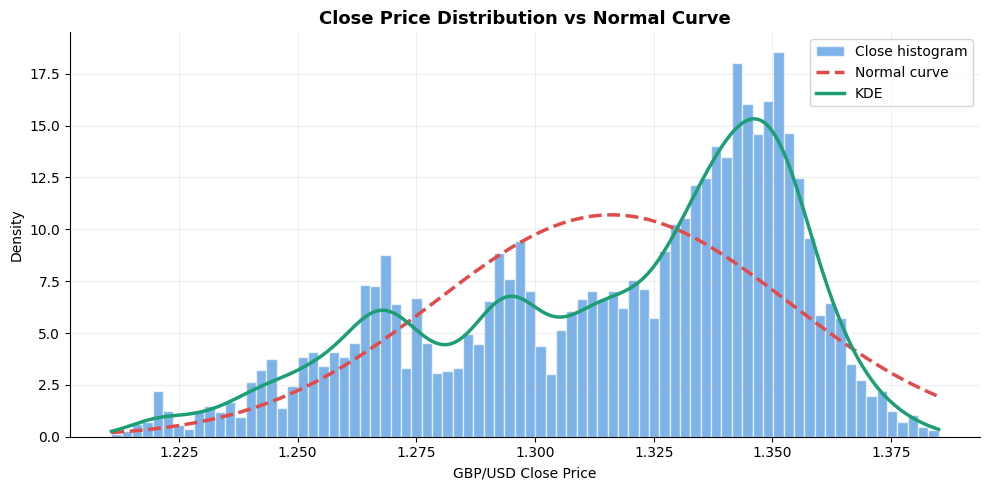

  [Fig 1] Saved → plots/01_close_distribution.png


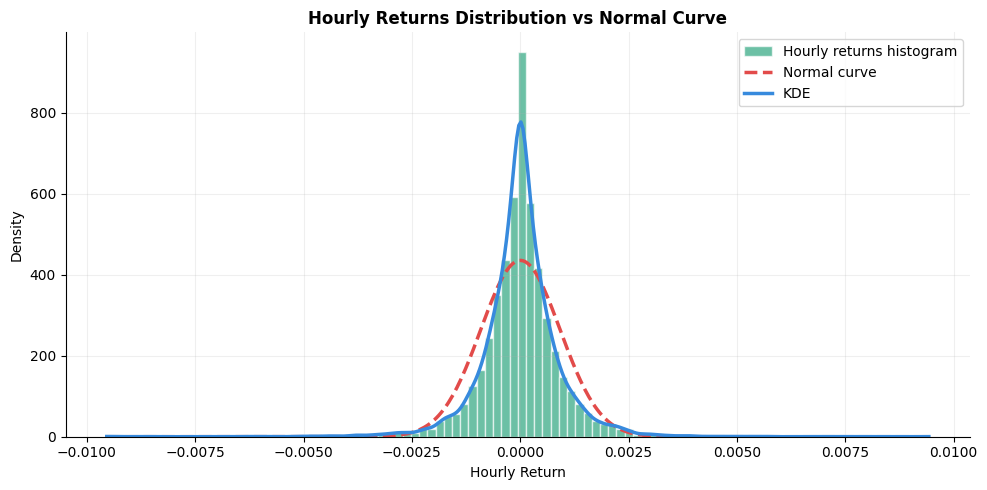

  [Fig 2] Saved → plots/02_returns_distribution.png


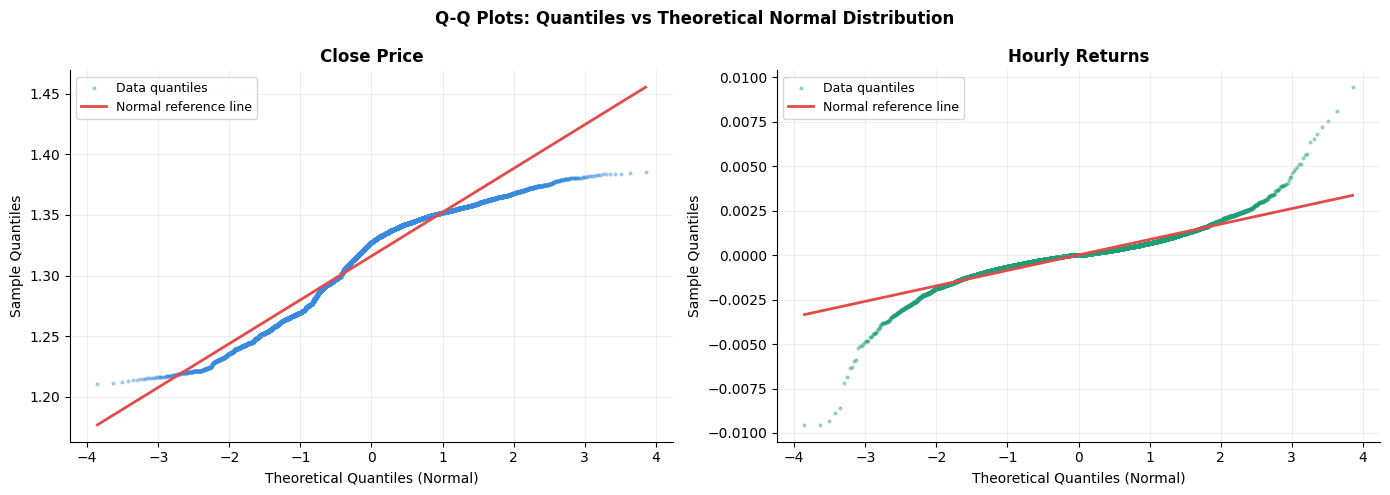

  [Fig 3] Saved → plots/03_qq_plots.png


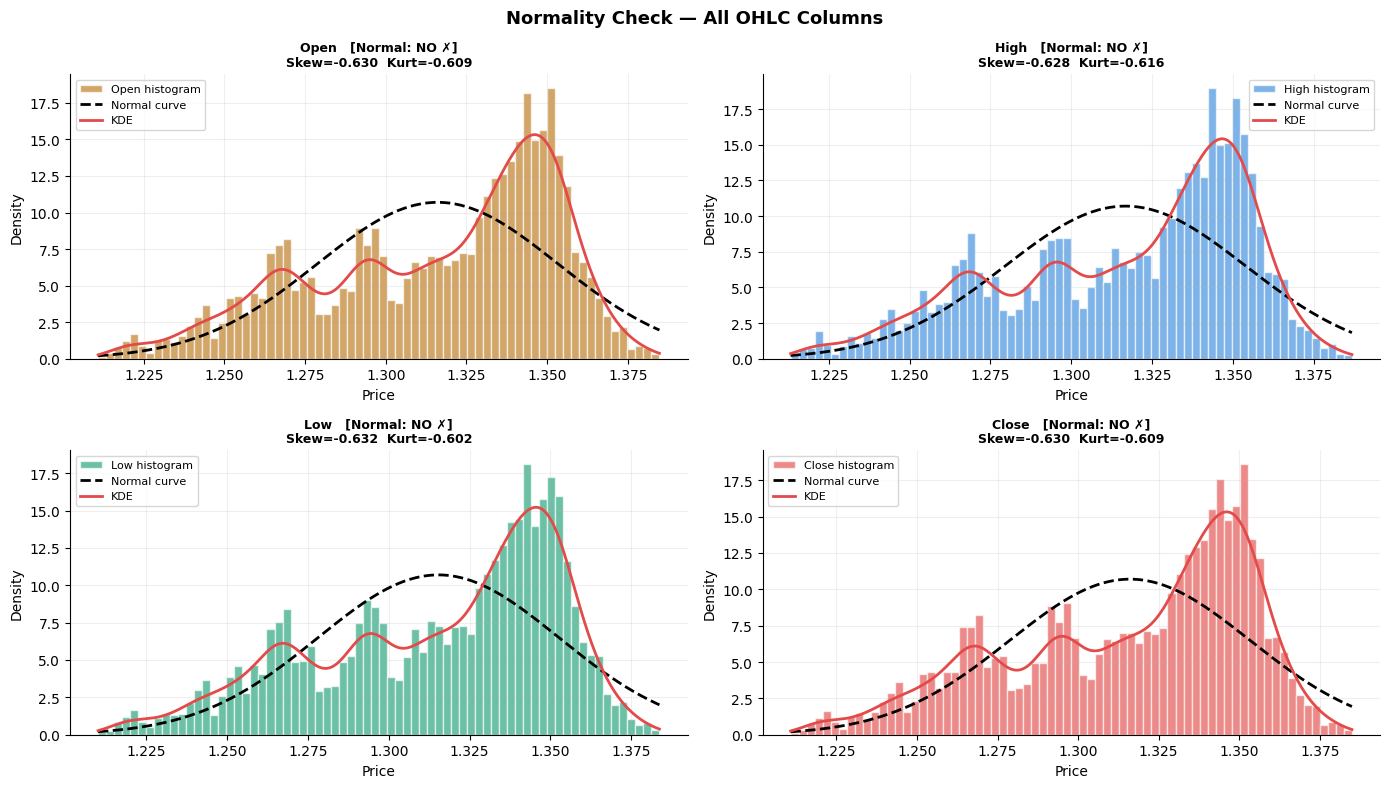

  [Fig 4] Saved → plots/04_ohlc_distributions.png


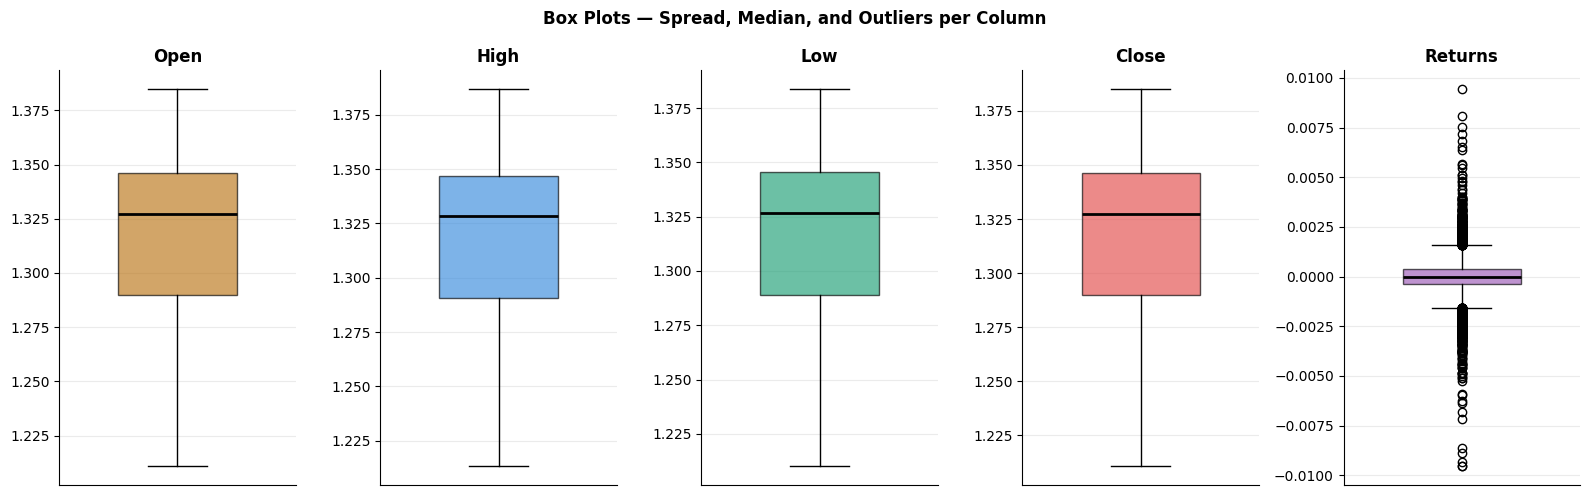

  [Fig 5] Saved → plots/05_boxplots.png

NORMALITY SUMMARY
  Column       Normal?      Skewness   Kurtosis
  ---------------------------------------------
  Close        NO ✗          -0.6301    -0.6093
  Open         NO ✗          -0.6302    -0.6087
  High         NO ✗          -0.6279    -0.6160
  Low          NO ✗          -0.6325    -0.6022
  Returns      NO ✗          -0.3525    11.2747


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

# Setup
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Calculate returns
returns = df["Close"].pct_change().dropna()
test_targets = {
    "Close": df["Close"].values,
    "Open": df["Open"].values,
    "High": df["High"].values,
    "Low": df["Low"].values,
    "Returns": returns.values
}

SAMPLE_SIZE = 5000
normality_results = {}

# Print header
print(f"  {'Column':<12} {'Shapiro p':>12} {'D\'Agostino p':>15} {'Skewness':>10} {'Kurtosis':>10} {'Normal?':>10}")
print("  " + "-" * 72)

# Normality tests
for col, arr in test_targets.items():
    arr = arr[~np.isnan(arr)]
    sample = arr if len(arr) <= SAMPLE_SIZE else np.random.default_rng(42).choice(arr, SAMPLE_SIZE, replace=False)
    sw_p = stats.shapiro(sample)[1]
    da_p = stats.normaltest(arr)[1]
    skew, kurt = float(stats.skew(arr)), float(stats.kurtosis(arr))
    is_normal = (sw_p >= 0.05) and (da_p >= 0.05)
    normality_results[col] = {"Shapiro p": sw_p, "DAgostino p": da_p, "Skewness": skew, "Kurtosis": kurt, "Normal": is_normal}
    print(f"  {col:<12} {sw_p:>12.4e} {da_p:>15.4e} {skew:>10.4f} {kurt:>10.4f} {'YES' if is_normal else 'NO ✗':>10}")

# FIGURE 1: Close Price Distribution
fig, ax = plt.subplots(figsize=(10, 5))
close_vals = df["Close"].values
ax.hist(close_vals, bins=80, color="#378ADD", alpha=0.65, edgecolor="white", density=True, label="Close histogram")
mu, sigma = close_vals.mean(), close_vals.std()
x_range = np.linspace(close_vals.min(), close_vals.max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), color="#E24B4A", lw=2.5, linestyle="--", label="Normal curve")
ax.plot(x_range, stats.gaussian_kde(close_vals)(x_range), color="#1D9E75", lw=2.5, label="KDE")
ax.set_title("Close Price Distribution vs Normal Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("GBP/USD Close Price")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "01_close_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 1] Saved → {os.path.join(PLOTS_DIR, '01_close_distribution.png')}")

# FIGURE 2: Returns Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ret_vals = returns.values
ax.hist(ret_vals, bins=100, color="#1D9E75", alpha=0.65, edgecolor="white", density=True, label="Hourly returns histogram")
mu_r, sigma_r = ret_vals.mean(), ret_vals.std()
x_r = np.linspace(ret_vals.min(), ret_vals.max(), 400)
ax.plot(x_r, stats.norm.pdf(x_r, mu_r, sigma_r), color="#E24B4A", lw=2.5, linestyle="--", label=f"Normal curve")
ax.plot(x_r, stats.gaussian_kde(ret_vals)(x_r), color="#378ADD", lw=2.5, label="KDE")
ax.set_title("Hourly Returns Distribution vs Normal Curve", fontsize=12, fontweight="bold")
ax.set_xlabel("Hourly Return")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "02_returns_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 2] Saved → {os.path.join(PLOTS_DIR, '02_returns_distribution.png')}")

# FIGURE 3: Q-Q Plots
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q-Q Plots: Quantiles vs Theoretical Normal Distribution", fontsize=12, fontweight="bold")

for ax, arr, title, color in [
    (ax_l, close_vals, "Close Price", "#378ADD"),
    (ax_r, ret_vals, "Hourly Returns", "#1D9E75"),
]:
    osm, osr = stats.probplot(arr, dist="norm")[0]
    slope, intercept, _ = stats.probplot(arr, dist="norm")[1]
    ax.scatter(osm, osr, s=4, alpha=0.35, color=color, label="Data quantiles")
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept, color="#E24B4A", lw=2, label="Normal reference line")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "03_qq_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 3] Saved → {os.path.join(PLOTS_DIR, '03_qq_plots.png')}")

# FIGURE 4: OHLC Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Normality Check — All OHLC Columns", fontsize=13, fontweight="bold")
axes = axes.flatten()

plot_cols = ["Open", "High", "Low", "Close"]
col_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A"]

for ax, col, c in zip(axes, plot_cols, col_colors):
    arr = df[col].values
    ax.hist(arr, bins=70, color=c, alpha=0.65, edgecolor="white", density=True, label=f"{col} histogram")
    mu_, s_ = arr.mean(), arr.std()
    xr = np.linspace(arr.min(), arr.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, mu_, s_), color="black", lw=2, linestyle="--", label="Normal curve")
    ax.plot(xr, stats.gaussian_kde(arr)(xr), color="#E24B4A", lw=2, label="KDE")
    r = normality_results[col]
    verdict = "Normal: NO ✗" if not r["Normal"] else "Normal: YES"
    ax.set_title(f"{col}   [{verdict}]\nSkew={r['Skewness']:.3f}  Kurt={r['Kurtosis']:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Price")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "04_ohlc_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 4] Saved → {os.path.join(PLOTS_DIR, '04_ohlc_distributions.png')}")

# FIGURE 5: Box Plots
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle("Box Plots — Spread, Median, and Outliers per Column", fontsize=12, fontweight="bold")

bp_data = [df["Open"].values, df["High"].values, df["Low"].values, df["Close"].values, returns.values]
bp_labels = ["Open", "High", "Low", "Close", "Returns"]
bp_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A", "#9B59B6"]

for ax, data, label, c in zip(axes, bp_data, bp_labels, bp_colors):
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops=dict(color="black", lw=2))
    bp["boxes"][0].set_facecolor(c)
    bp["boxes"][0].set_alpha(0.65)
    ax.set_title(label, fontweight="bold")
    ax.set_xticks([])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "05_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 5] Saved → {os.path.join(PLOTS_DIR, '05_boxplots.png')}")

# Print summary
print("\n" + "=" * 70)
print("NORMALITY SUMMARY")
print("=" * 70)
print(f"  {'Column':<12} {'Normal?':<10} {'Skewness':>10} {'Kurtosis':>10}")
print("  " + "-" * 45)
for col, r in normality_results.items():
    print(f"  {col:<12} {'YES' if r['Normal'] else 'NO ✗':<10} {r['Skewness']:>10.4f} {r['Kurtosis']:>10.4f}")

**EXPLORATORY DATA ANALYSIS PLOT**


[STEP 3]  Plotting raw data overview ...


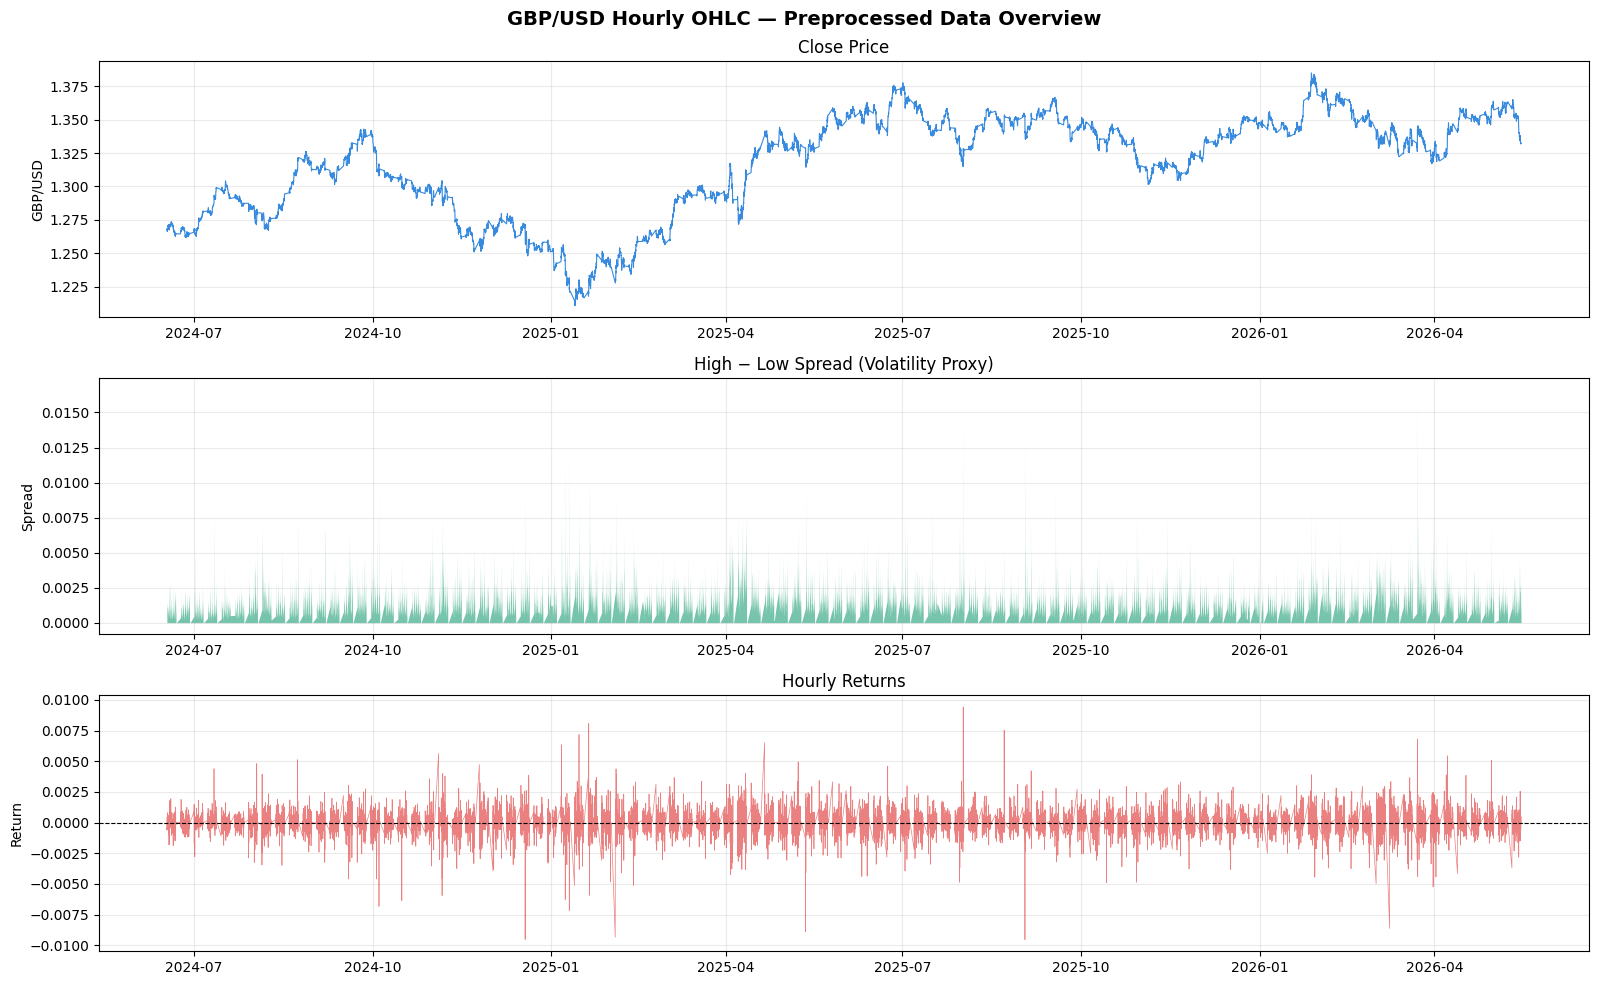

  Saved  →  plots/00_data_overview.png


In [16]:
import os

print("\n[STEP 3]  Plotting raw data overview ...")

os.makedirs(PLOTS_DIR, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle("GBP/USD Hourly OHLC — Preprocessed Data Overview",
             fontsize=14, fontweight="bold")

# Close price
axes[0].plot(df.index, df["Close"], color="#378ADD", linewidth=0.8)
axes[0].set_title("Close Price")
axes[0].set_ylabel("GBP/USD")
axes[0].grid(True, alpha=0.25)

# High - Low spread
axes[1].fill_between(df.index,
                     df["High"] - df["Low"],
                     color="#1D9E75", alpha=0.6, linewidth=0)
axes[1].set_title("High − Low Spread (Volatility Proxy)")
axes[1].set_ylabel("Spread")
axes[1].grid(True, alpha=0.25)

# Hourly returns
ret = df["Close"].pct_change().dropna()
axes[2].plot(df.index[1:], ret, color="#E24B4A", linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Hourly Returns")
axes[2].set_ylabel("Return")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "00_data_overview.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"  Saved  →  {path}")

**Feature engineering**

In [17]:
print("\n" + "=" * 70)
print("  FEATURE ENGINEERING  (18 features — standard forex sequential set)")
print("=" * 70)

fe = df.copy()

# ── 1. Return & candle structure ─────────────────────────────────────────────
fe["returns"]    = fe["Close"].pct_change()            # hourly % return
fe["hl_spread"]  = fe["High"] - fe["Low"]             # intra-hour range
fe["oc_spread"]  = fe["Close"] - fe["Open"]           # candle body direction

# ── 2. Trend: moving averages ─────────────────────────────────────────────────
fe["sma_10"]     = fe["Close"].rolling(10).mean()      # short-term trend
fe["sma_24"]     = fe["Close"].rolling(24).mean()      # daily trend
fe["ema_12"]     = fe["Close"].ewm(span=12, adjust=False).mean()
fe["ema_26"]     = fe["Close"].ewm(span=26, adjust=False).mean()  # NEW

# ── 3. MACD  (most used momentum indicator in forex) ─────────────────────────
fe["macd"]       = fe["ema_12"] - fe["ema_26"]         # NEW: MACD line
fe["macd_signal"]= fe["macd"].ewm(span=9, adjust=False).mean()  # NEW: signal
fe["macd_hist"]  = fe["macd"] - fe["macd_signal"]      # NEW: histogram

# ── 4. Momentum ───────────────────────────────────────────────────────────────
fe["momentum"]   = fe["Close"] - fe["Close"].shift(4)  # 4h absolute momentum
fe["roc_8"]      = fe["Close"].pct_change(8)            # NEW: 8h rate of change
fe["volatility"] = fe["returns"].rolling(12).std()      # 12h rolling volatility

# ── 5. RSI-14  (overbought / oversold) ───────────────────────────────────────
delta            = fe["Close"].diff()
gain             = delta.clip(lower=0).rolling(14).mean()
loss             = (-delta.clip(upper=0)).rolling(14).mean()
fe["rsi_14"]     = 100 - (100 / (1 + gain / (loss + 1e-9)))

# ── 6. Williams %R-14  (overbought/oversold — more sensitive than RSI) ───────
# NEW: ranges from -100 (oversold) to 0 (overbought)
highest_high     = fe["High"].rolling(14).max()
lowest_low       = fe["Low"].rolling(14).min()
fe["williams_r"] = -100 * (highest_high - fe["Close"]) / \
                   (highest_high - lowest_low + 1e-9)

# ── 7. ATR-14  (Average True Range — volatility with gap handling) ────────────
# NEW: standard risk/volatility measure used in all forex studies
prev_close       = fe["Close"].shift(1)
tr               = pd.concat([
    fe["High"] - fe["Low"],
    (fe["High"] - prev_close).abs(),
    (fe["Low"]  - prev_close).abs(),
], axis=1).max(axis=1)
fe["atr_14"]     = tr.rolling(14).mean()

# ── 8. Bollinger Band position ────────────────────────────────────────────────
bb_mid           = fe["Close"].rolling(20).mean()
bb_std           = fe["Close"].rolling(20).std()
fe["bb_pos"]     = (fe["Close"] - bb_mid) / (2 * bb_std + 1e-9)  # -1..+1

# ── 9. Lagged returns  (explicit direction memory for the model) ──────────────
fe["ret_lag1"]   = fe["returns"].shift(1)
fe["ret_lag2"]   = fe["returns"].shift(2)
fe["ret_lag3"]   = fe["returns"].shift(3)

# ── 10. Trend strength ────────────────────────────────────────────────────────
fe["price_sma_ratio"] = fe["Close"] / (fe["sma_24"] + 1e-9) - 1.0

# ── 11. Time-of-day & day-of-week  (session effects — NEW) ───────────────────
# GBP/USD hourly has strong London (9AM) and NY (2PM) session patterns.
# Encoded as sine/cosine to preserve cyclical continuity
# (so hour 23 is "close to" hour 0, not far away like a raw integer would imply)
hour             = fe.index.hour
dow              = fe.index.dayofweek                  # 0=Monday … 4=Friday
fe["hour_sin"]   = np.sin(2 * np.pi * hour / 24)
fe["hour_cos"]   = np.cos(2 * np.pi * hour / 24)
fe["dow_sin"]    = np.sin(2 * np.pi * dow  / 5)
fe["dow_cos"]    = np.cos(2 * np.pi * dow  / 5)

fe.dropna(inplace=True)

FEATURES = [
    # Raw candle
    "Open", "High", "Low", "Close",
    # Return & spread
    "returns", "hl_spread", "oc_spread",
    # Trend
    "sma_10", "sma_24", "ema_12", "ema_26",
    # MACD
    "macd", "macd_signal", "macd_hist",
    # Momentum & volatility
    "momentum", "roc_8", "volatility",
    # Oscillators
    "rsi_14", "williams_r",
    # Volatility (true range based)
    "atr_14",
    # Band position
    "bb_pos",
    # Direction memory
    "ret_lag1", "ret_lag2", "ret_lag3",
    # Trend strength
    "price_sma_ratio",
    # Session effects (cyclical encoding)
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]

CLOSE_IDX = FEATURES.index("Close")

print(f"  Total features : {len(FEATURES)}")
categories = {
    "Raw candle":         ["Open","High","Low","Close"],
    "Return & spread":    ["returns","hl_spread","oc_spread"],
    "Trend (MA)":         ["sma_10","sma_24","ema_12","ema_26"],
    "MACD":               ["macd","macd_signal","macd_hist"],
    "Momentum/Vol":       ["momentum","roc_8","volatility"],
    "Oscillators":        ["rsi_14","williams_r"],
    "True volatility":    ["atr_14"],
    "Band position":      ["bb_pos"],
    "Direction memory":   ["ret_lag1","ret_lag2","ret_lag3"],
    "Trend strength":     ["price_sma_ratio"],
    "Session effects":    ["hour_sin","hour_cos","dow_sin","dow_cos"],
}
new_features = {"ema_26","macd","macd_signal","macd_hist",
                "roc_8","williams_r","atr_14",
                "hour_sin","hour_cos","dow_sin","dow_cos"}

for cat, feats in categories.items():
    print(f"\n  {cat}:")
    for f in feats:
        tag = "  ← NEW" if f in new_features else ""
        print(f"    {f}{tag}")
print(f"\n  Rows after feature engineering : {len(fe):,}")


  FEATURE ENGINEERING  (18 features — standard forex sequential set)
  Total features : 29

  Raw candle:
    Open
    High
    Low
    Close

  Return & spread:
    returns
    hl_spread
    oc_spread

  Trend (MA):
    sma_10
    sma_24
    ema_12
    ema_26  ← NEW

  MACD:
    macd  ← NEW
    macd_signal  ← NEW
    macd_hist  ← NEW

  Momentum/Vol:
    momentum
    roc_8  ← NEW
    volatility

  Oscillators:
    rsi_14
    williams_r  ← NEW

  True volatility:
    atr_14  ← NEW

  Band position:
    bb_pos

  Direction memory:
    ret_lag1
    ret_lag2
    ret_lag3

  Trend strength:
    price_sma_ratio

  Session effects:
    hour_sin  ← NEW
    hour_cos  ← NEW
    dow_sin  ← NEW
    dow_cos  ← NEW

  Rows after feature engineering : 11,971


**Normalize features**

In [18]:
print("  NORMALISATION  (RobustScaler — outlier-resistant)")
print("=" * 70)
print("""
  Why RobustScaler instead of MinMaxScaler?
  ------------------------------------------
  MinMaxScaler maps [min, max] → [0, 1].
  A single extreme price spike compresses all other values into a tiny range.
  Our normality test confirmed GBP/USD returns are leptokurtic (fat tails)
  — meaning extreme values occur regularly.

  RobustScaler maps using median and IQR:
      scaled = (x - median) / IQR
  This makes the scaling insensitive to outliers.
  Recommended for financial time series in the literature.
""")

# Determine split point on the raw feature array
n_total = len(fe)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

# Fit scaler ONLY on training rows — never let val/test influence scaling
scaler     = RobustScaler()
train_raw  = fe[FEATURES].values[:n_train]
scaler.fit(train_raw)

scaled = scaler.transform(fe[FEATURES].values)

# Split scaled array for range verification
train_sc = scaled[:n_train]
val_sc   = scaled[n_train : n_train + n_val]
test_sc  = scaled[n_train + n_val:]

print(f"  Scaler         : RobustScaler  (median + IQR, no min/max sensitivity)")
print(f"  Fitted on      : training rows only  ({n_train:,} rows)")
print(f"  Scaled shape   : {scaled.shape}")
print(f"\n  Range check per split (values outside training range = expected in forex):")
print(f"  {'Split':<12} {'Min':>10} {'Max':>10} {'Out-of-range cols':>20}")
print("  " + "-" * 56)
for label, arr in [("Train", train_sc), ("Validation", val_sc), ("Test", test_sc)]:
    # Count columns where any value falls outside [-5, 5]
    # (RobustScaler output is centred at 0; ±5 is a reasonable bound)
    out_of_range = int((np.abs(arr) > 5).any(axis=0).sum())
    print(f"  {label:<12} {arr.min():>10.4f} {arr.max():>10.4f} "
          f"{out_of_range:>20} / {len(FEATURES)}")

print(f"\n  Note: out-of-range values in val/test are expected — they represent")
print(f"  price levels the model has not seen during training. Dropout and")
print(f"  EarlyStopping help the model generalise to these unseen ranges.")

  NORMALISATION  (RobustScaler — outlier-resistant)

  Why RobustScaler instead of MinMaxScaler?
  ------------------------------------------
  MinMaxScaler maps [min, max] → [0, 1].
  A single extreme price spike compresses all other values into a tiny range.
  Our normality test confirmed GBP/USD returns are leptokurtic (fat tails)
  — meaning extreme values occur regularly.

  RobustScaler maps using median and IQR:
      scaled = (x - median) / IQR
  This makes the scaling insensitive to outliers.
  Recommended for financial time series in the literature.

  Scaler         : RobustScaler  (median + IQR, no min/max sensitivity)
  Fitted on      : training rows only  (8,379 rows)
  Scaled shape   : (11971, 29)

  Range check per split (values outside training range = expected in forex):
  Split               Min        Max    Out-of-range cols
  --------------------------------------------------------
  Train          -12.8555    12.9867                    9 / 29
  Validation      -6

**SEQUENCE CREATION  (sliding window — lookback = 24 hours)**

In [19]:
print(f"\n{'='*70}\n  SEQUENCE CREATION  (lookback={LOOKBACK}h)\n{'='*70}")

def create_sequences(data, lookback, target_idx):
    """Vectorised sliding window — faster than a Python loop."""
    n_rows, n_feat = data.shape
    n_samples      = n_rows - lookback
    shape   = (n_samples, lookback, n_feat)
    strides = (data.strides[0], data.strides[0], data.strides[1])
    X = np.array(np.lib.stride_tricks.as_strided(data, shape, strides),
                 dtype=np.float32)          # copy so memory is safe to modify
    y = data[lookback:, target_idx].astype(np.float32)
    return X, y

X, y = create_sequences(scaled, LOOKBACK, CLOSE_IDX)
print(f"  X : {X.shape}  ({X.nbytes/1e6:.1f} MB)")
print(f"  y : {y.shape}")


  SEQUENCE CREATION  (lookback=48h)
  X : (11923, 48, 29)  (66.4 MB)
  y : (11923,)


**Train / Validation / Test split**

In [20]:
print("\n" + "=" * 70)
print("  TRAIN / VAL / TEST SPLIT  (chronological — no shuffle)")
print("=" * 70)

n       = len(X)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

INPUT_SHAPE = (LOOKBACK, len(FEATURES))

# Boundary leakage check — last train index must be before first val index
assert n_train < n_train + n_val < n, "Split boundaries overlap — data leakage!"

print(f"  Total samples : {n:,}")
print(f"  +------------------+--------+------------+")
print(f"  | Split            | Ratio  |    Samples |")
print(f"  +------------------+--------+------------+")
print(f"  | Train            |  70 %  | {X_train.shape[0]:>10,} |")
print(f"  | Validation       |  15 %  | {X_val.shape[0]:>10,} |")
print(f"  | Test (held-out)  |  15 %  | {X_test.shape[0]:>10,} |")
print(f"  +------------------+--------+------------+")
print(f"  Input shape per sample : {INPUT_SHAPE}")


  TRAIN / VAL / TEST SPLIT  (chronological — no shuffle)
  Total samples : 11,923
  +------------------+--------+------------+
  | Split            | Ratio  |    Samples |
  +------------------+--------+------------+
  | Train            |  70 %  |      8,346 |
  | Validation       |  15 %  |      1,788 |
  | Test (held-out)  |  15 %  |      1,789 |
  +------------------+--------+------------+
  Input shape per sample : (48, 29)


# **MODEL**

**MODEL ARCHITECTURE DEFINITIONS**

In [21]:
# ── Custom loss: penalises wrong price direction, not just price error ─────────
DA_ALPHA = 0.45

def da_weighted_loss(alpha=DA_ALPHA):
    import tensorflow as tf
    def loss(y_true, y_pred):
        mse        = tf.reduce_mean(tf.square(y_true - y_pred))
        dt         = tf.clip_by_value(y_true[1:] - y_true[:-1], -1e3, 1e3)
        dp         = tf.clip_by_value(y_pred[1:] - y_pred[:-1], -1e3, 1e3)
        dir_loss   = tf.reduce_mean(tf.maximum(0.0, -(dt * dp)))
        return (1.0 - alpha) * mse + alpha * dir_loss
    loss.__name__ = "da_weighted_loss"
    return loss

# ── Shared compile helper ──────────────────────────────────────────────────────
def _compile(model):
    model.compile(
        optimizer=Adam(LEARNING_RATE, clipnorm=1.0),  # clipnorm prevents exploding gradients
        loss=da_weighted_loss(DA_ALPHA),
        metrics=["mae"]
    )
    return model

# ── LSTM ───────────────────────────────────────────────────────────────────────
def build_lstm(input_shape, units, dropout):
    model = Sequential(name="LSTM")
    model.add(LSTM(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    return _compile(model)

# ── GRU ────────────────────────────────────────────────────────────────────────
def build_gru(input_shape, units, dropout):
    model = Sequential(name="GRU")
    model.add(GRU(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(GRU(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    return _compile(model)

# ── BiLSTM ─────────────────────────────────────────────────────────────────────
def build_bilstm(input_shape, units, dropout):
    model = Sequential(name="BiLSTM")
    model.add(Bidirectional(LSTM(units, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(Bidirectional(LSTM(units // 2, return_sequences=False)))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    return _compile(model)

# ── Vanilla RNN ────────────────────────────────────────────────────────────────
def build_rnn(input_shape, units, dropout):
    model = Sequential(name="Vanilla_RNN")
    model.add(SimpleRNN(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(SimpleRNN(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    return _compile(model)

print(f"  4 model builders ready — shared loss: DA-Weighted (alpha={DA_ALPHA})")
print(f"  Architecture: Recurrent(x2) → Dropout(x2) → Dense(32) → Dense(1)")

  4 model builders ready — shared loss: DA-Weighted (alpha=0.45)
  Architecture: Recurrent(x2) → Dropout(x2) → Dense(32) → Dense(1)


**SHARED HELPER FUNCTIONS**

In [22]:
# ── Colour palette ─────────────────────────────────────────────────────────────
_C_ACTUAL = "#111111"   # black  — actual price
_C_TRAIN  = "#2CA02C"   # green  — train predictions / train loss
_C_VAL    = "#FF7F0E"   # orange — val predictions / val loss
_C_ZERO   = "#E24B4A"   # red    — zero residual reference

# ── Inverse-transform Close only (scaler was fitted on all features) ───────────
def inverse_close(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(FEATURES)))
    dummy[:, CLOSE_IDX] = scaled_vals
    return scaler.inverse_transform(dummy)[:, CLOSE_IDX]

# ── Compute all evaluation metrics ────────────────────────────────────────────
def compute_metrics(actual, preds):
    rmse  = float(np.sqrt(mean_squared_error(actual, preds)))
    mae   = float(mean_absolute_error(actual, preds))
    mape  = float(np.mean(np.abs((actual - preds) / (actual + 1e-9))) * 100)
    nrmse = float(rmse / (actual.max() - actual.min()) * 100)
    da    = float(np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(preds))) * 100)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "NRMSE (%)": nrmse, "DA (%)": da}

# ── Run inference on any split → prices + metrics ─────────────────────────────
def run_inference(model, X, y):
    preds  = inverse_close(model.predict(X, verbose=0).flatten())
    actual = inverse_close(y)
    return preds, actual, compute_metrics(actual, preds)

# ── Train one model with EarlyStopping + LR decay + checkpoint ────────────────
def train_model(model, name, X_tr, y_tr, X_v, y_v):
    cbs = [
        EarlyStopping(monitor="val_loss", patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=7, min_lr=1e-6, verbose=0),
        ModelCheckpoint(os.path.join(MODELS_DIR, f"{name}_best.weights.h5"),
                        monitor="val_loss", save_best_only=True,
                        save_weights_only=True, verbose=0),
    ]
    t0 = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=cbs, verbose=1)
    elapsed = time.time() - t0
    best_ep = int(np.argmin(history.history["val_loss"])) + 1
    print(f"\n  Done | best epoch={best_ep} | "
          f"val_loss={min(history.history['val_loss']):.6f} | {elapsed:.1f}s")
    return history, elapsed

# ── Validation report — warn if DA < 50% ──────────────────────────────────────
def print_validation_report(name, metrics):
    da_ok = metrics["DA (%)"] >= 50.0
    flag  = "OK" if da_ok else "LOW — below random baseline!"
    print(f"\n  [{name}] VALIDATION")
    print(f"  RMSE={metrics['RMSE']:.5f}  MAE={metrics['MAE']:.5f}  "
          f"MAPE={metrics['MAPE']:.2f}%  NRMSE={metrics['NRMSE (%)']:.2f}%")
    print(f"  DA={metrics['DA (%)']:.2f}%  [{flag}]")
    return da_ok

# ── Test report ───────────────────────────────────────────────────────────────
def print_test_report(name, metrics, params, elapsed):
    print(f"\n  [{name}] TEST RESULTS")
    print(f"  Params={params:,}  Time={elapsed:.1f}s")
    print(f"  RMSE={metrics['RMSE']:.5f}  MAE={metrics['MAE']:.5f}  "
          f"MAPE={metrics['MAPE']:.2f}%  NRMSE={metrics['NRMSE (%)']:.2f}%")
    print(f"  DA={metrics['DA (%)']:.2f}%  "
          f"[{'GOOD' if metrics['DA (%)'] >= 50 else 'CHECK'}]")

# ── Axis styling helper ────────────────────────────────────────────────────────
def _ax(ax, title, xlabel="Hours", ylabel="GBP/USD", color="black"):
    ax.set_title(title, fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.18, linestyle="--", color="grey")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ── 6 individual figures per model ────────────────────────────────────────────
def plot_individual_results(name, history,
                             train_preds, train_actual,
                             val_preds,   val_actual,
                             test_preds,  test_actual,
                             test_metrics, color):

    plt.rcParams.update({"figure.dpi": 150, "font.size": 10})

    h       = history.history
    eps     = range(1, len(h["loss"]) + 1)
    m       = test_metrics
    tr_m    = compute_metrics(train_actual, train_preds)
    val_m   = compute_metrics(val_actual, val_preds)
    best_ep = int(np.argmin(h["val_loss"])) + 1
    da_col  = "darkgreen" if val_m["DA (%)"] >= 50 else "crimson"

    def _save(fig, suffix):
        p = os.path.join(PLOTS_DIR, f"{name}_{suffix}.png")
        fig.tight_layout()
        fig.savefig(p, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Saved → {p}")

    # Fig 1 — Loss curve
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(eps, h["loss"],     color=_C_TRAIN, lw=2.5, label=f"Train  (final={h['loss'][-1]:.5f})")
    ax.plot(eps, h["val_loss"], color=_C_VAL,   lw=2.5, linestyle="--",
            label=f"Val  (best={min(h['val_loss']):.5f})")
    ax.axvline(best_ep, color="grey", lw=1.4, linestyle=":", label=f"Best epoch={best_ep}")
    _ax(ax, f"[{name}] Loss Curve | best val={min(h['val_loss']):.5f} @ ep{best_ep}",
        xlabel="Epoch", ylabel="Loss")
    ax.legend(fontsize=10)
    _save(fig, "1_loss")

    # Fig 2 — Train predictions (last 500 h)
    N = min(500, len(train_actual))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train_actual[-N:], color=_C_ACTUAL, lw=1.6, label="Actual")
    ax.plot(train_preds[-N:],  color=_C_TRAIN,  lw=1.2, label="Predicted", alpha=0.85)
    _ax(ax, f"[{name}] Train (last {N}h) | RMSE={tr_m['RMSE']:.5f}  DA={tr_m['DA (%)']:.1f}%")
    ax.legend(fontsize=10)
    _save(fig, "2_train")

    # Fig 3 — Validation predictions
    flag = "DA OK" if val_m["DA (%)"] >= 50 else "DA LOW"
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(val_actual, color=_C_ACTUAL, lw=1.6, label="Actual")
    ax.plot(val_preds,  color=_C_VAL,    lw=1.2, label="Predicted", alpha=0.88)
    _ax(ax, f"[{name}] Validation [{flag}] | RMSE={val_m['RMSE']:.5f}  DA={val_m['DA (%)']:.1f}%",
        color=da_col)
    ax.legend(fontsize=10)
    _save(fig, "3_val")

    # Fig 4 — Test predictions (full)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_actual, color=_C_ACTUAL, lw=1.6, label="Actual")
    ax.plot(test_preds,  color=color,     lw=1.2, label=f"Predicted ({name})", alpha=0.88)
    _ax(ax, f"[{name}] Test Full | RMSE={m['RMSE']:.5f}  MAPE={m['MAPE']:.2f}%  DA={m['DA (%)']:.1f}%")
    ax.legend(fontsize=10)
    _save(fig, "4_test_full")

    # Fig 5 — Test predictions (zoomed)
    Z = min(300, len(test_actual))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_actual[:Z], color=_C_ACTUAL, lw=1.8, label="Actual")
    ax.plot(test_preds[:Z],  color=color,     lw=1.3, label=f"Predicted ({name})", alpha=0.88)
    _ax(ax, f"[{name}] Test Zoomed (first {Z}h) | RMSE={m['RMSE']:.5f}  DA={m['DA (%)']:.1f}%")
    ax.legend(fontsize=10)
    _save(fig, "5_test_zoom")

    # Fig 6 — Scatter + residual histogram
    res = test_preds - test_actual
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5))

    axL.scatter(test_actual, test_preds, s=5, alpha=0.28, color=color)
    lo, hi = min(test_actual.min(), test_preds.min()), max(test_actual.max(), test_preds.max())
    axL.plot([lo, hi], [lo, hi], color=_C_ACTUAL, lw=1.6, linestyle="--", label="Perfect fit")
    _ax(axL, f"[{name}] Scatter | mean={res.mean():.5f}  std={res.std():.5f}",
        xlabel="Actual", ylabel="Predicted")
    axL.legend(fontsize=9)

    axR.hist(res, bins=70, color=color, alpha=0.72, edgecolor="white")
    axR.axvline(0,          color=_C_ZERO, lw=2.0, linestyle="--", label="Zero")
    axR.axvline(res.mean(), color=_C_VAL,  lw=2.0, label=f"Mean={res.mean():.5f}")
    _ax(axR, f"[{name}] Residuals | skew={stats.skew(res):.3f}  kurt={stats.kurtosis(res):.3f}",
        xlabel="Residual", ylabel="Frequency")
    axR.legend(fontsize=9)

    _save(fig, "6_scatter_residual")

# ── Initialise results store (must exist before any model block runs) ──────────
results = {}
print("  Helpers ready.")

  Helpers ready.


**MODEL 1 — LSTM**

In [23]:
print("\n  [LSTM]  STEP 1 : BUILD")
print("  " + "-" * 55)
lstm_model = build_lstm(INPUT_SHAPE, UNITS, DROPOUT)
lstm_model.summary()
print(f"  Parameters : {lstm_model.count_params():,}")


  [LSTM]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 128)        │        80,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,641 (846.25 KB)

 Trainable params: 216,641 (846.25 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 216,641


**LSTM Train**

In [24]:
print("\n  [LSTM]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}  "
      f"epochs={EPOCHS}  patience={PATIENCE}  batch={BATCH_SIZE}\n")
lstm_history, lstm_time = train_model(
    lstm_model, "LSTM", X_train, y_train, X_val, y_val
)


  [LSTM]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=8,346  Val=1,788  epochs=100  patience=15  batch=32

Epoch 1/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0065 - mae: 0.0733 - val_loss: 0.0015 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 2/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0022 - mae: 0.0479 - val_loss: 3.8389e-04 - val_mae: 0.0185 - learning_rate: 0.0010
Epoch 3/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0016 - mae: 0.0409 - val_loss: 0.0022 - val_mae: 0.0500 - learning_rate: 0.0010
Epoch 4/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0016 - mae: 0.0403 - val_loss: 9.9906e-04 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 5/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0013 - mae: 0.0367 - val_loss: 3.0200e-04 - val_mae: 0.0168 - learning_rate: 0.0010
Epoch 6/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0013 - mae: 0.0367 - val_loss: 3.0635e-04 - val_mae: 0.0173

**LSTM VALIDATE  ← check metrics here before running t**

In [25]:
print("\n  [LSTM]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
lstm_val_preds, lstm_val_actual, lstm_val_metrics = run_inference(
    lstm_model, X_val, y_val
)
lstm_val_ok = print_validation_report("LSTM", lstm_val_metrics)


  [LSTM]  STEP 3 : VALIDATE
  -------------------------------------------------------

  [LSTM] VALIDATION
  RMSE=0.00150  MAE=0.00100  MAPE=0.07%  NRMSE=1.80%
  DA=45.83%  [LOW — below random baseline!]


**TEST**

In [26]:
print("\n  [LSTM]  STEP 4 : TEST  (held-out test set)")
print("  " + "-" * 55)
print(f"  Running inference on {X_test.shape[0]:,} unseen samples ...")
lstm_train_preds, lstm_train_actual, _ = run_inference(lstm_model, X_train, y_train)
lstm_test_preds,  lstm_test_actual, lstm_test_metrics = run_inference(
    lstm_model, X_test, y_test
)
print_test_report("LSTM", lstm_test_metrics, lstm_model.count_params(), lstm_time)


  [LSTM]  STEP 4 : TEST  (held-out test set)
  -------------------------------------------------------
  Running inference on 1,789 unseen samples ...

  [LSTM] TEST RESULTS
  Params=216,641  Time=112.7s
  RMSE=0.00151  MAE=0.00110  MAPE=0.08%  NRMSE=2.70%
  DA=45.97%  [CHECK]


**PLOT**

  [LSTM]  STEP 5 : PLOT
  -------------------------------------------------------


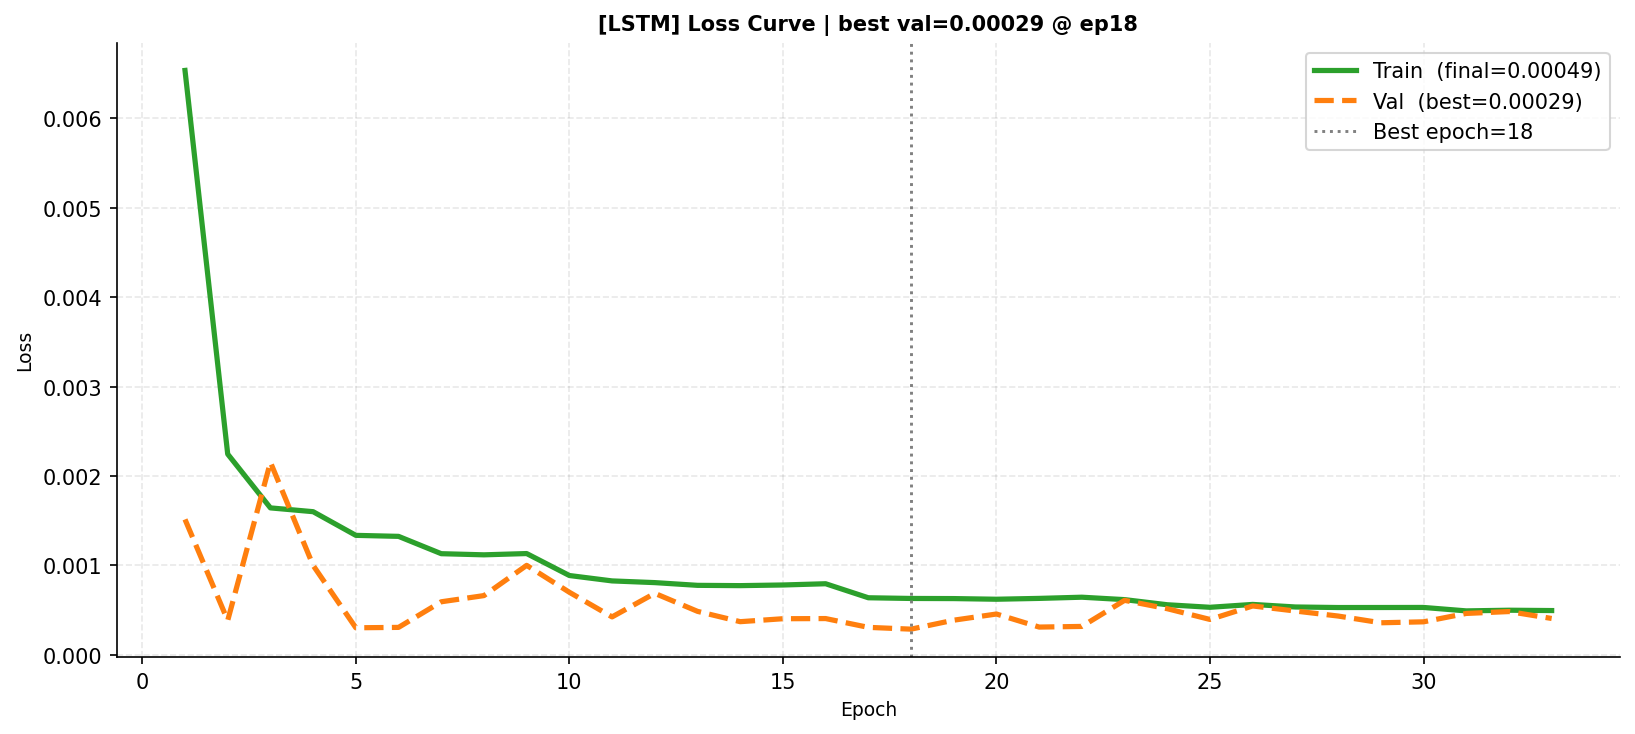

  Saved → plots/LSTM_1_loss.png


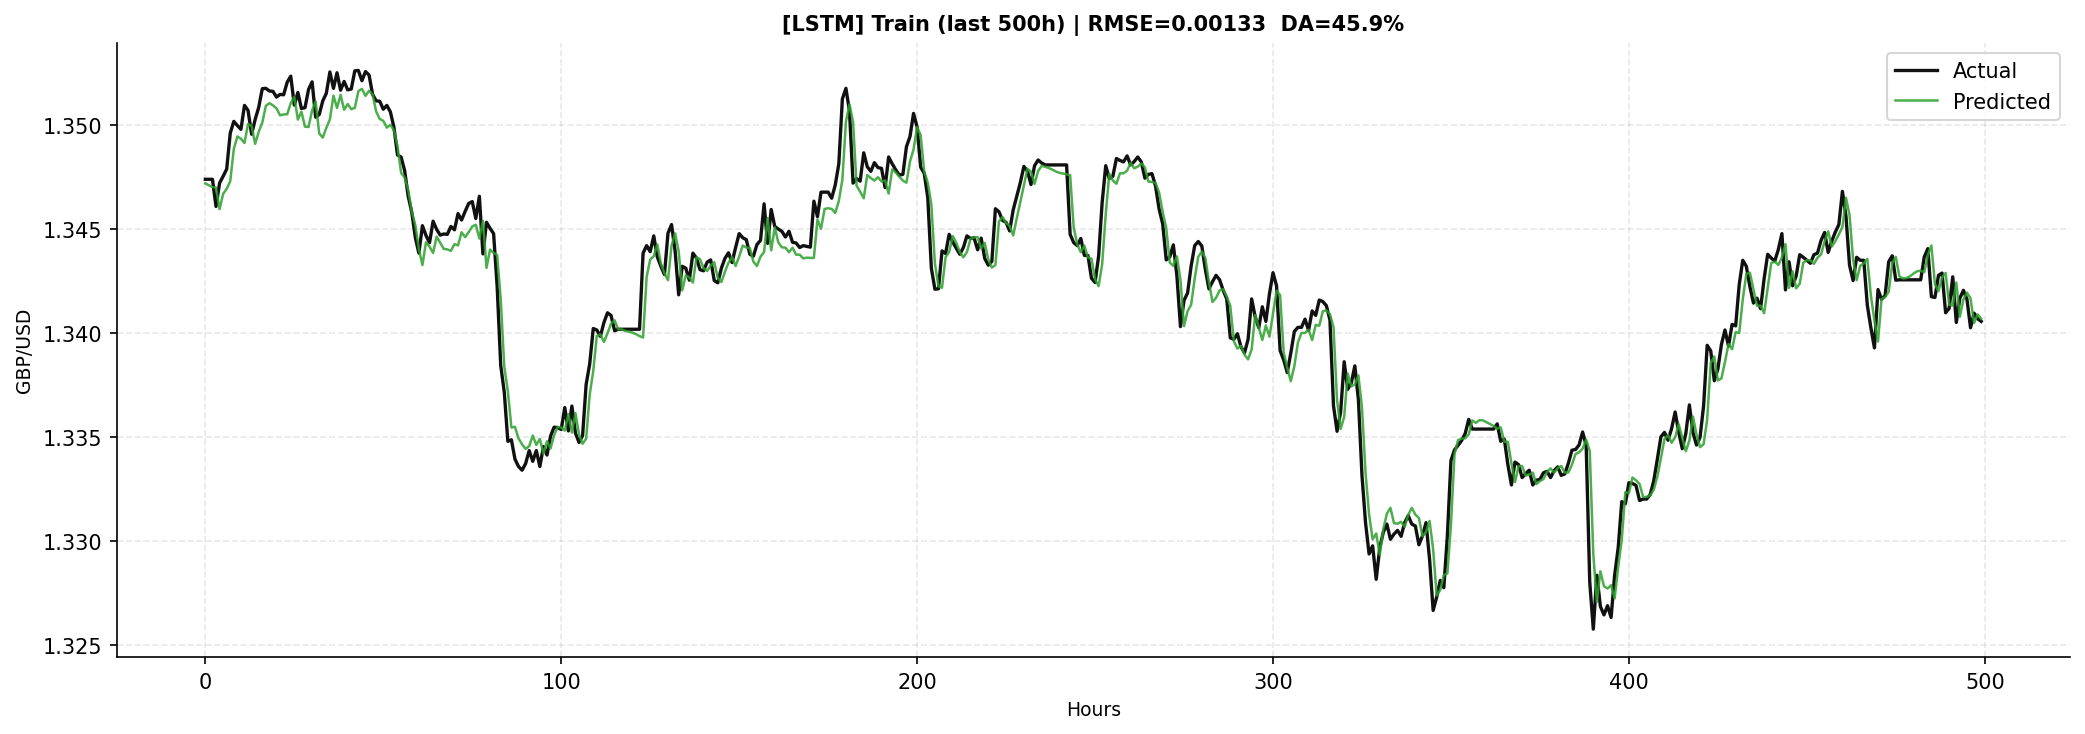

  Saved → plots/LSTM_2_train.png


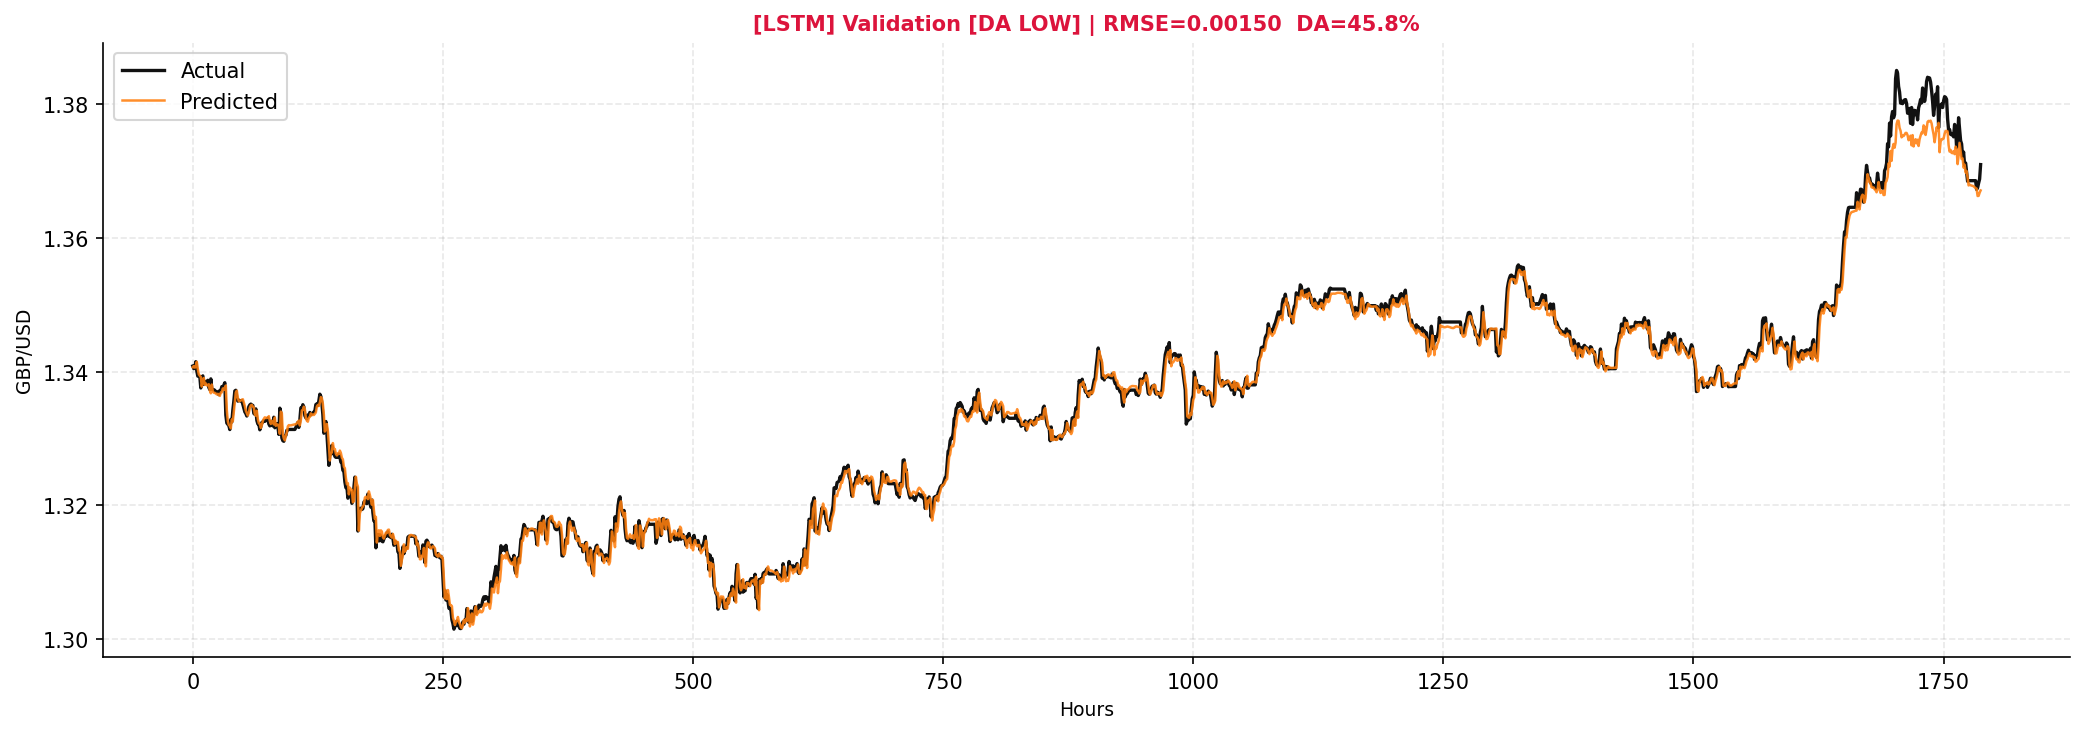

  Saved → plots/LSTM_3_val.png


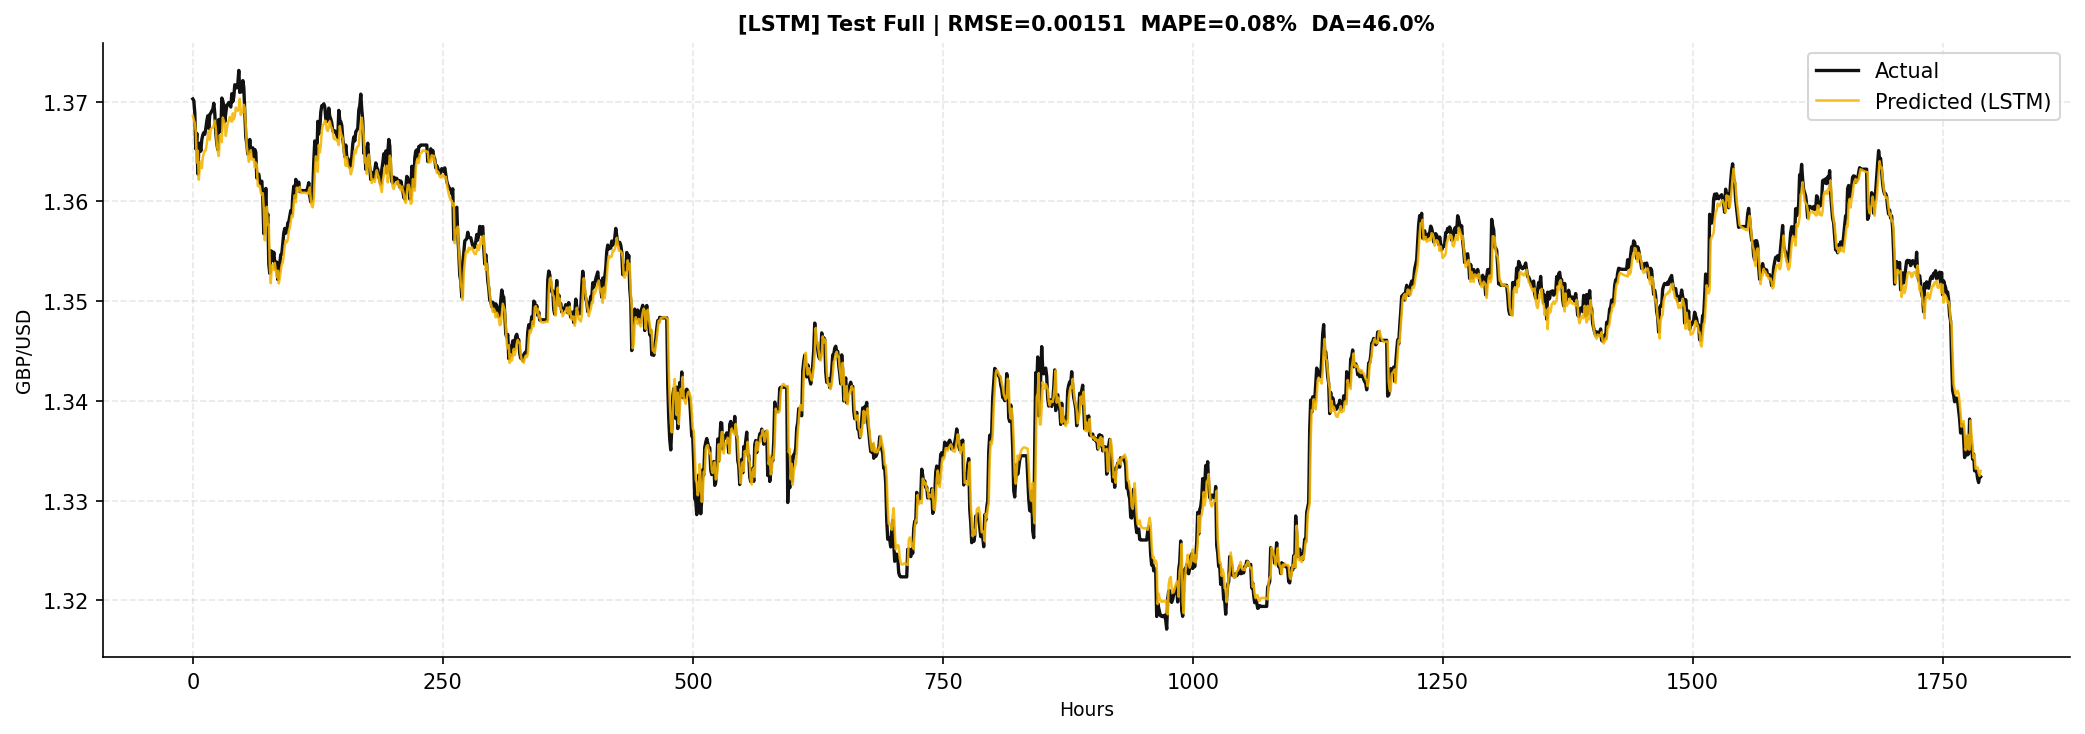

  Saved → plots/LSTM_4_test_full.png


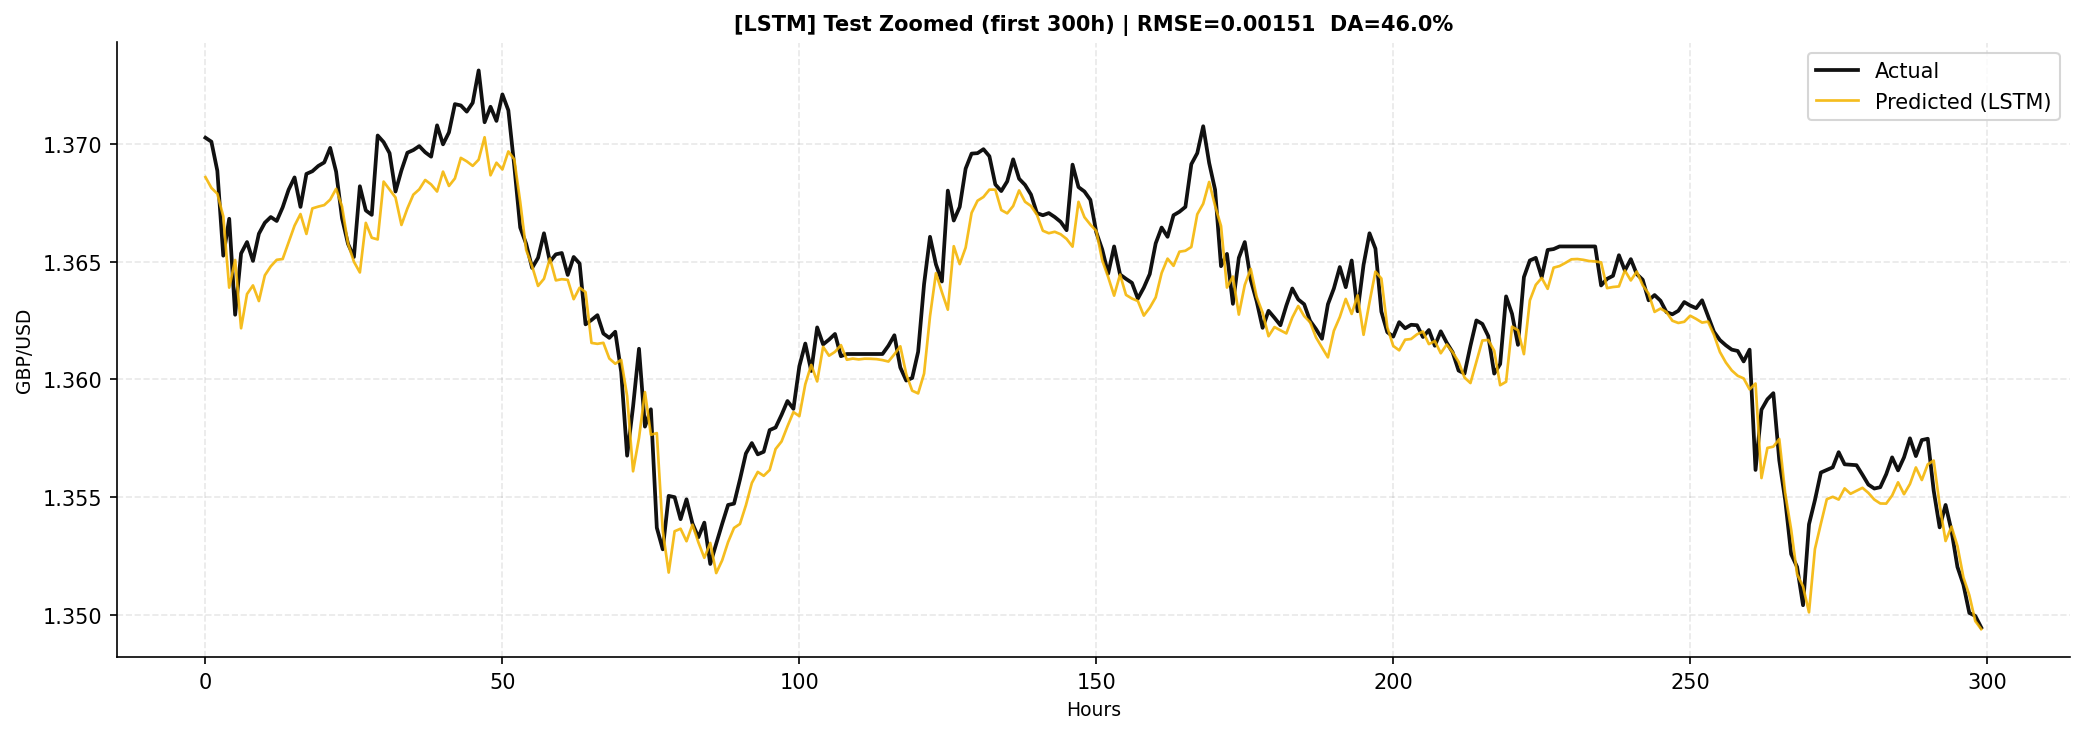

  Saved → plots/LSTM_5_test_zoom.png


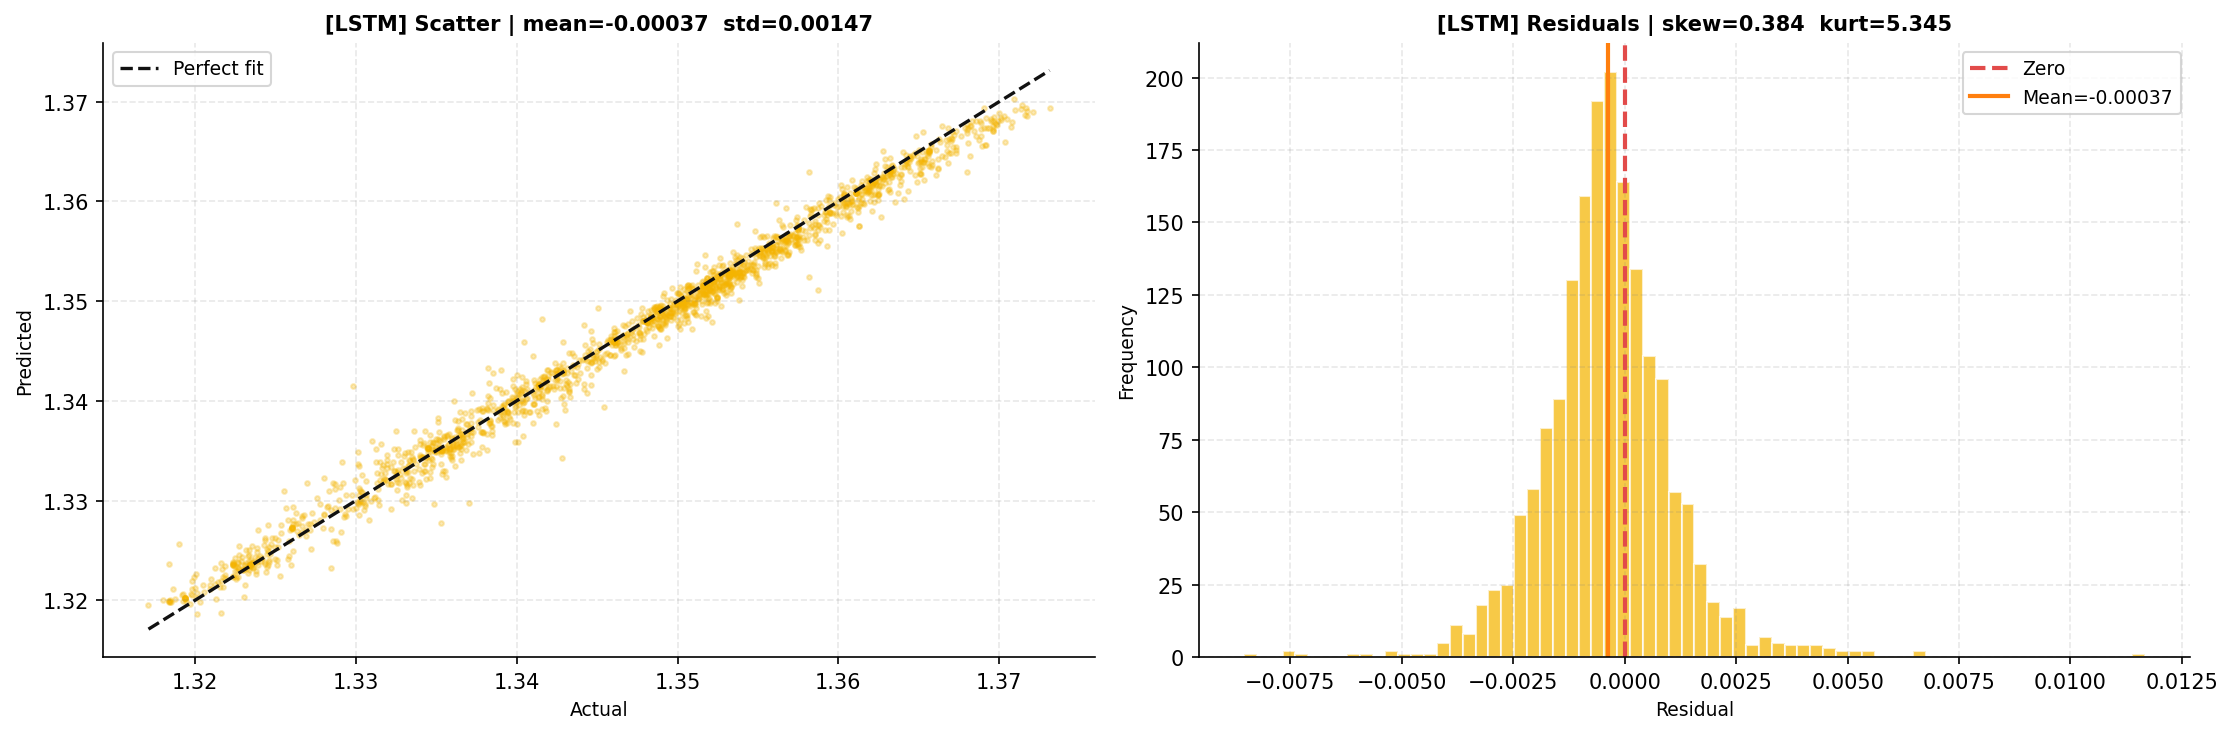

  Saved → plots/LSTM_6_scatter_residual.png
  LSTM complete.



In [27]:
print("  [LSTM]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "LSTM", lstm_history,
    lstm_train_preds, lstm_train_actual,
    lstm_val_preds,   lstm_val_actual,
    lstm_test_preds,  lstm_test_actual,
    lstm_test_metrics, COLORS["LSTM"]
)

results["LSTM"] = {
    "history":      lstm_history,
    "val_metrics":  lstm_val_metrics,
    "preds":        lstm_test_preds,
    "actual":       lstm_test_actual,
    "metrics":      lstm_test_metrics,
    "params":       lstm_model.count_params(),
    "time":         lstm_time,
}
print("  LSTM complete.\n")

# **GRU**

**BUILD**

In [28]:
print("\n  [GRU]  STEP 1 : BUILD")
gru_model = build_gru(INPUT_SHAPE, UNITS, DROPOUT)   # removed LEARNING_RATE
gru_model.summary()
print(f"  Parameters : {gru_model.count_params():,}")


  [GRU]  STEP 1 : BUILD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 48, 128)        │        61,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,289 (641.75 KB)

 Trainable params: 164,289 (641.75 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 164,289


**TRAIN**

In [29]:
print("\n  [GRU]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
gru_history, gru_time = train_model(
    gru_model, "GRU", X_train, y_train, X_val, y_val
)


  [GRU]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=8,346  Val=1,788

Epoch 1/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0100 - mae: 0.0916 - val_loss: 6.3476e-04 - val_mae: 0.0267 - learning_rate: 0.0010
Epoch 2/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0030 - mae: 0.0557 - val_loss: 0.0017 - val_mae: 0.0456 - learning_rate: 0.0010
Epoch 3/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0021 - mae: 0.0468 - val_loss: 6.8351e-04 - val_mae: 0.0247 - learning_rate: 0.0010
Epoch 4/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0018 - mae: 0.0433 - val_loss: 3.3006e-04 - val_mae: 0.0167 - learning_rate: 0.0010
Epoch 5/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0014 - mae: 0.0379 - val_loss: 5.4241e-04 - val_mae: 0.0212 - learning_rate: 0.0010
Epoch 6/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0014 - mae: 0.0384 - val_loss: 9.2435e-04 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 7

**VALIDATION**

In [30]:
print("\n  [GRU]  STEP 3 : VALIDATE")
gru_val_preds, gru_val_actual, gru_val_metrics = run_inference(gru_model, X_val, y_val)
gru_val_ok = print_validation_report("GRU", gru_val_metrics)   # removed preds/actual args


  [GRU]  STEP 3 : VALIDATE

  [GRU] VALIDATION
  RMSE=0.00117  MAE=0.00084  MAPE=0.06%  NRMSE=1.40%
  DA=45.89%  [LOW — below random baseline!]


**TEST**

In [31]:
print("\n  [GRU]  STEP 4 : TEST")
gru_train_preds, gru_train_actual, _ = run_inference(gru_model, X_train, y_train)
gru_test_preds, gru_test_actual, gru_test_metrics = run_inference(gru_model, X_test, y_test)
print_test_report("GRU", gru_test_metrics, gru_model.count_params(), gru_time)


  [GRU]  STEP 4 : TEST

  [GRU] TEST RESULTS
  Params=164,289  Time=124.4s
  RMSE=0.00140  MAE=0.00098  MAPE=0.07%  NRMSE=2.49%
  DA=46.64%  [CHECK]


**PLOTS FOR GRU**


  [GRU]  STEP 5 : PLOT


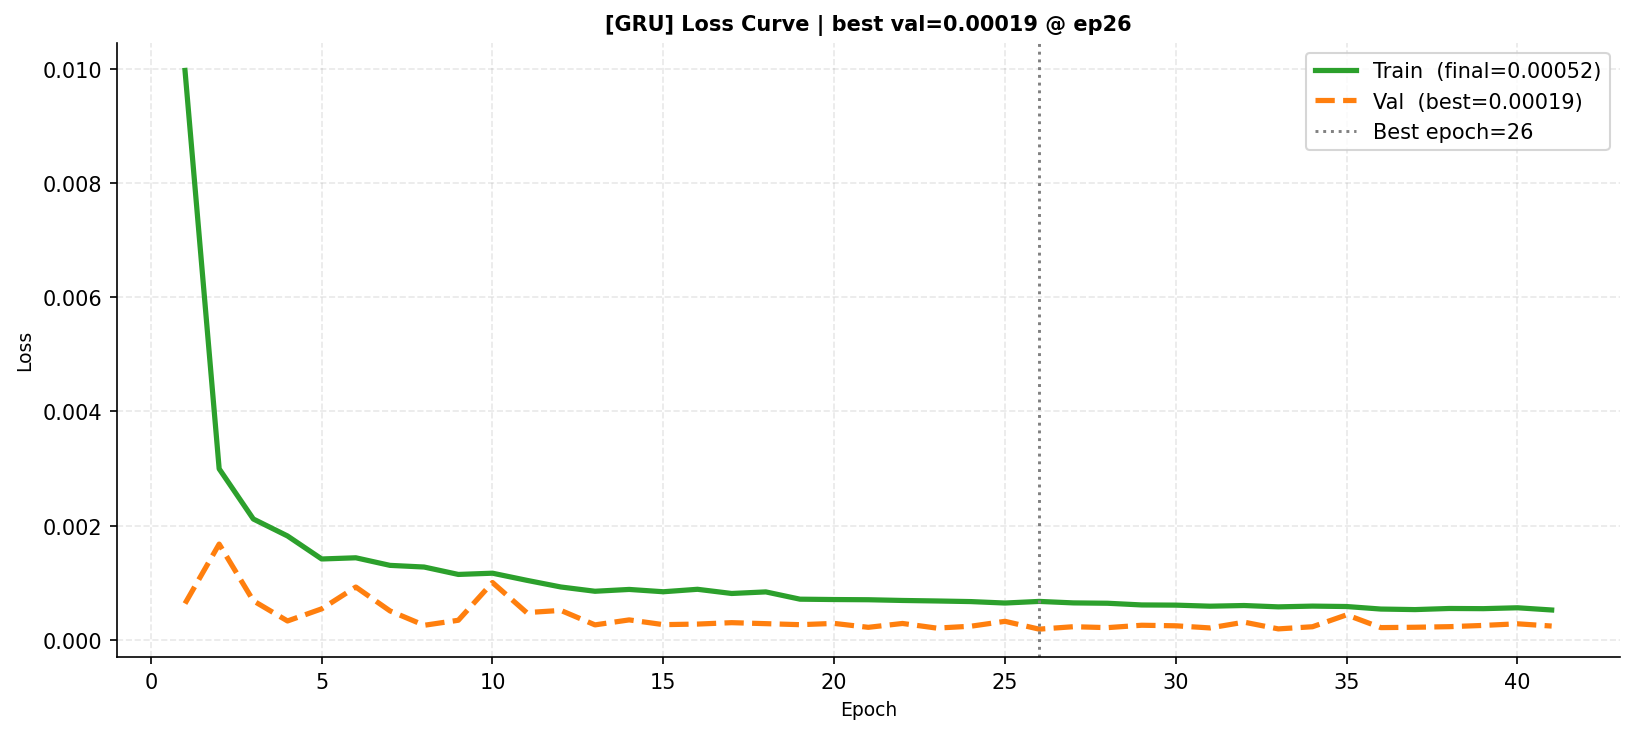

  Saved → plots/GRU_1_loss.png


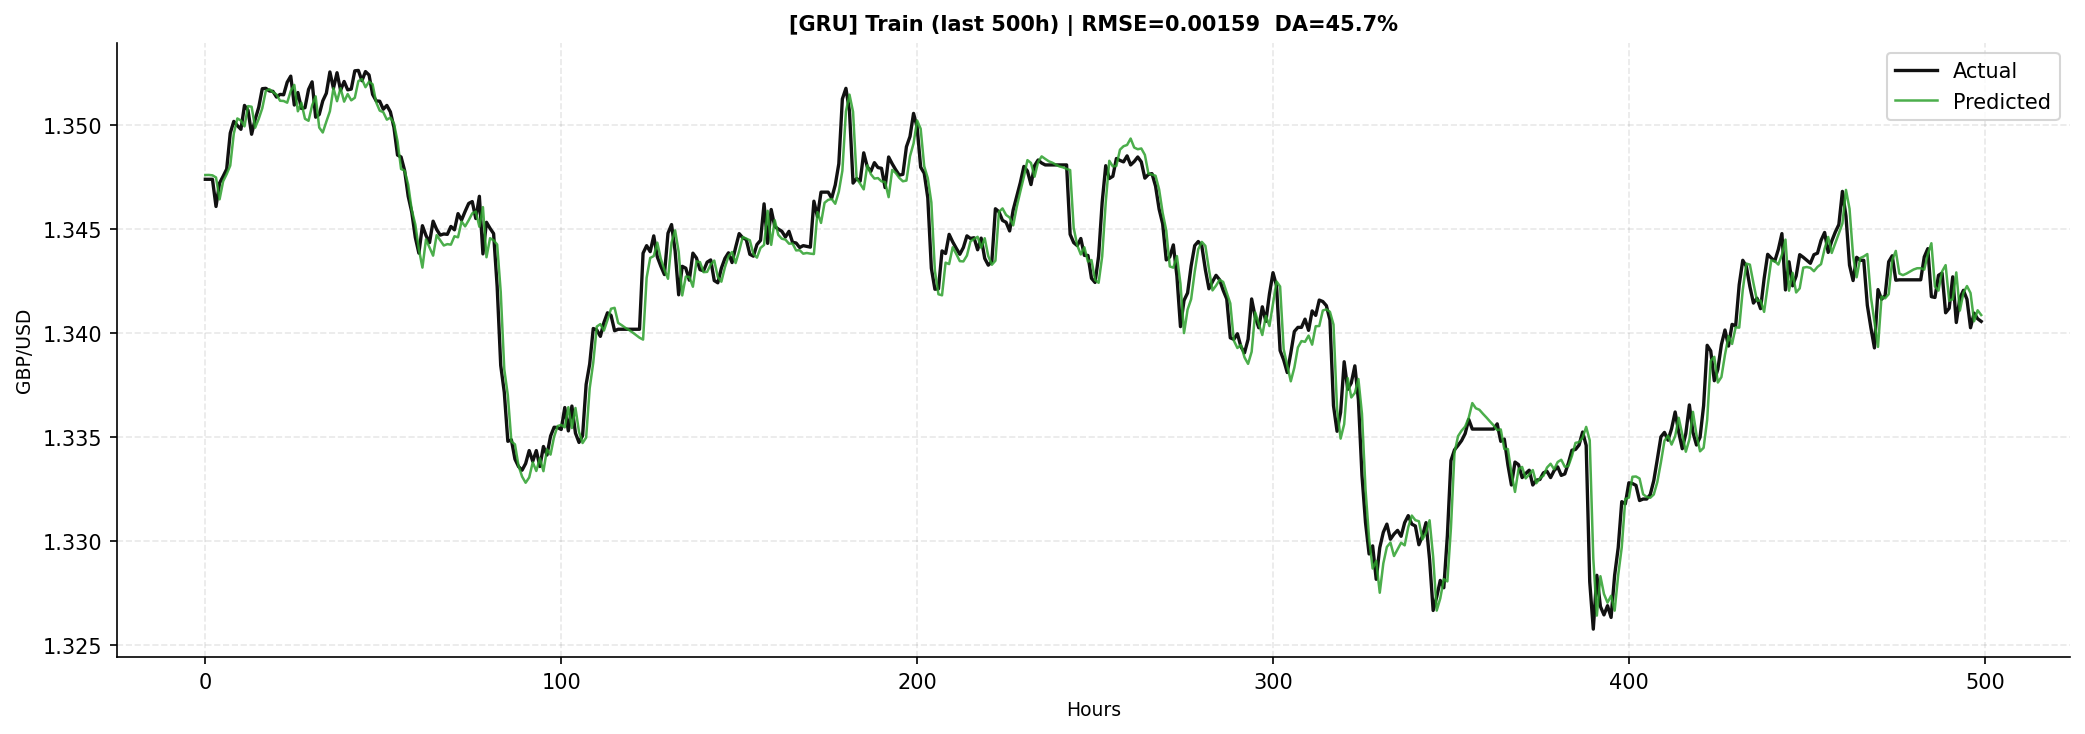

  Saved → plots/GRU_2_train.png


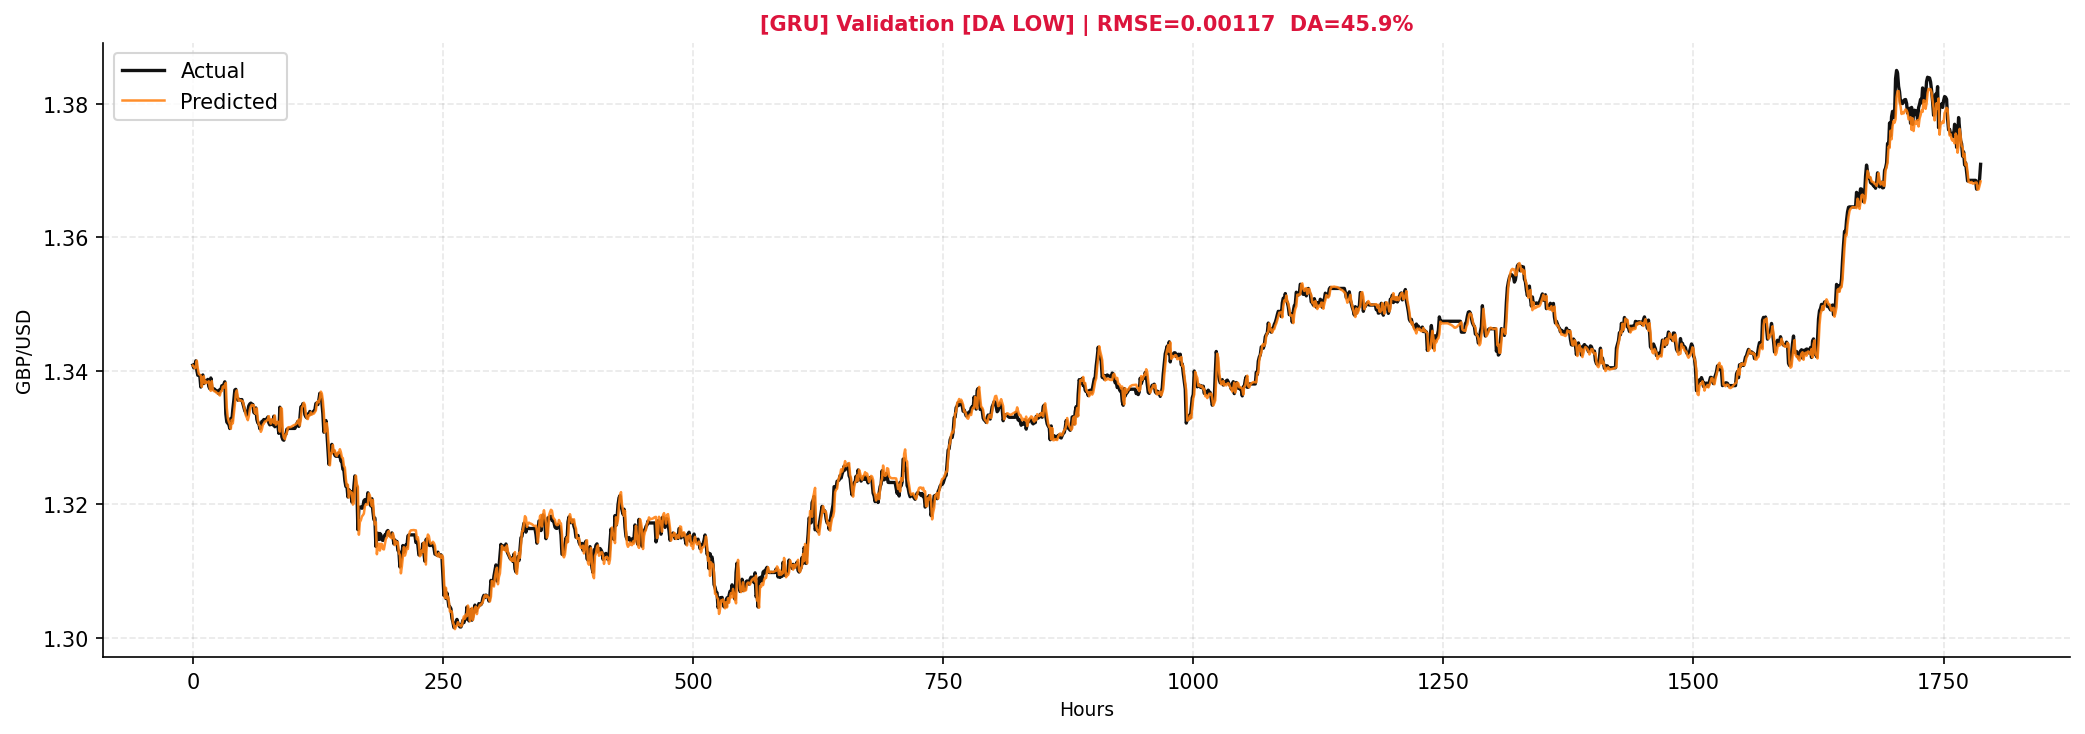

  Saved → plots/GRU_3_val.png


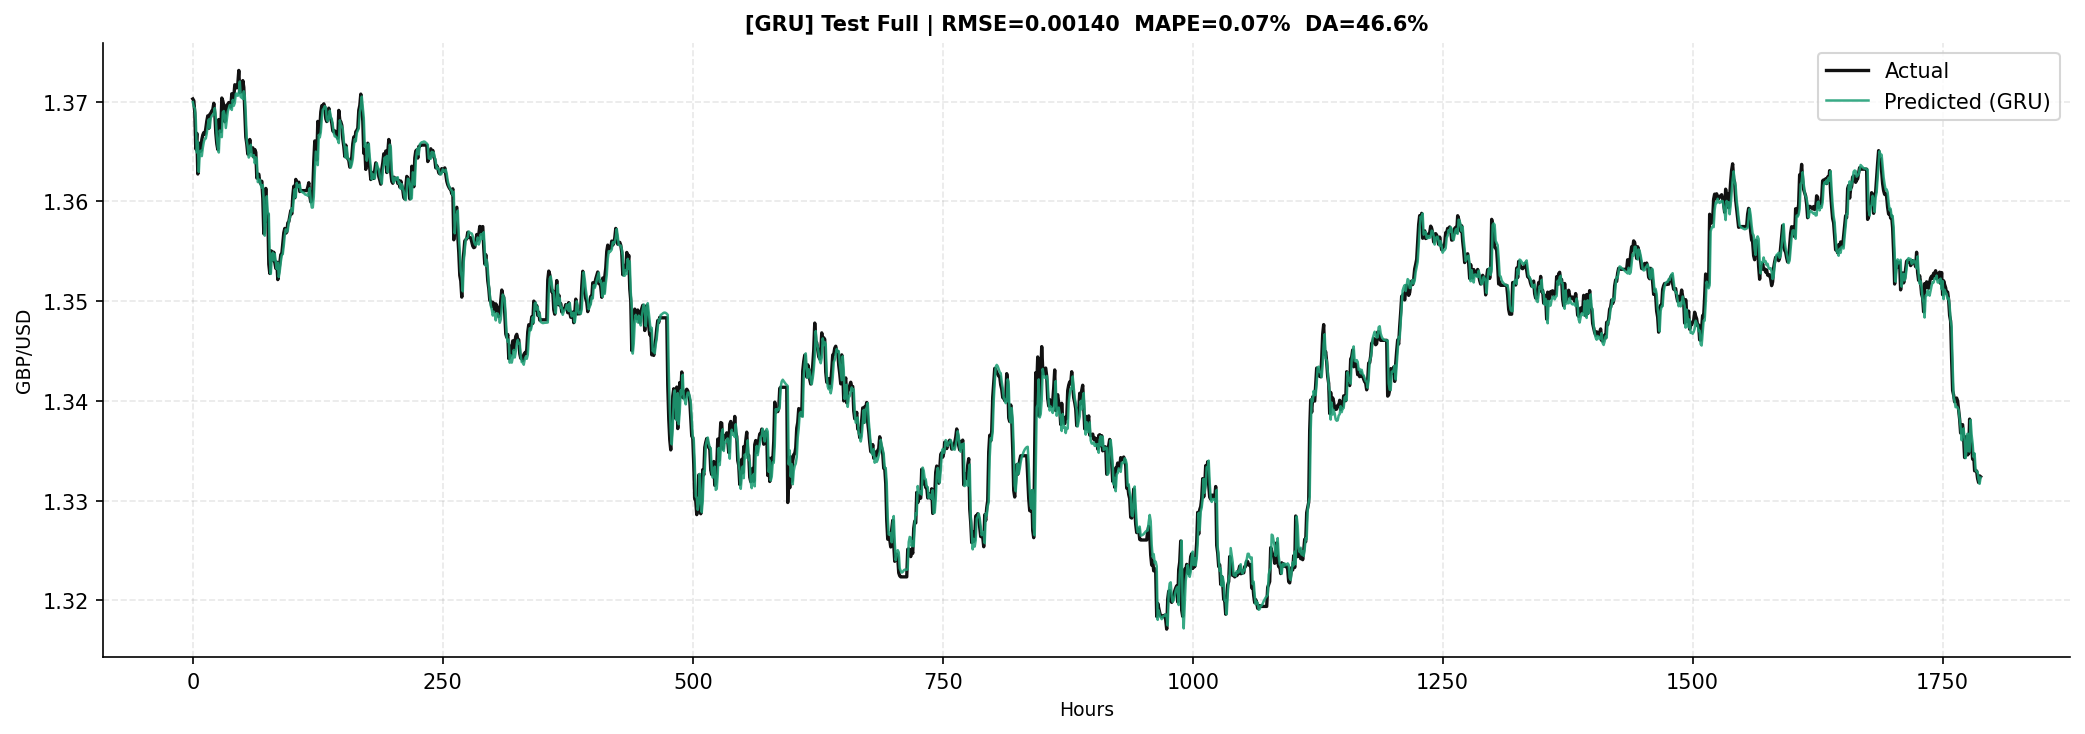

  Saved → plots/GRU_4_test_full.png


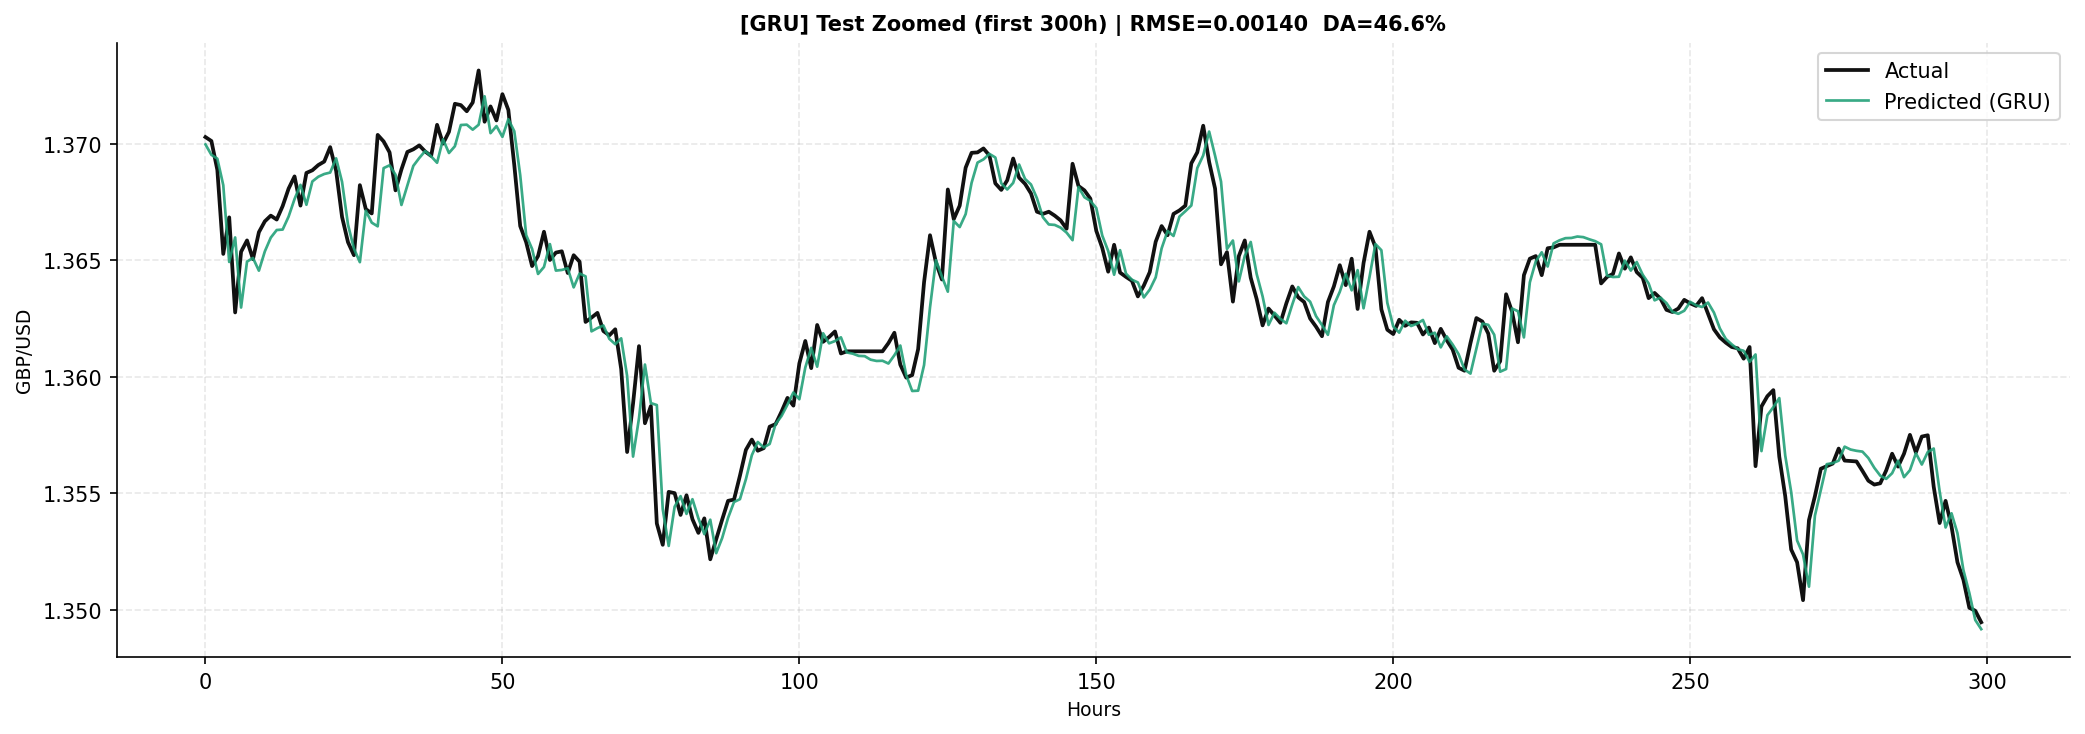

  Saved → plots/GRU_5_test_zoom.png


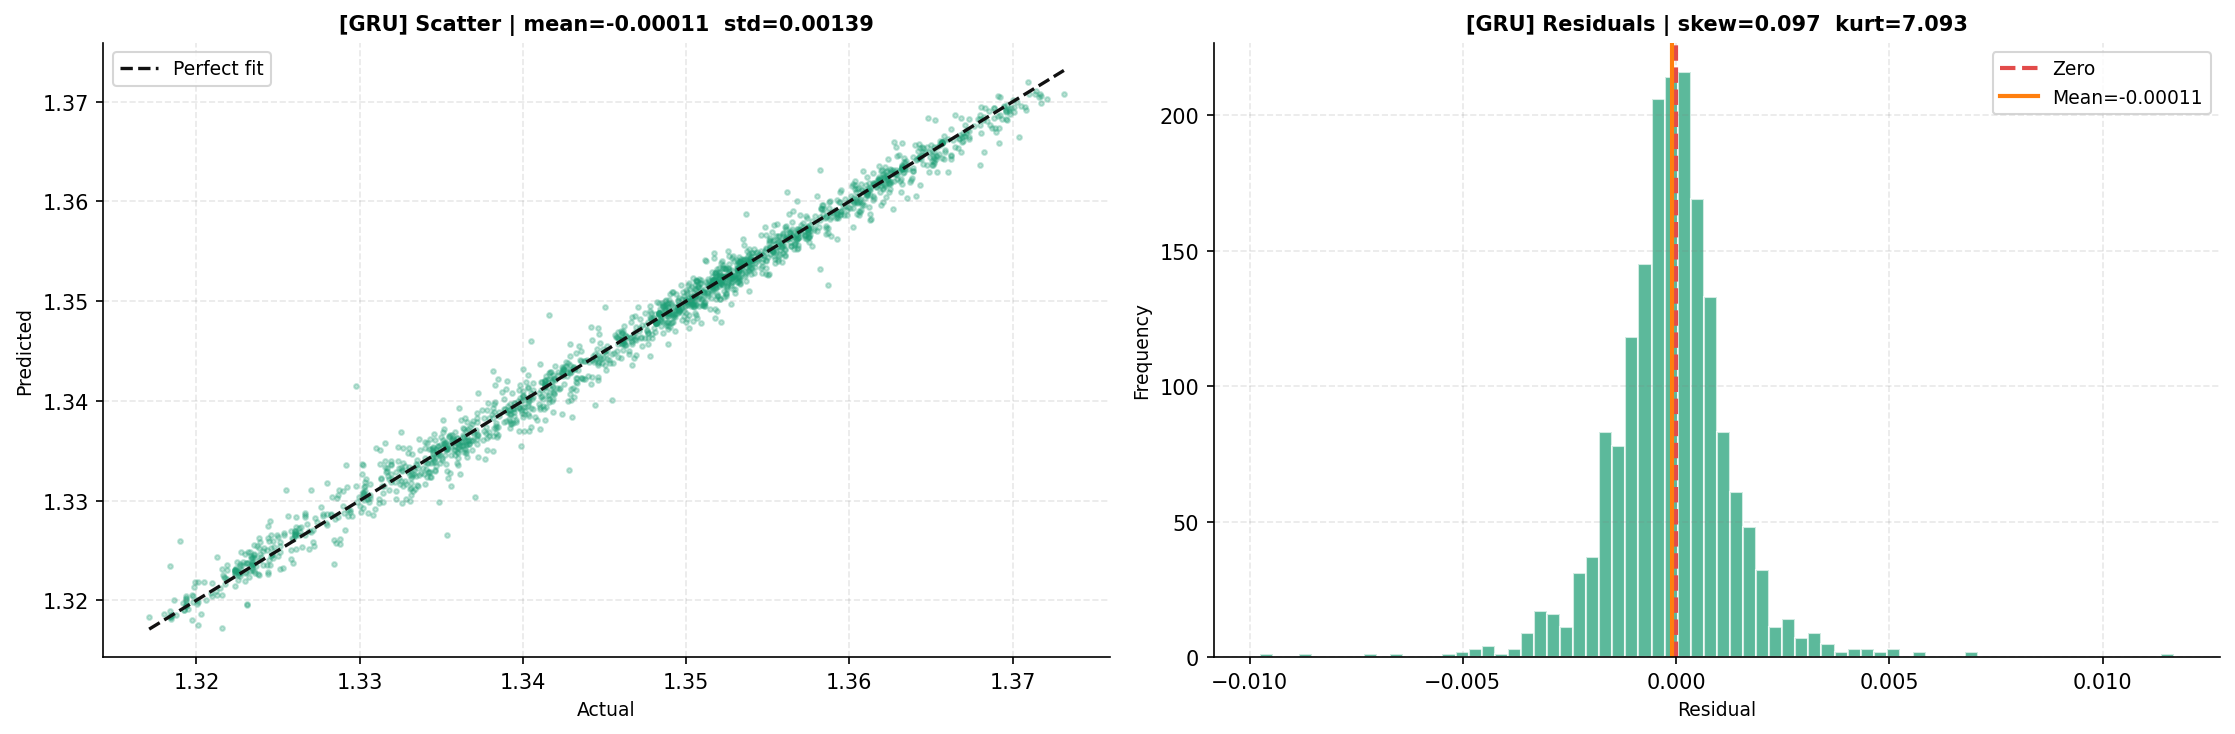

  Saved → plots/GRU_6_scatter_residual.png
  GRU complete.


In [32]:
print("\n  [GRU]  STEP 5 : PLOT")
plot_individual_results(
    "GRU", gru_history,
    gru_train_preds, gru_train_actual,
    gru_val_preds,   gru_val_actual,
    gru_test_preds,  gru_test_actual,
    gru_test_metrics, COLORS["GRU"]
)
results["GRU"] = {
    "history":     gru_history,
    "val_metrics": gru_val_metrics,
    "preds":       gru_test_preds,
    "actual":      gru_test_actual,
    "metrics":     gru_test_metrics,
    "params":      gru_model.count_params(),
    "time":        gru_time,
}
print("  GRU complete.")

# **BiLSTM  (Bidirectional LSTM)**

**BUILD**

In [35]:
print("\n  [BiLSTM]  STEP 1 : BUILD")
print("  " + "-" * 55)
bilstm_model = build_bilstm(INPUT_SHAPE, UNITS, DROPOUT)
bilstm_model.summary()
print(f"  Parameters : {bilstm_model.count_params():,}")


  [BiLSTM]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       161,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,305 (1.26 MB)

 Trainable params: 330,305 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 330,305


**TRAIN**

In [36]:
print("\n  [BiLSTM]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
bilstm_history, bilstm_time = train_model(
    bilstm_model, "BiLSTM", X_train, y_train, X_val, y_val
)


  [BiLSTM]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=8,346  Val=1,788

Epoch 1/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0080 - mae: 0.0789 - val_loss: 0.0018 - val_mae: 0.0433 - learning_rate: 0.0010
Epoch 2/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0022 - mae: 0.0477 - val_loss: 6.9864e-04 - val_mae: 0.0246 - learning_rate: 0.0010
Epoch 3/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0016 - mae: 0.0404 - val_loss: 4.9669e-04 - val_mae: 0.0210 - learning_rate: 0.0010
Epoch 4/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0015 - mae: 0.0388 - val_loss: 3.6620e-04 - val_mae: 0.0173 - learning_rate: 0.0010
Epoch 5/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0013 - mae: 0.0368 - val_loss: 8.6311e-04 - val_mae: 0.0252 - learning_rate: 0.0010
Epoch 6/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0013 - mae: 0.0357 - val_loss: 4.2183e-04 - val_mae: 0.0197 - learning_rate: 0.0010
Epoc

**VALIDATION REPORT**

In [38]:
print("\n  [BiLSTM]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
bilstm_val_preds, bilstm_val_actual, bilstm_val_metrics = run_inference(
    bilstm_model, X_val, y_val
)

bilstm_val_ok = print_validation_report("BiLSTM", bilstm_val_metrics)


  [BiLSTM]  STEP 3 : VALIDATE
  -------------------------------------------------------

  [BiLSTM] VALIDATION
  RMSE=0.00140  MAE=0.00105  MAPE=0.08%  NRMSE=1.68%
  DA=45.05%  [LOW — below random baseline!]


**TEST**

In [39]:
print("\n  [BiLSTM]  STEP 4 : TEST")
print("  " + "-" * 55)
bilstm_train_preds, bilstm_train_actual, _ = run_inference(bilstm_model, X_train, y_train)
bilstm_test_preds,  bilstm_test_actual, bilstm_test_metrics = run_inference(
    bilstm_model, X_test, y_test
)
print_test_report("BiLSTM", bilstm_test_metrics, bilstm_model.count_params(), bilstm_time)


  [BiLSTM]  STEP 4 : TEST
  -------------------------------------------------------

  [BiLSTM] TEST RESULTS
  Params=330,305  Time=136.5s
  RMSE=0.00158  MAE=0.00119  MAPE=0.09%  NRMSE=2.83%
  DA=45.92%  [CHECK]


**PLOT**

  [BiLSTM]  STEP 5 : PLOT
  -------------------------------------------------------


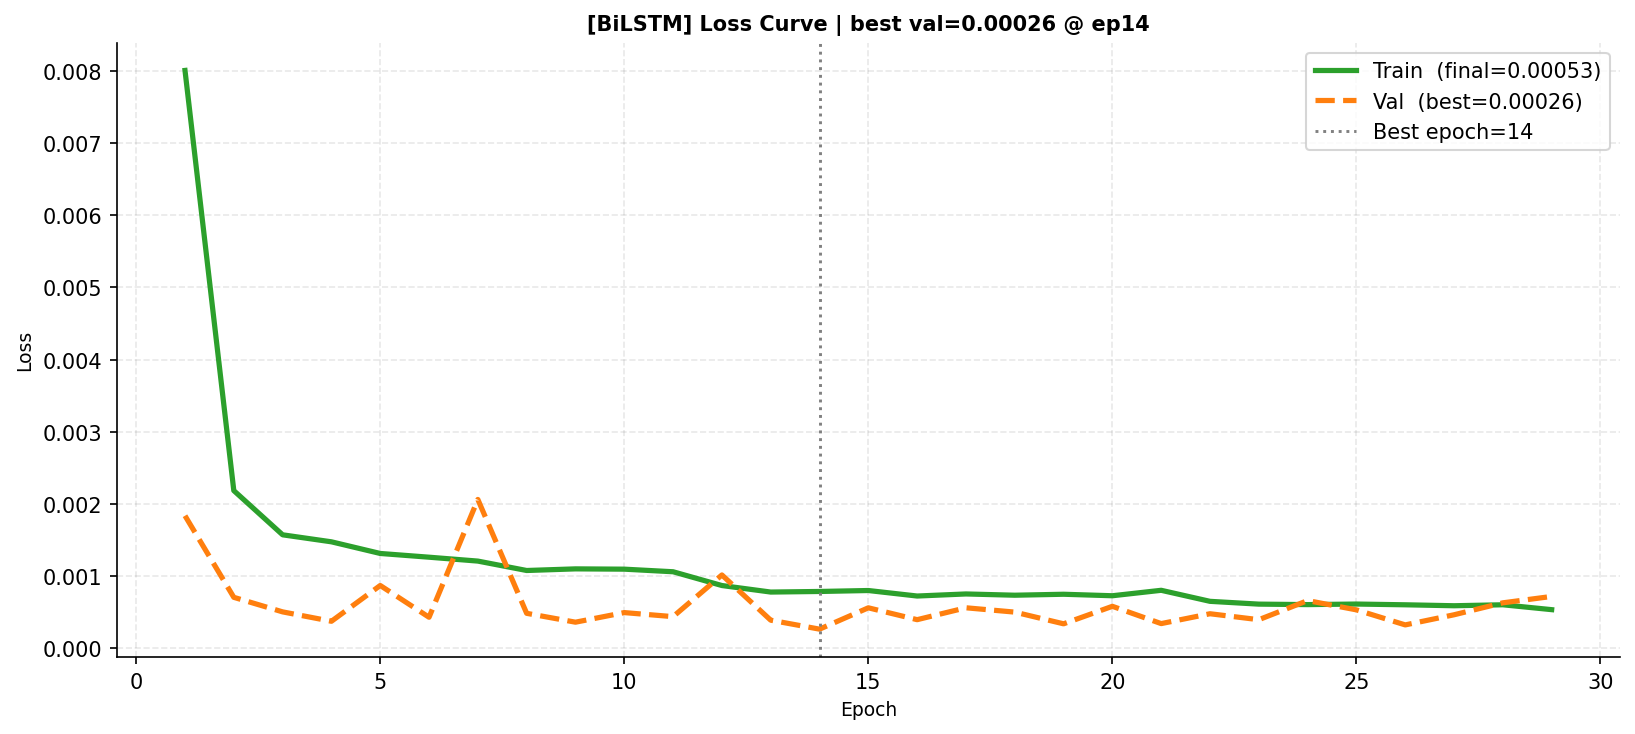

  Saved → plots/BiLSTM_1_loss.png


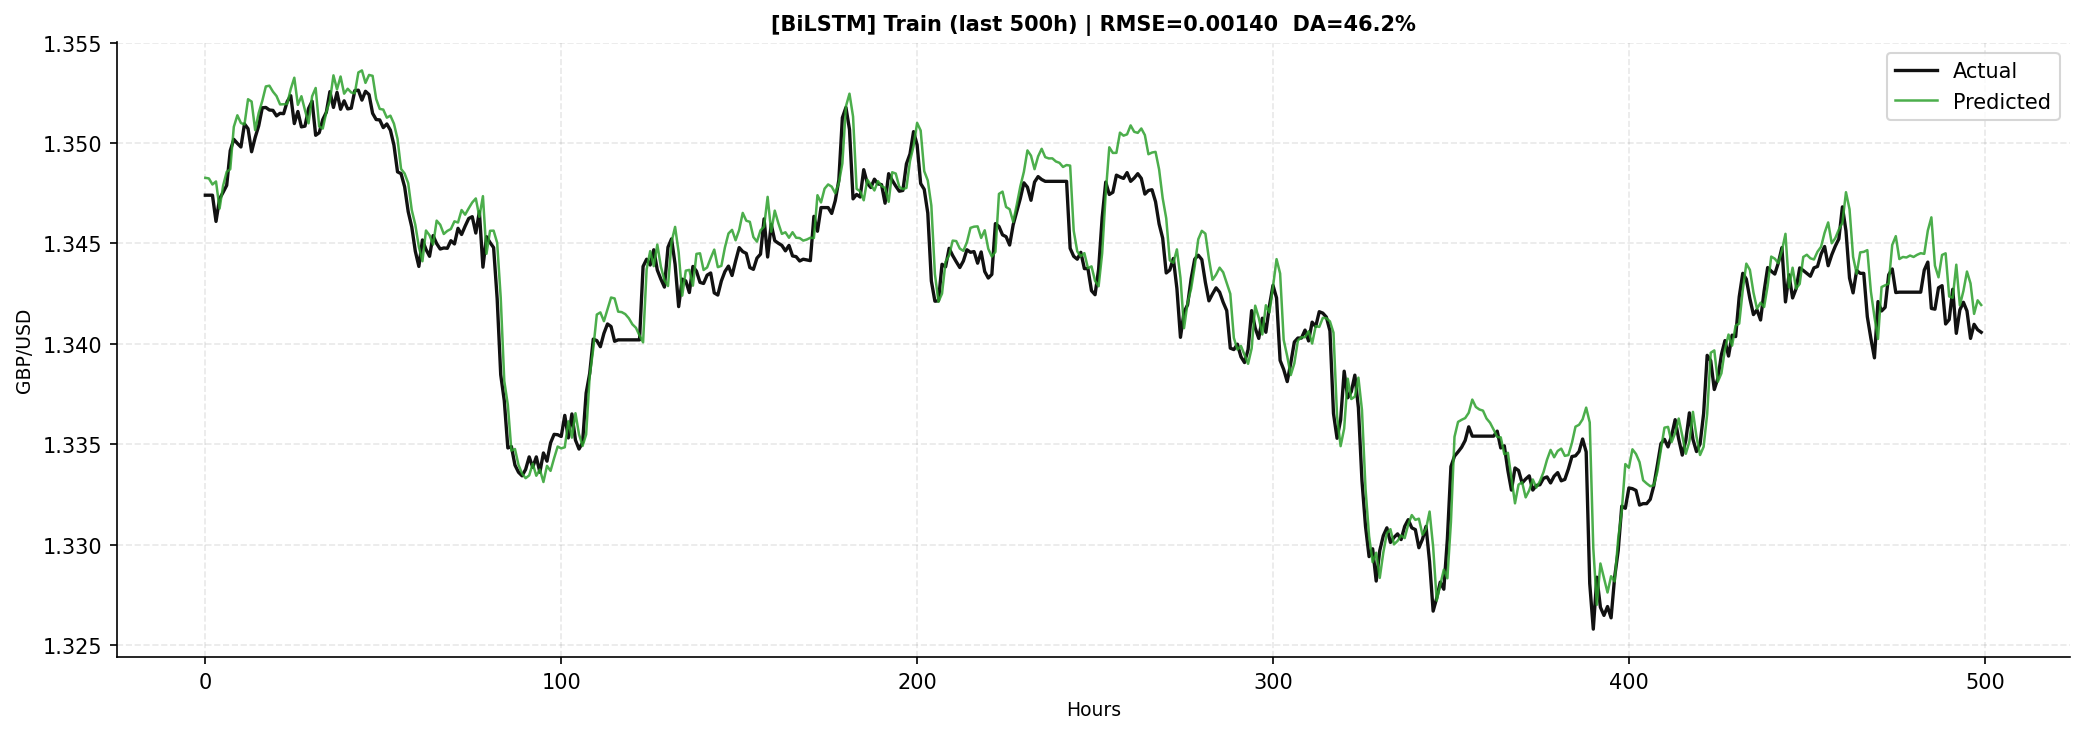

  Saved → plots/BiLSTM_2_train.png


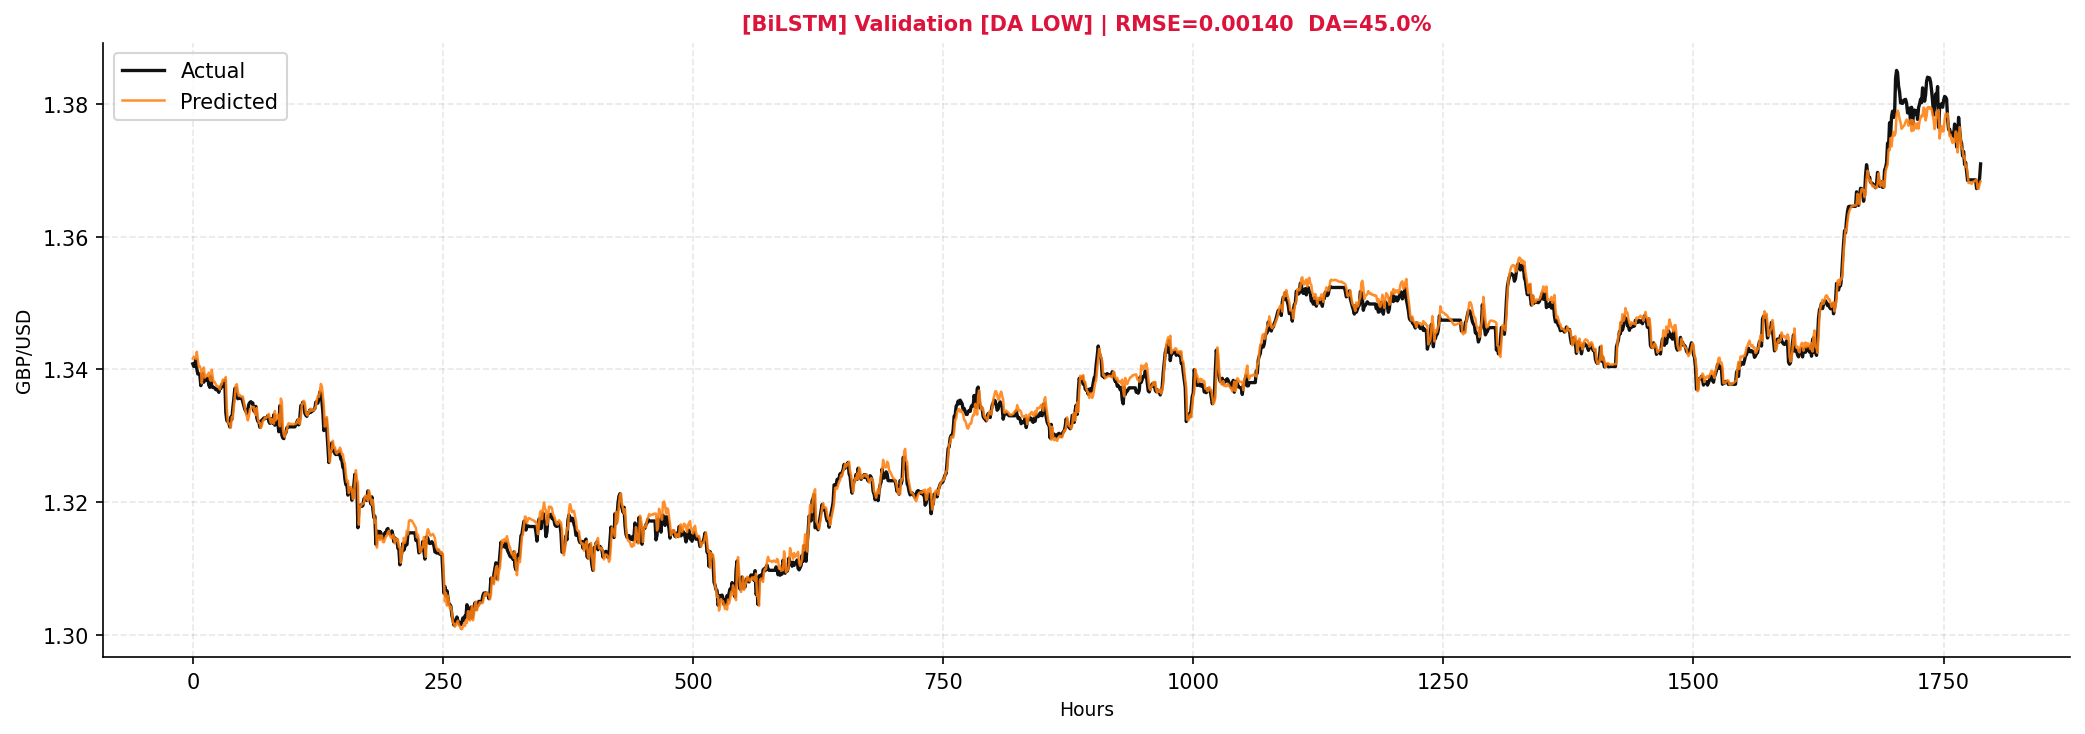

  Saved → plots/BiLSTM_3_val.png


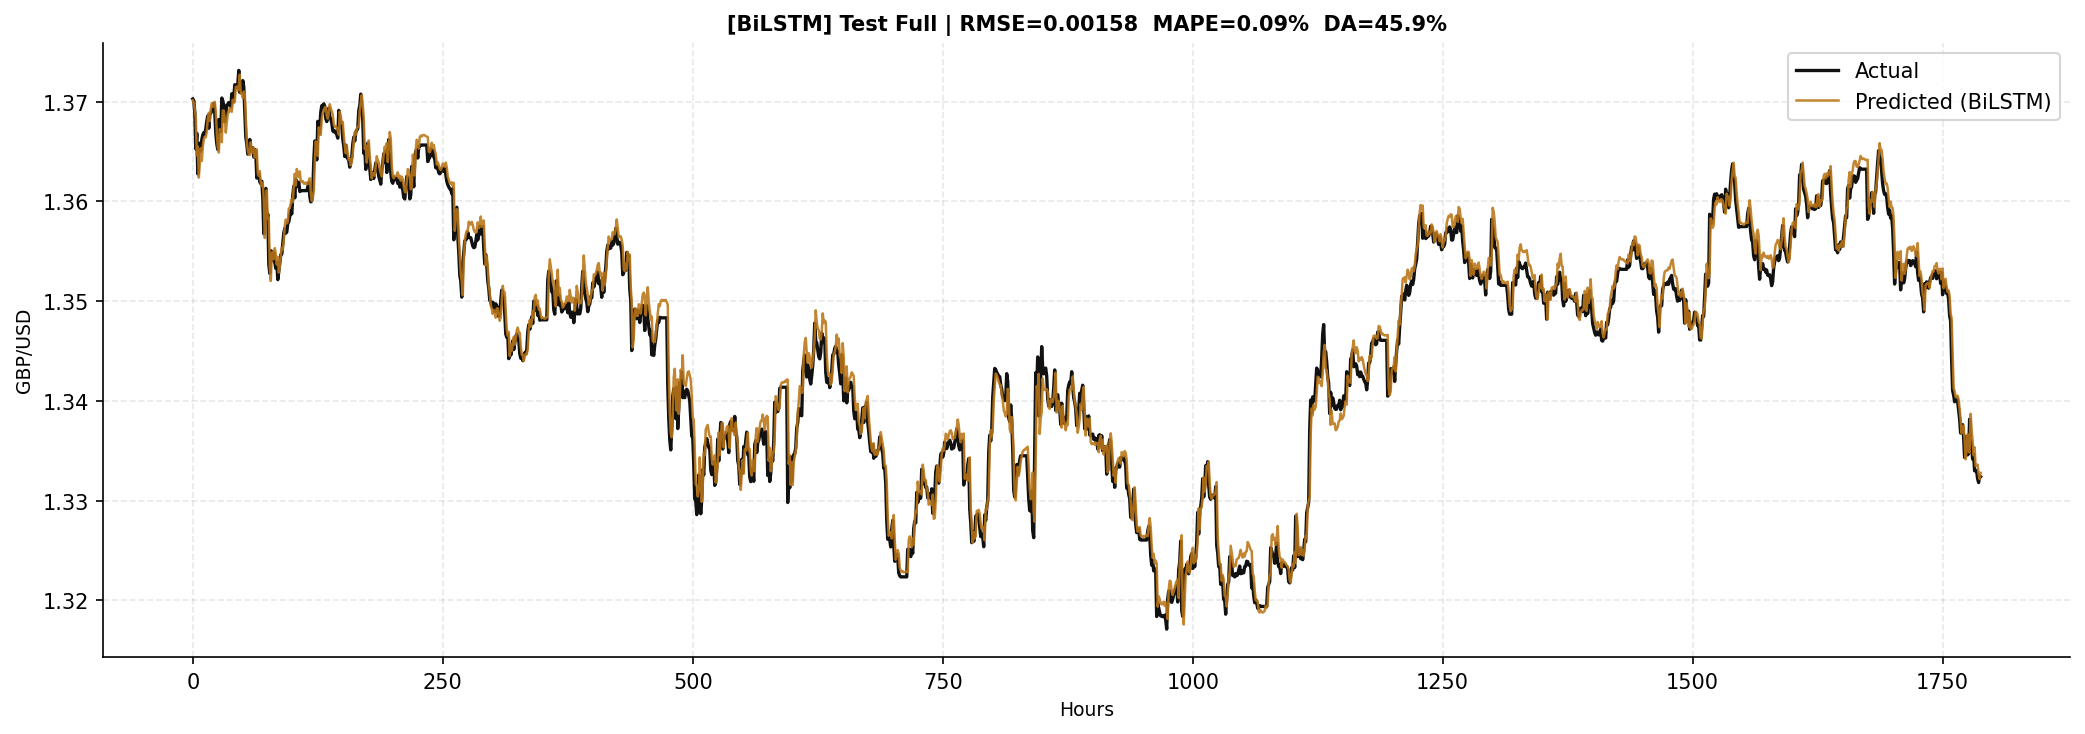

  Saved → plots/BiLSTM_4_test_full.png


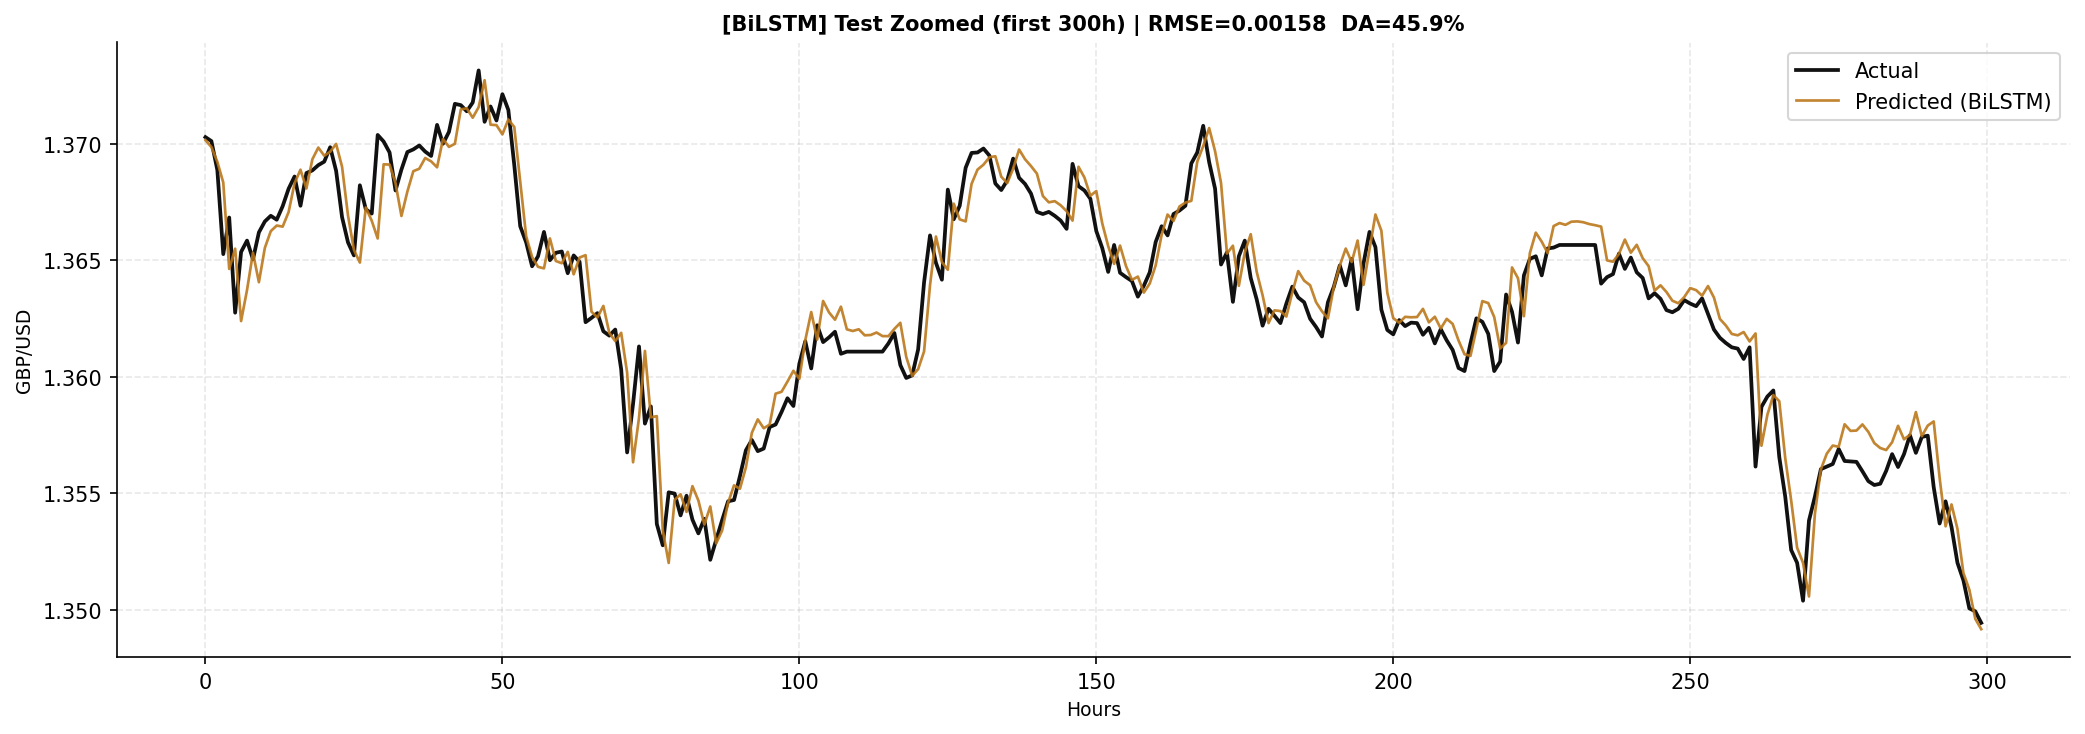

  Saved → plots/BiLSTM_5_test_zoom.png


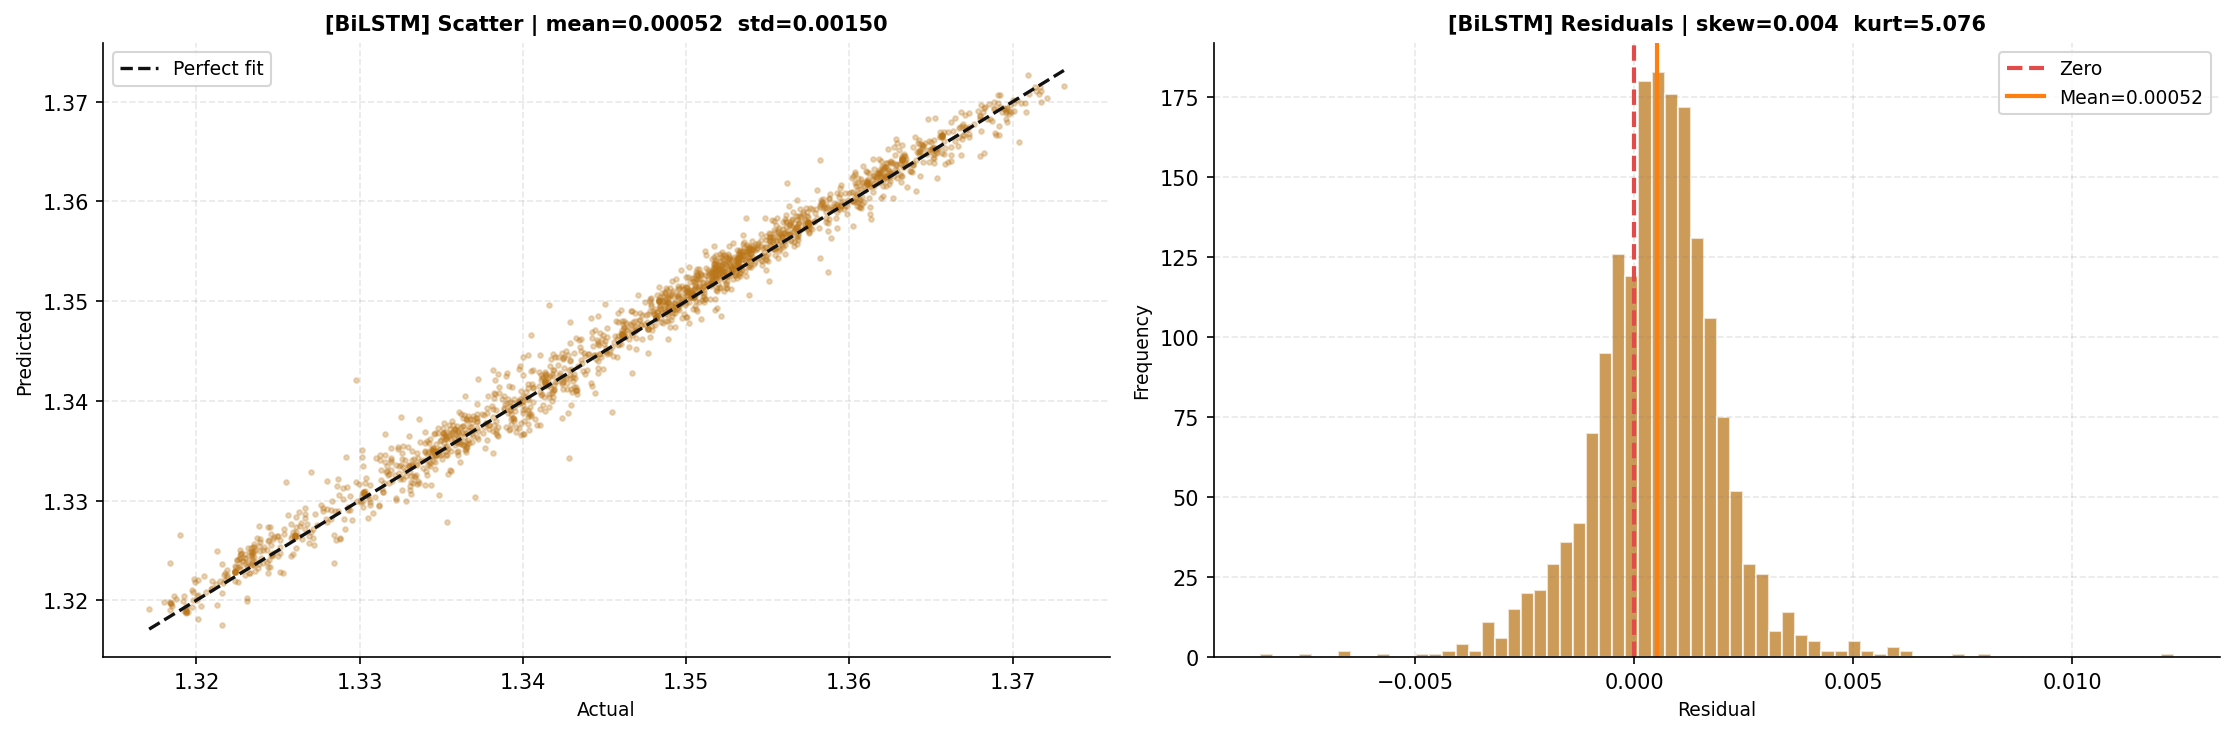

  Saved → plots/BiLSTM_6_scatter_residual.png
  BiLSTM complete.



In [40]:
print("  [BiLSTM]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "BiLSTM", bilstm_history,
    bilstm_train_preds, bilstm_train_actual,
    bilstm_val_preds,   bilstm_val_actual,
    bilstm_test_preds,  bilstm_test_actual,
    bilstm_test_metrics, COLORS["BiLSTM"]
)

results["BiLSTM"] = {
    "history": bilstm_history,
    "val_metrics":  bilstm_val_metrics,
    "preds":   bilstm_test_preds,
    "actual":  bilstm_test_actual,
    "metrics": bilstm_test_metrics,
    "params":  bilstm_model.count_params(),
    "time":    bilstm_time,
}
print("  BiLSTM complete.\n")


# **Vanilla RNN**

**BUILD**

In [41]:
print("\n  [RNN]  STEP 1 : BUILD")
print("  " + "-" * 55)
rnn_model = build_rnn(INPUT_SHAPE, UNITS, DROPOUT)
rnn_model.summary()
print(f"  Parameters : {rnn_model.count_params():,}")


  [RNN]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 48, 128)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,281 (223.75 KB)

 Trainable params: 57,281 (223.75 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 57,281


**TRAIN**

In [42]:
print("\n  [RNN]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
rnn_history, rnn_time = train_model(
    rnn_model, "Vanilla_RNN", X_train, y_train, X_val, y_val
)


  [RNN]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=8,346  Val=1,788

Epoch 1/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0704 - mae: 0.2565 - val_loss: 0.0119 - val_mae: 0.1225 - learning_rate: 0.0010
Epoch 2/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0155 - mae: 0.1255 - val_loss: 0.0023 - val_mae: 0.0448 - learning_rate: 0.0010
Epoch 3/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0068 - mae: 0.0849 - val_loss: 0.0022 - val_mae: 0.0494 - learning_rate: 0.0010
Epoch 4/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0071 - mae: 0.0825 - val_loss: 0.0112 - val_mae: 0.1139 - learning_rate: 0.0010
Epoch 5/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0110 - mae: 0.1055 - val_loss: 0.0053 - val_mae: 0.0745 - learning_rate: 0.0010
Epoch 6/100
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0083 - mae: 0.0942 - val_loss: 0.0072 - val_mae: 0.0943 - learning_rate: 0.0010
Epoch 7/100
261/261 ━━━━━━

**VALIDATION REPORT**

In [43]:
print("\n  [RNN]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
rnn_val_preds, rnn_val_actual, rnn_val_metrics = run_inference(
    rnn_model, X_val, y_val
)
rnn_val_ok = print_validation_report("Vanilla_RNN", rnn_val_metrics)


  [RNN]  STEP 3 : VALIDATE
  -------------------------------------------------------

  [Vanilla_RNN] VALIDATION
  RMSE=0.00261  MAE=0.00176  MAPE=0.13%  NRMSE=3.12%
  DA=46.33%  [LOW — below random baseline!]


**TEST**

In [44]:
print("\n  [RNN]  STEP 4 : TEST")
print("  " + "-" * 55)
rnn_train_preds, rnn_train_actual, _ = run_inference(rnn_model, X_train, y_train)
rnn_test_preds,  rnn_test_actual, rnn_test_metrics = run_inference(
    rnn_model, X_test, y_test
)
print_test_report("Vanilla_RNN", rnn_test_metrics, rnn_model.count_params(), rnn_time)


  [RNN]  STEP 4 : TEST
  -------------------------------------------------------

  [Vanilla_RNN] TEST RESULTS
  Params=57,281  Time=179.9s
  RMSE=0.00201  MAE=0.00160  MAPE=0.12%  NRMSE=3.59%
  DA=46.09%  [CHECK]


**PLOT**

  [RNN]  STEP 5 : PLOT
  -------------------------------------------------------


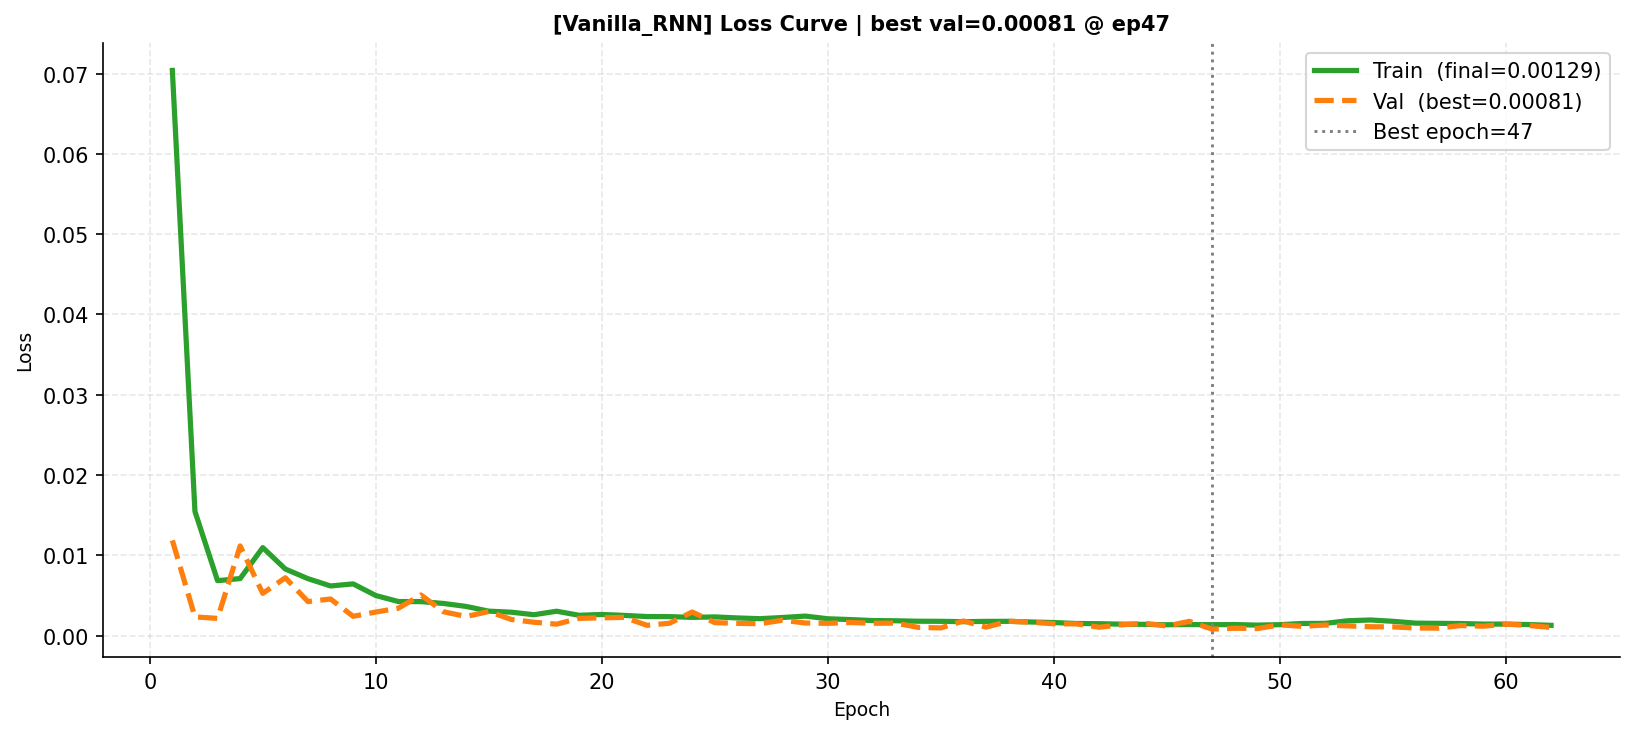

  Saved → plots/Vanilla_RNN_1_loss.png


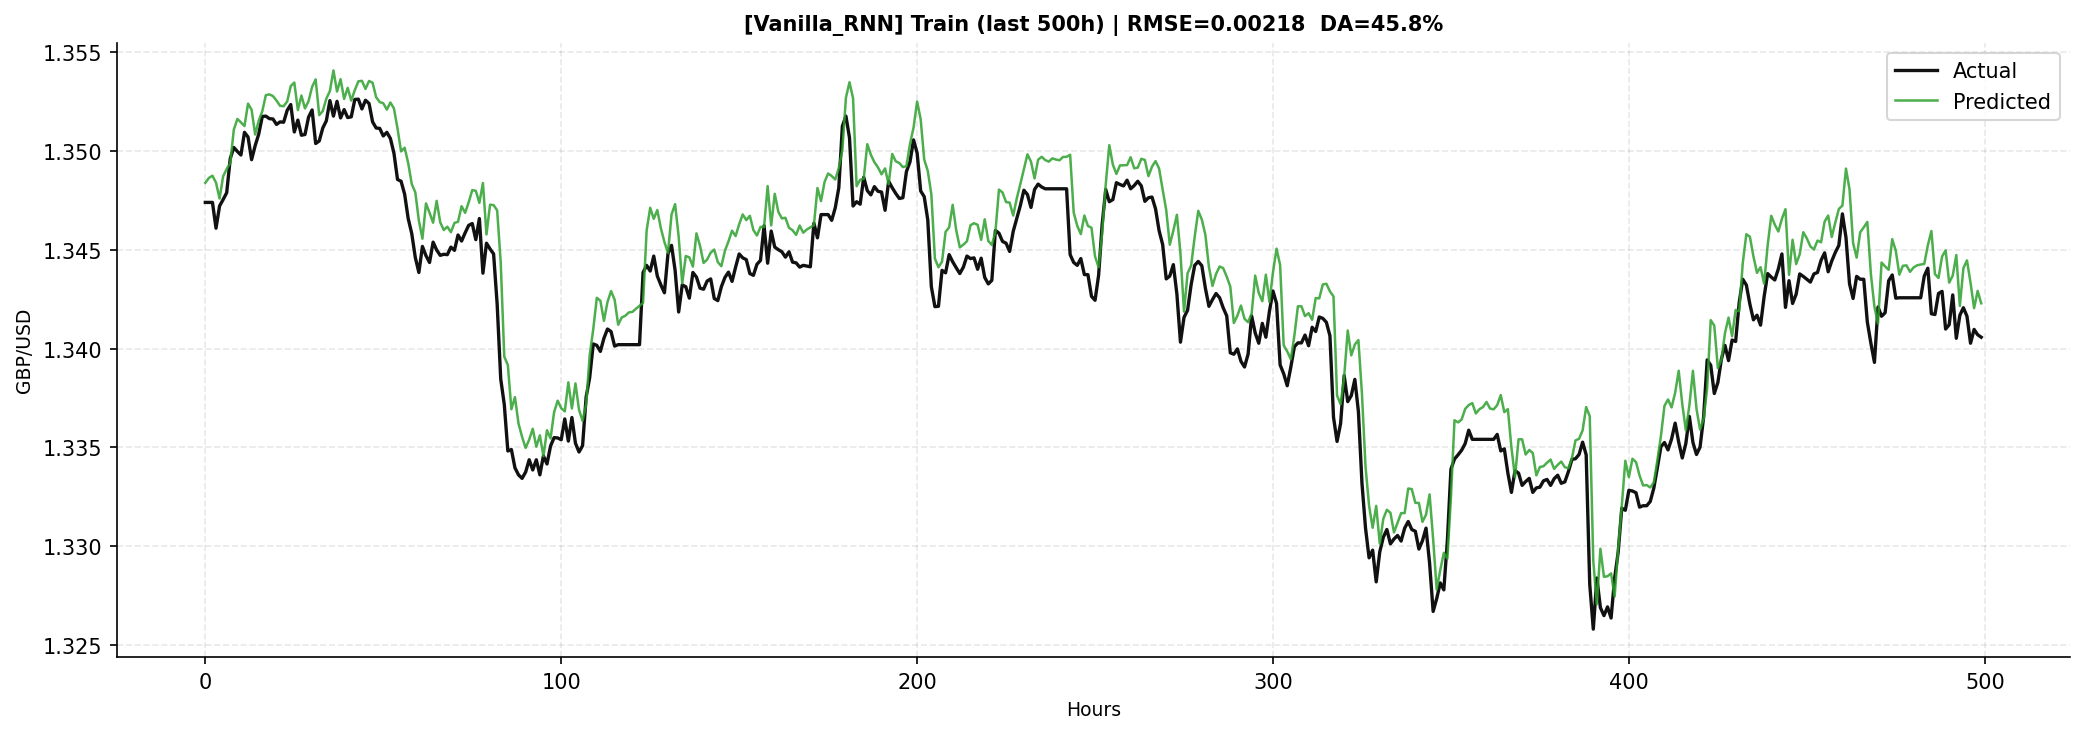

  Saved → plots/Vanilla_RNN_2_train.png


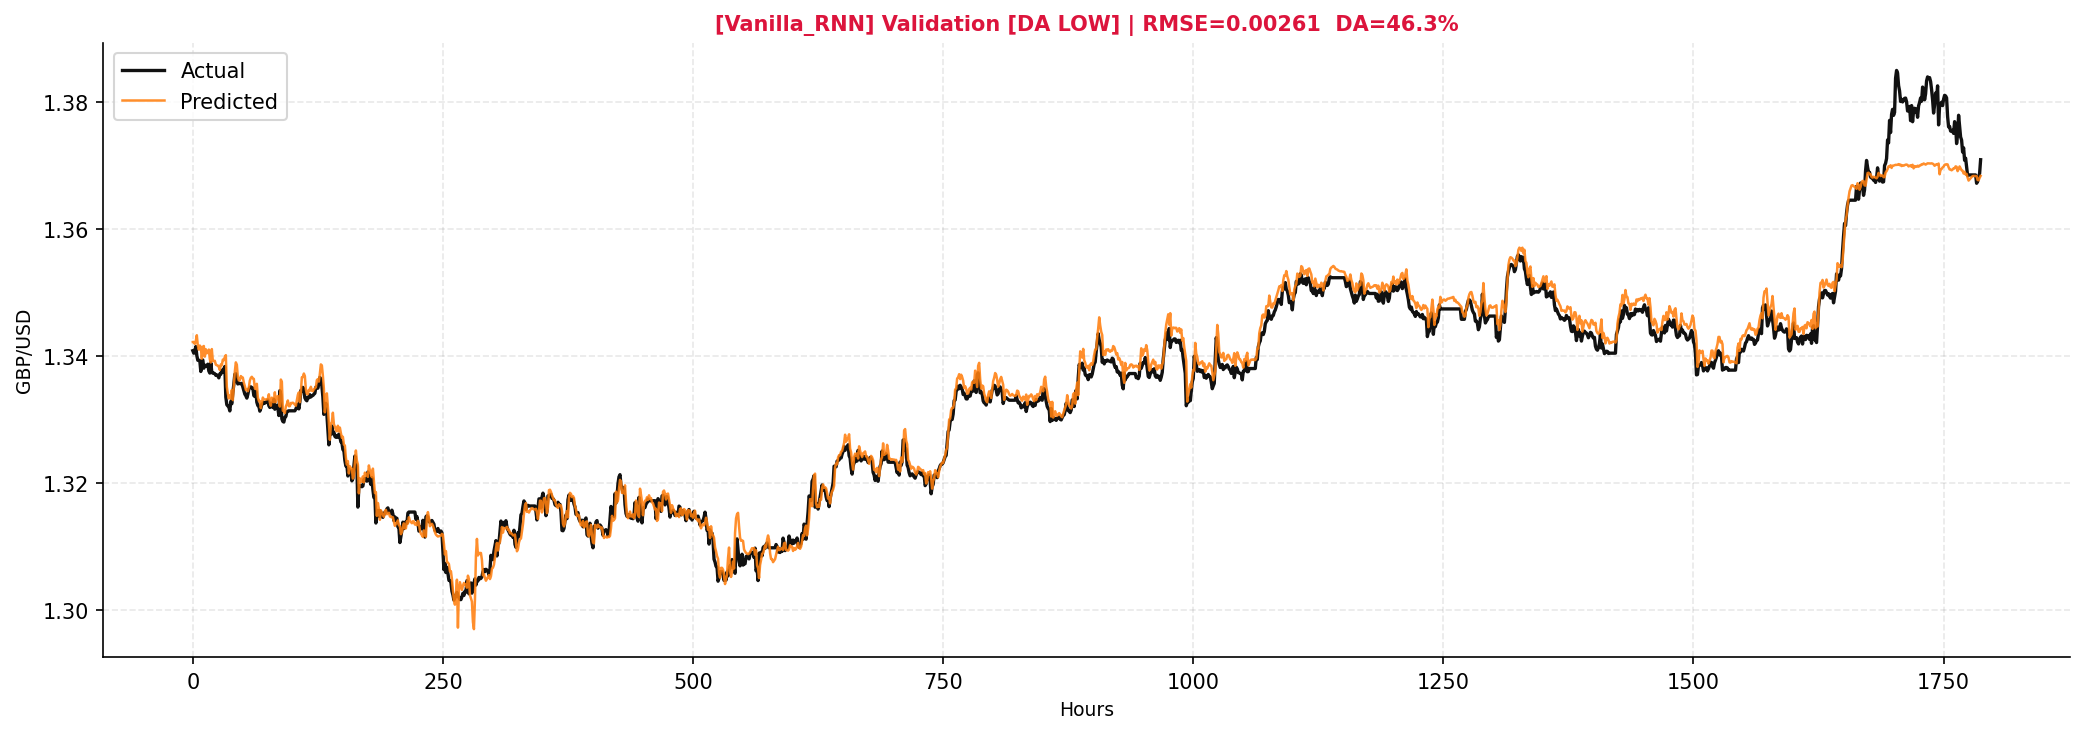

  Saved → plots/Vanilla_RNN_3_val.png


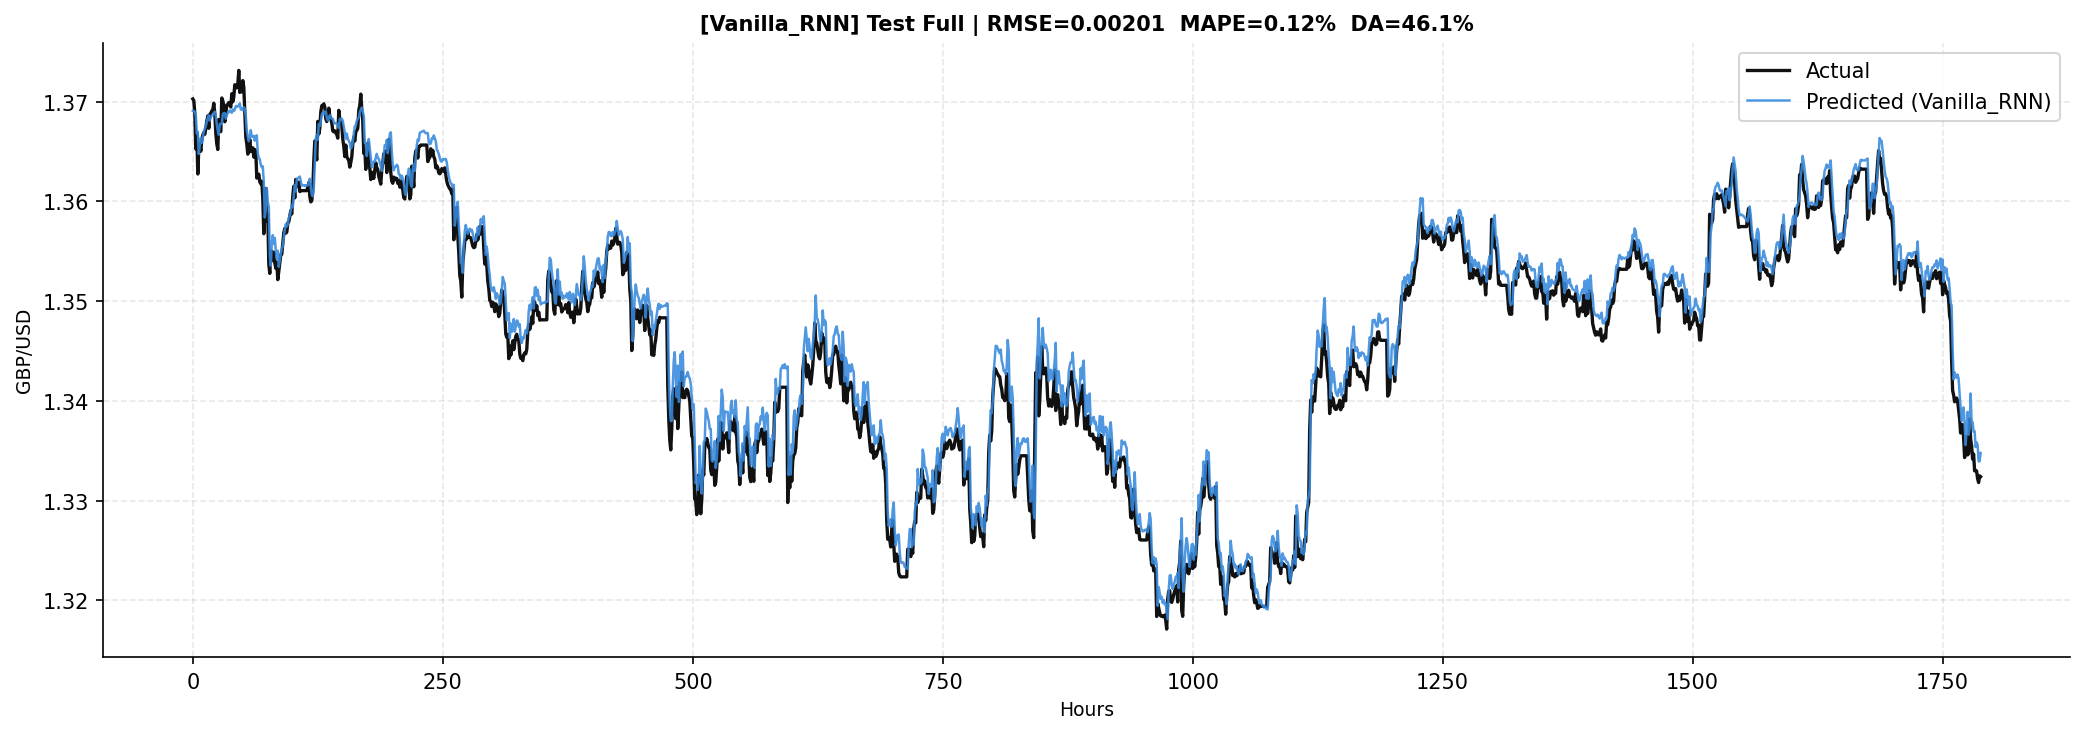

  Saved → plots/Vanilla_RNN_4_test_full.png


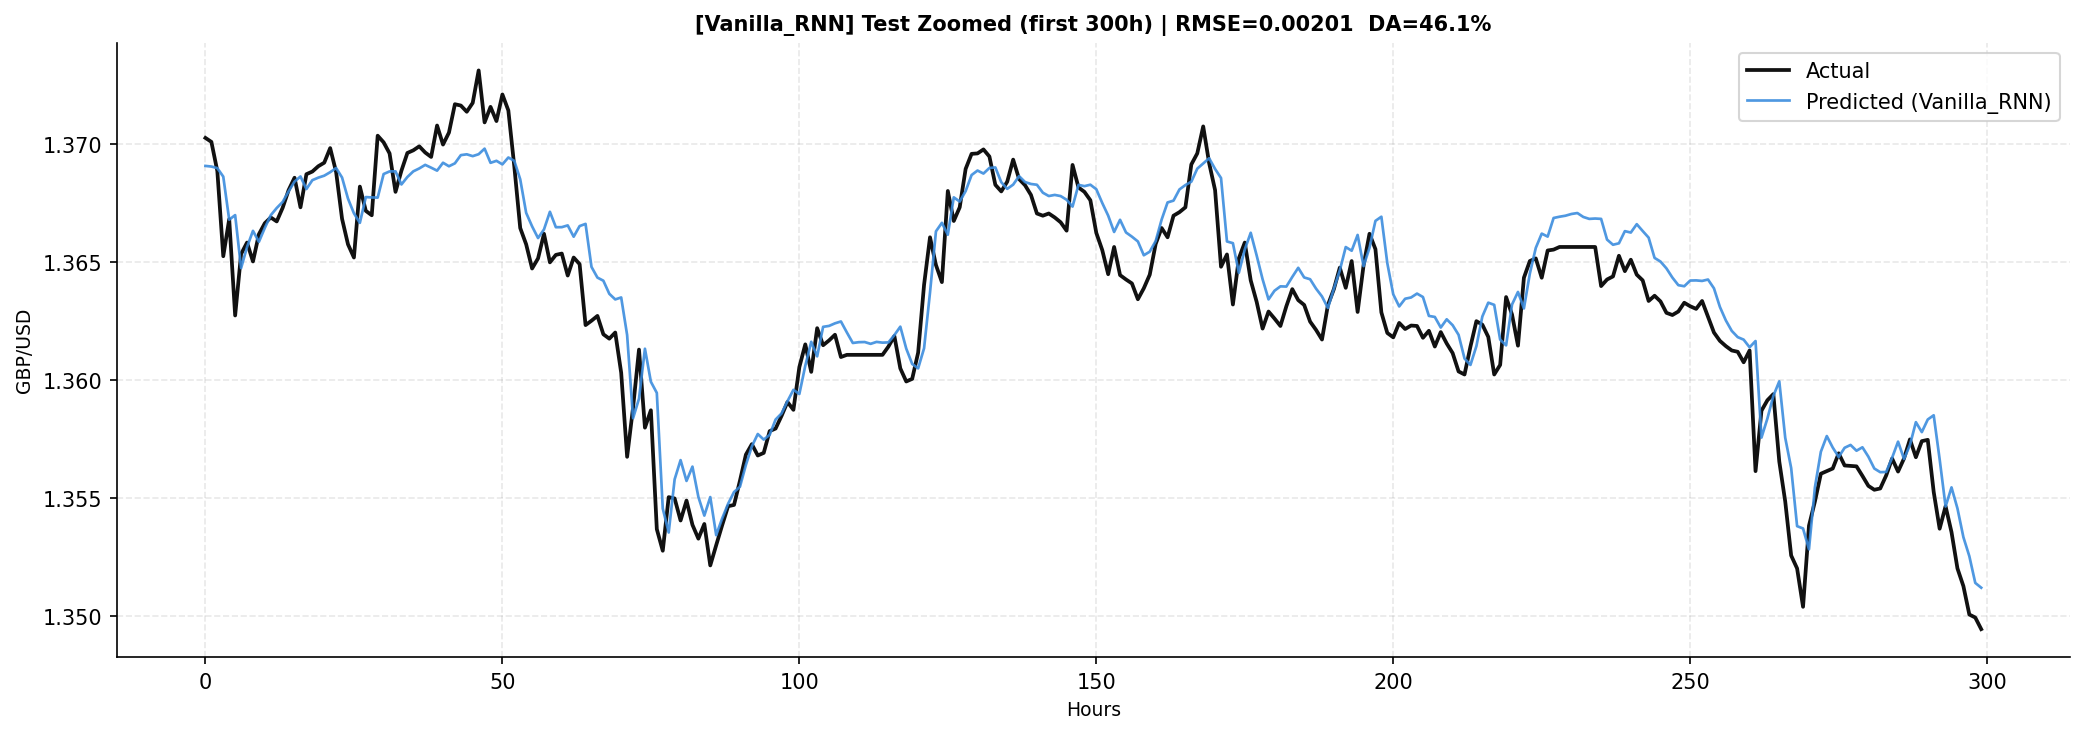

  Saved → plots/Vanilla_RNN_5_test_zoom.png


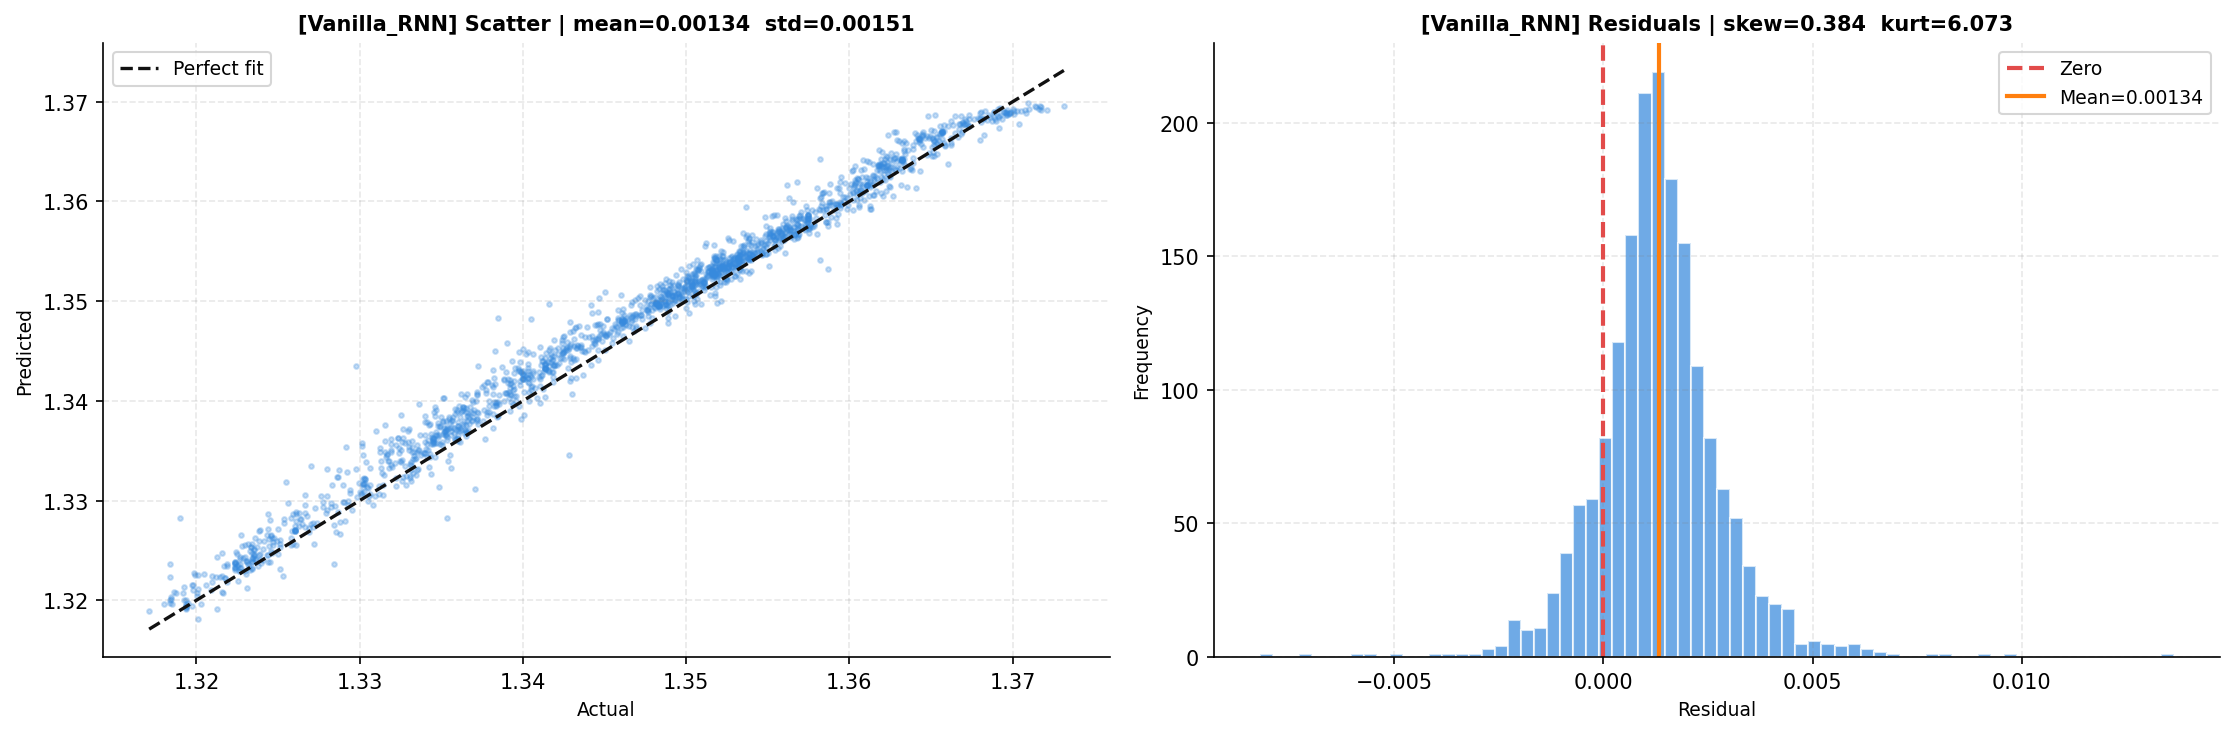

  Saved → plots/Vanilla_RNN_6_scatter_residual.png
  Vanilla RNN complete.



In [45]:
print("  [RNN]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "Vanilla_RNN", rnn_history,
    rnn_train_preds, rnn_train_actual,
    rnn_val_preds,   rnn_val_actual,
    rnn_test_preds,  rnn_test_actual,
    rnn_test_metrics, COLORS["Vanilla_RNN"]
)

results["Vanilla_RNN"] = {
    "history": rnn_history,
    "val_metrics":  rnn_val_metrics,
    "preds":   rnn_test_preds,
    "actual":  rnn_test_actual,
    "metrics": rnn_test_metrics,
    "params":  rnn_model.count_params(),
    "time":    rnn_time,
}
print("  Vanilla RNN complete.\n")

# **CROSS-MODEL COMPARISON**



  CROSS-MODEL COMPARISON

  Validation Set  (used to adjust model before test):
             Val RMSE  Val MAE  Val MAPE  Val DA %
Model                                             
LSTM          0.00150  0.00100     0.074     45.83
GRU           0.00117  0.00084     0.063     45.89
BiLSTM        0.00140  0.00105     0.078     45.05
Vanilla_RNN   0.00261  0.00176     0.131     46.33

  Test Set  (held-out — final performance):
                RMSE      MAE  MAPE (%)  DA (%)  Params  Time (s)
Model                                                            
LSTM         0.00151  0.00110     0.082   45.97  216641     112.7
GRU          0.00140  0.00098     0.073   46.64  164289     124.4
BiLSTM       0.00158  0.00119     0.088   45.92  330305     136.5
Vanilla_RNN  0.00201  0.00160     0.119   46.09   57281     179.9


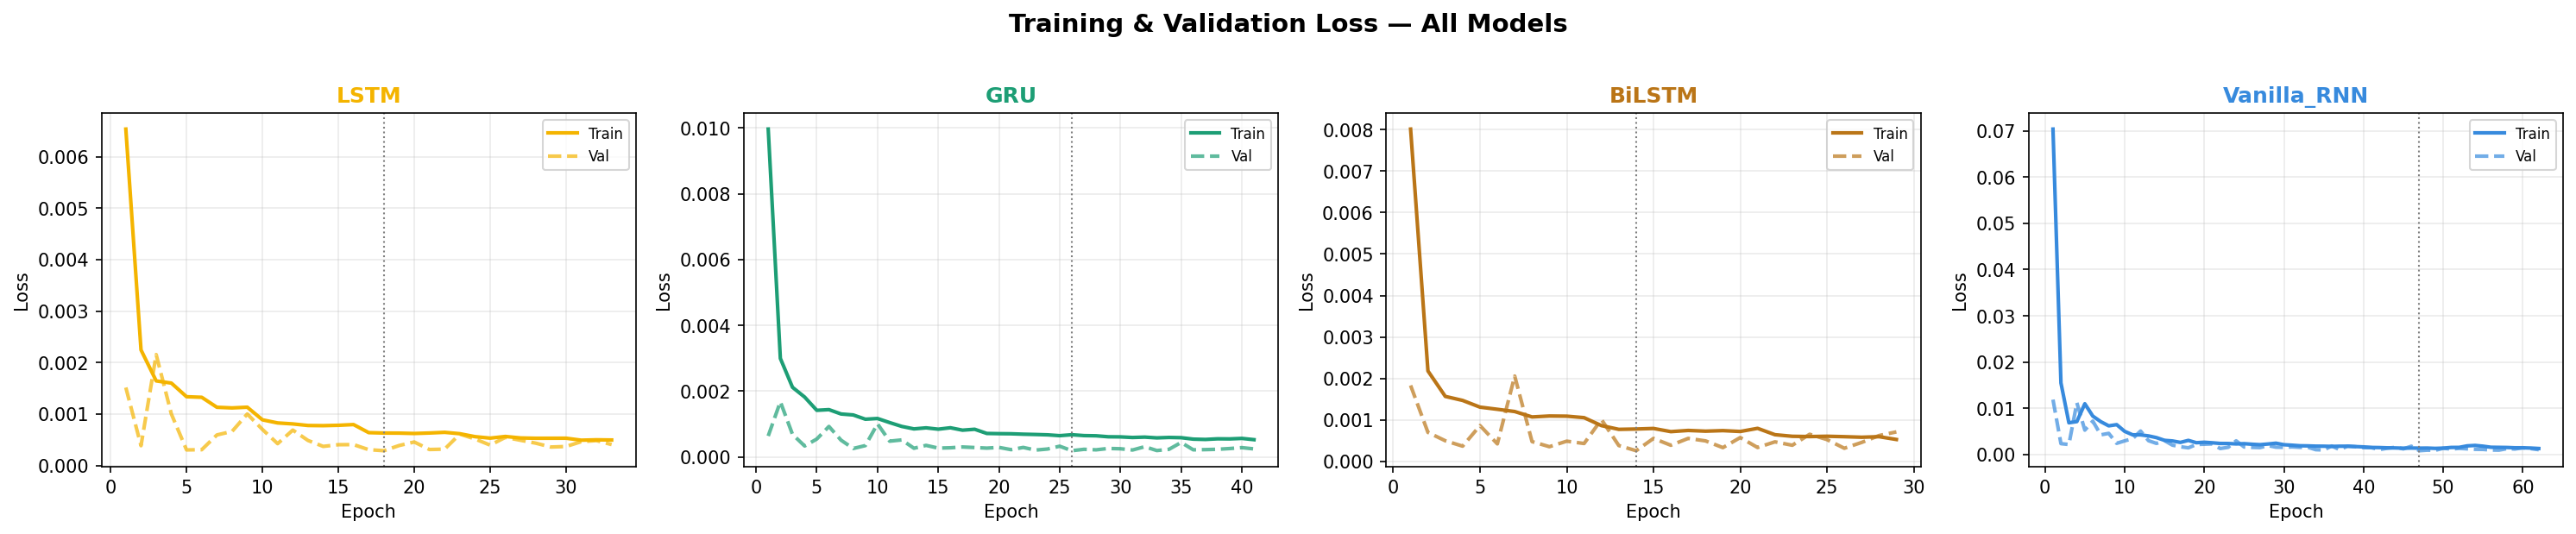

  Saved -> plots/comparison_01_loss.png


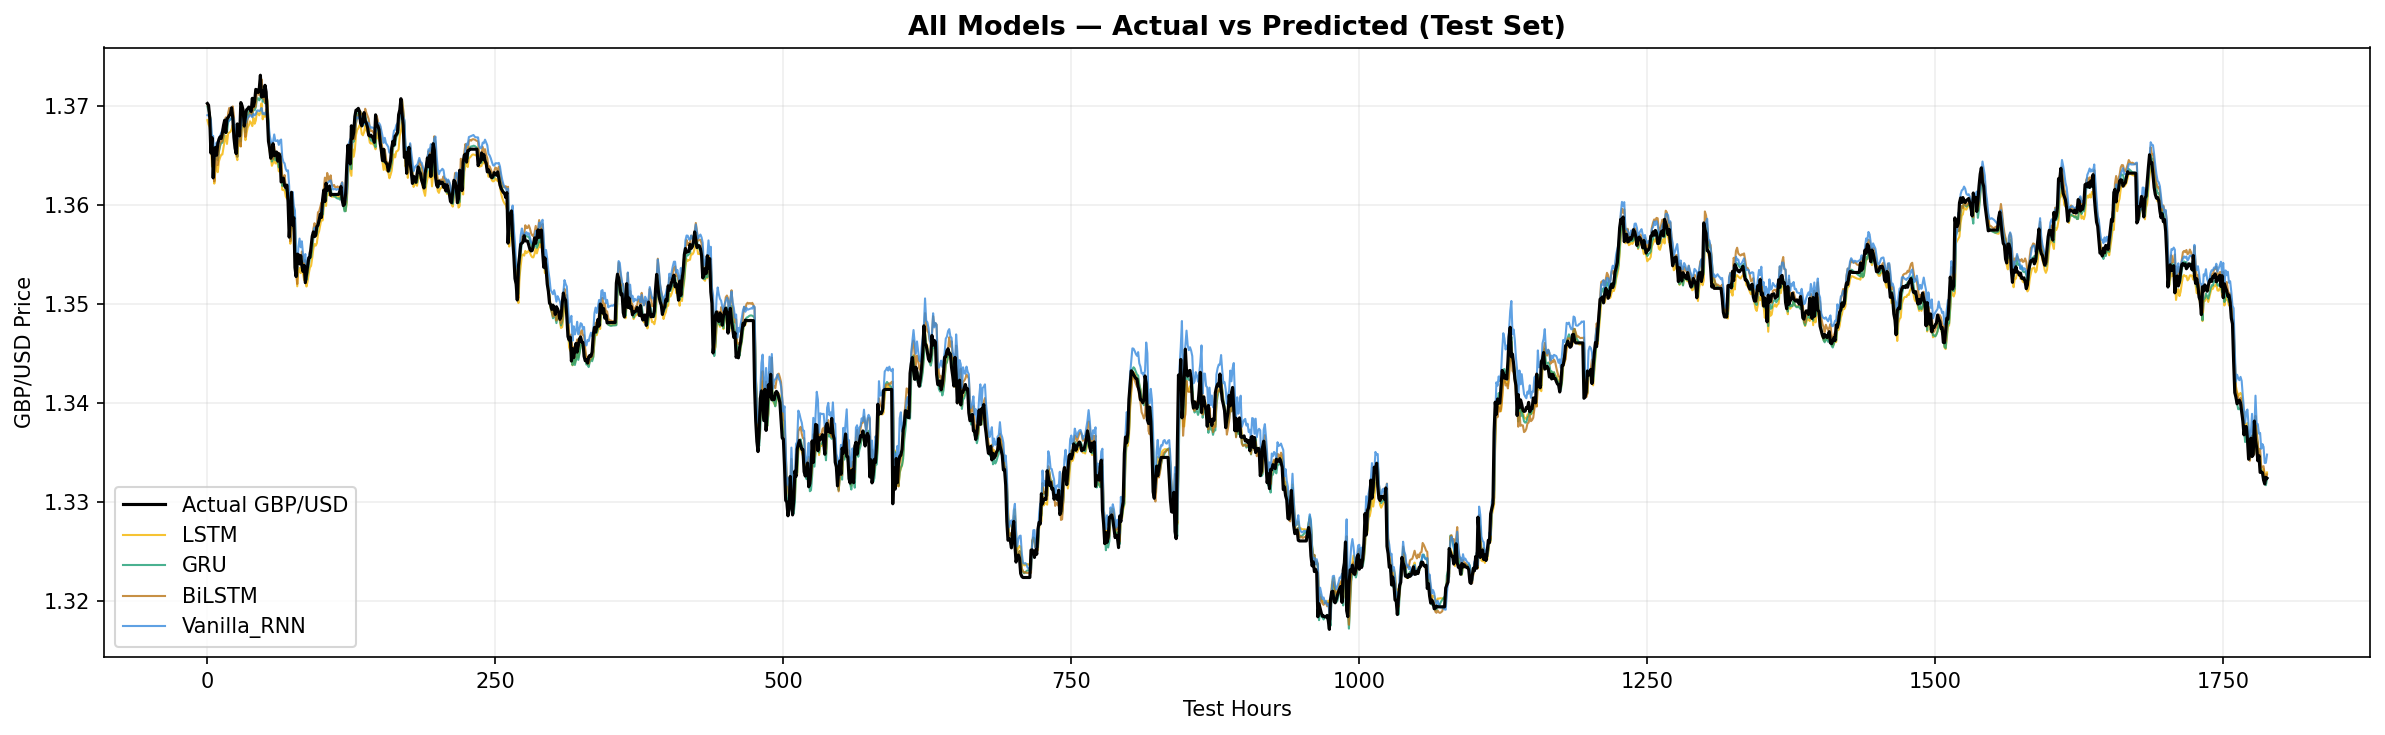

  Saved -> plots/comparison_02_overlay.png


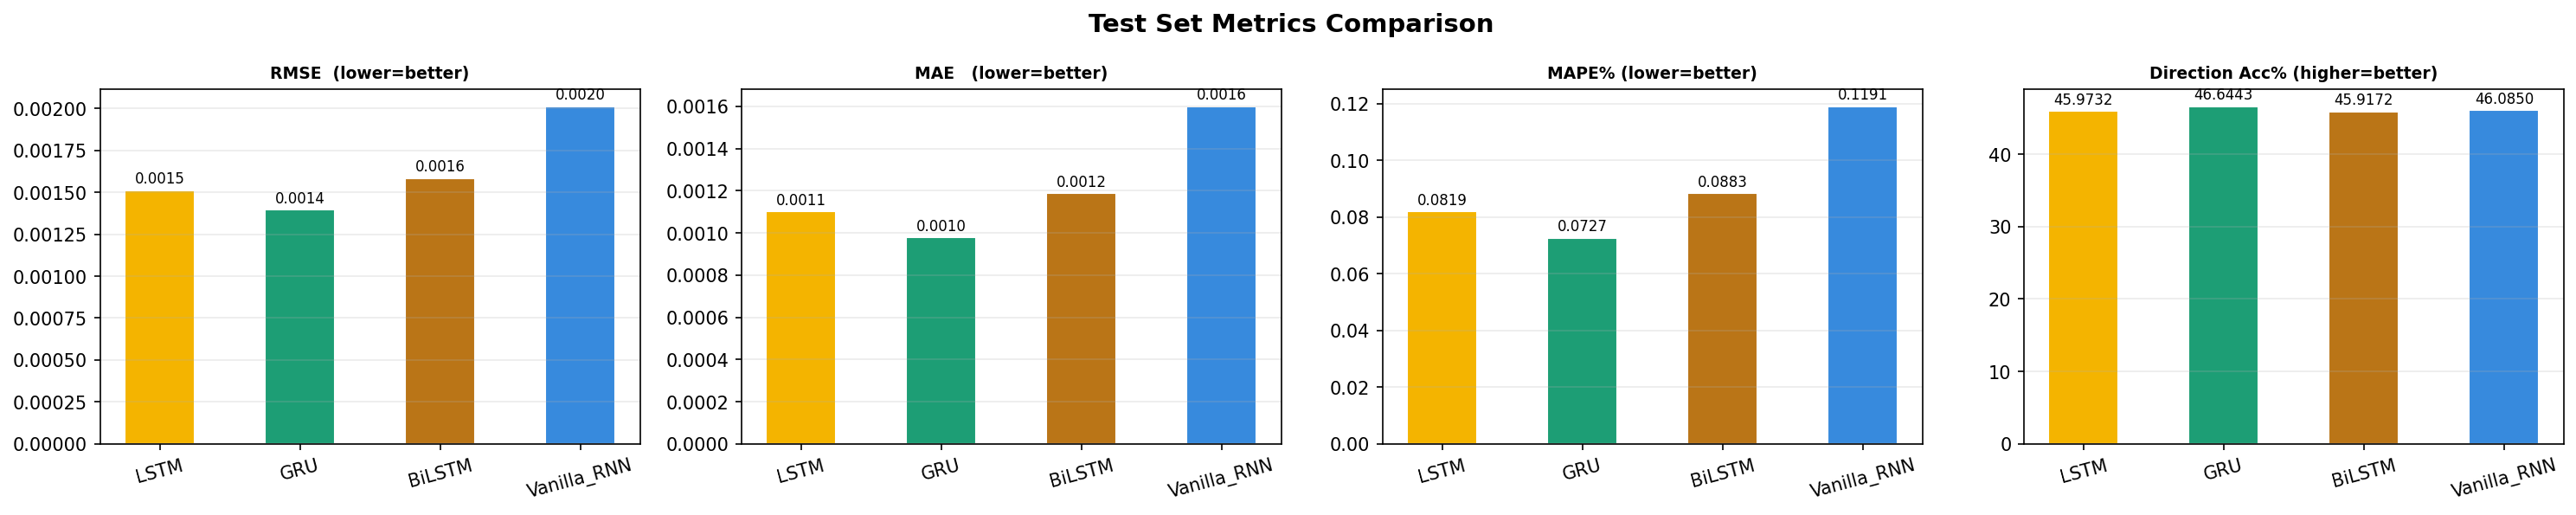

  Saved -> plots/comparison_03_metrics.png


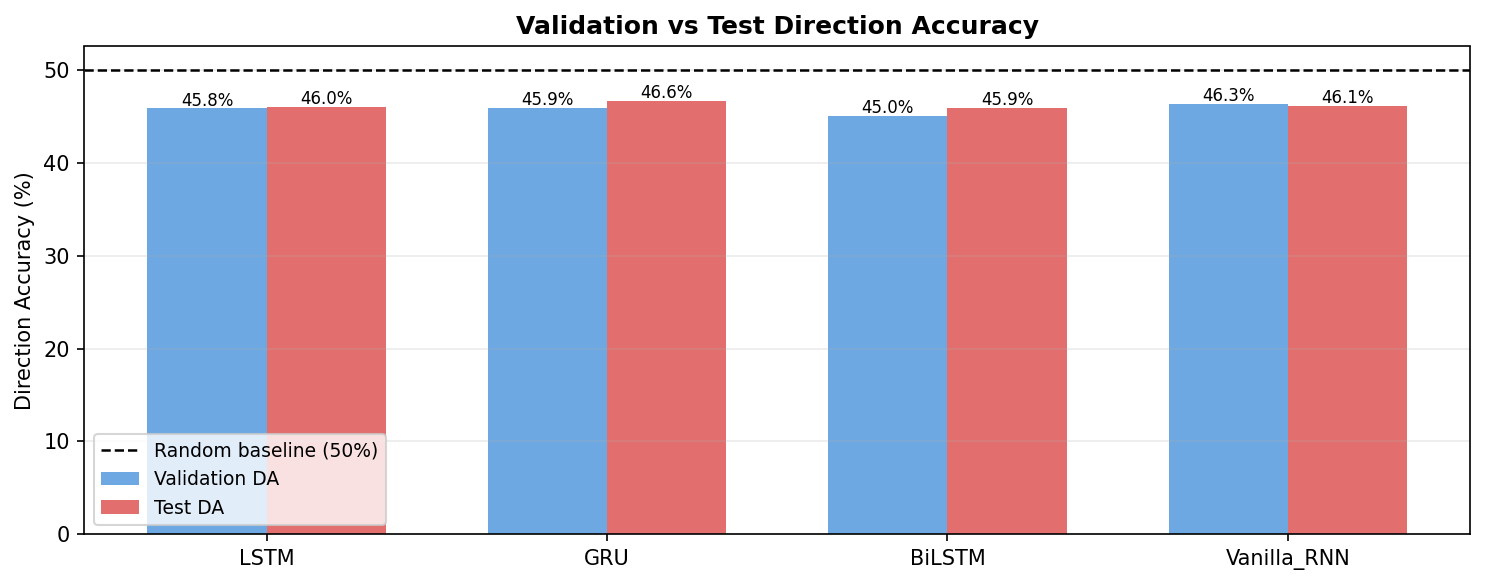

  Saved -> plots/comparison_04_da_val_vs_test.png


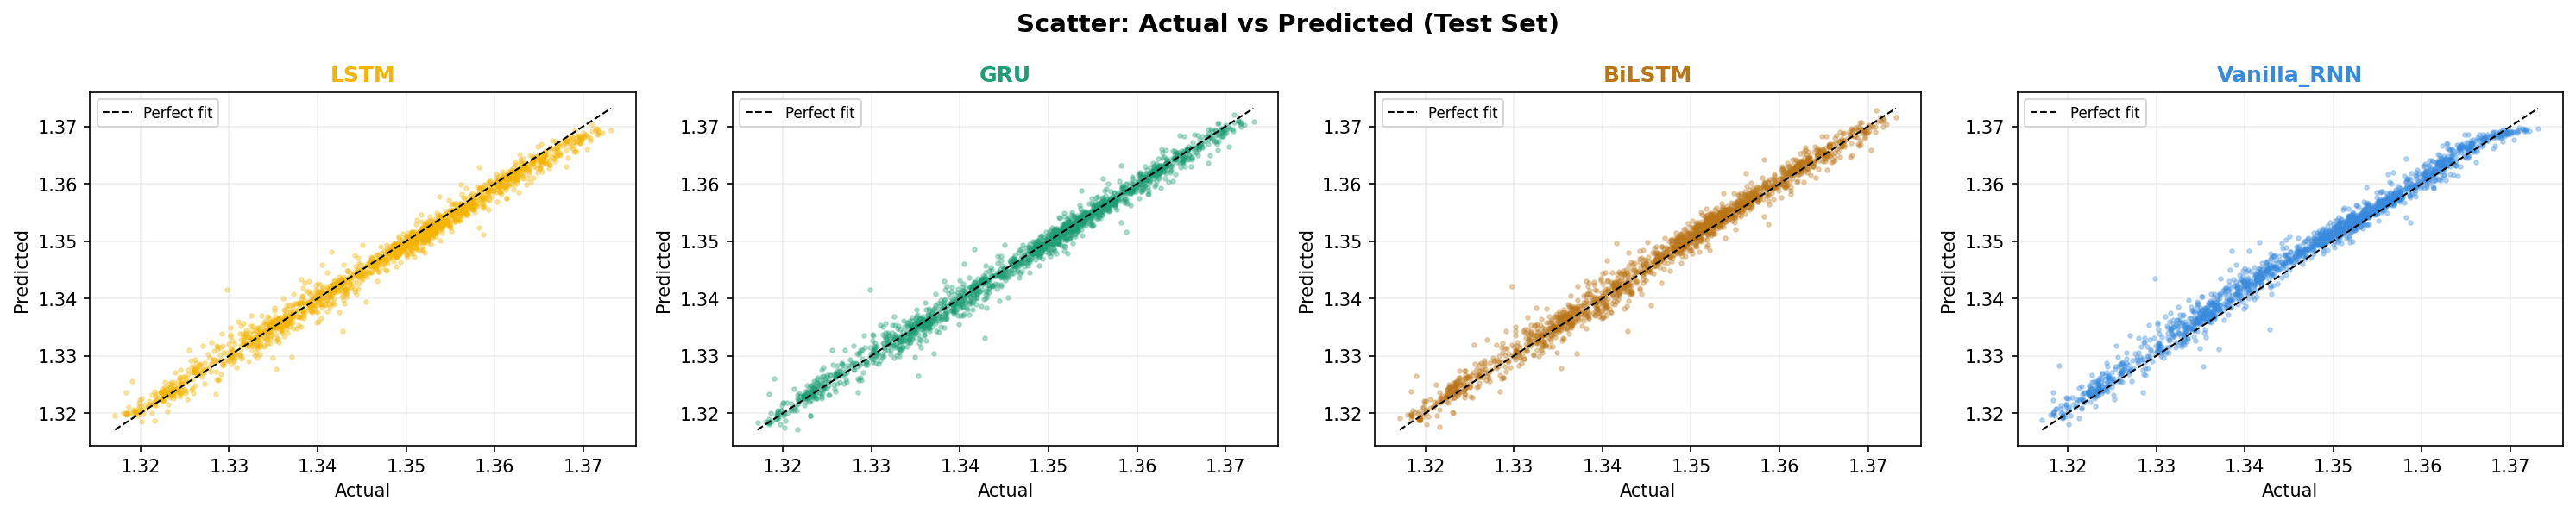

  Saved -> plots/comparison_05_scatter.png


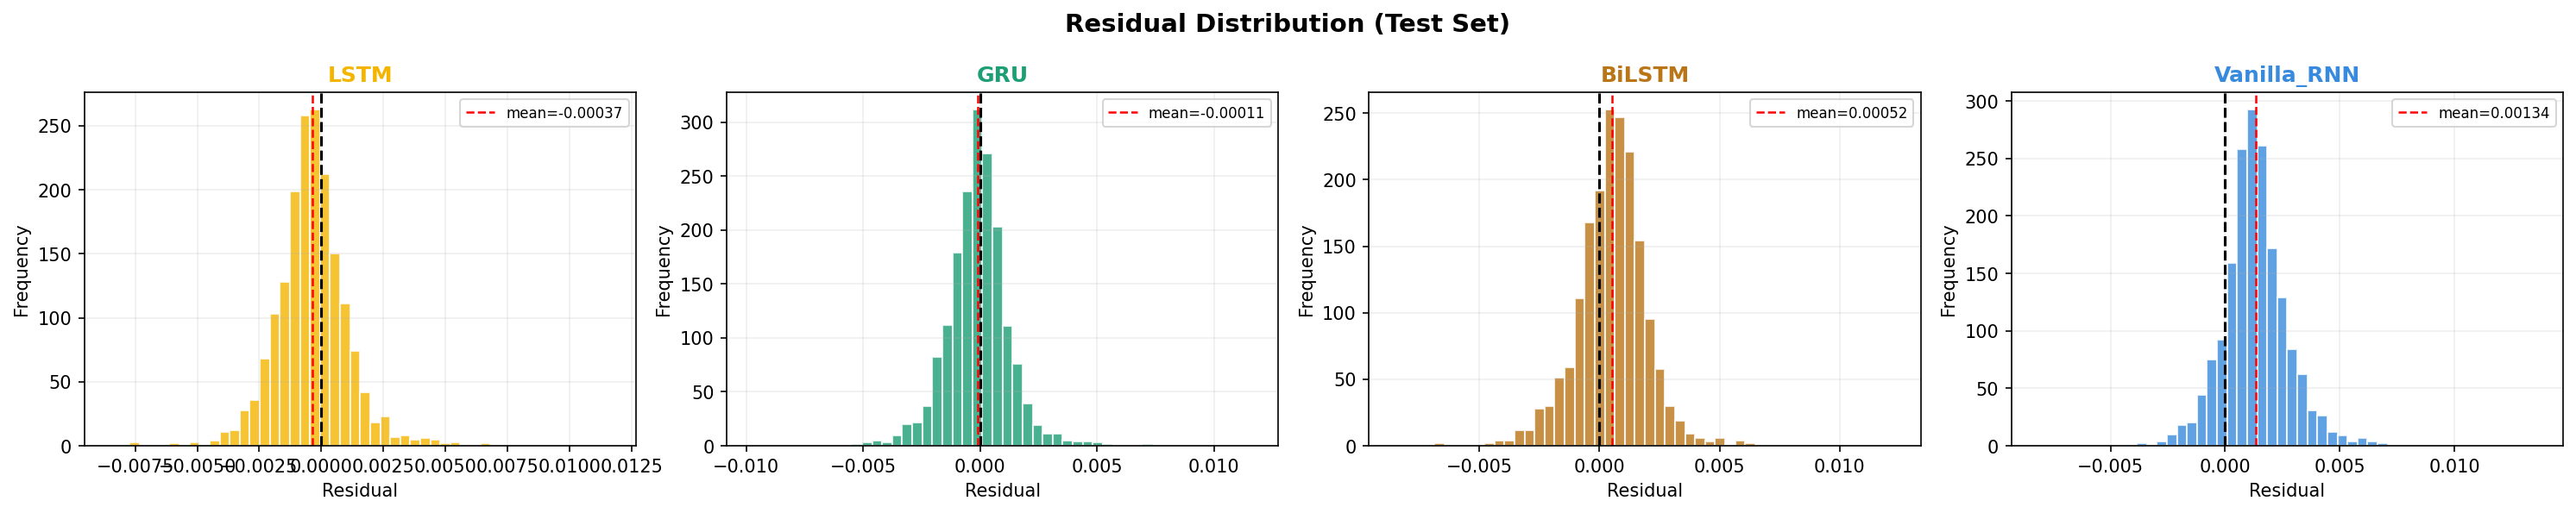

  Saved -> plots/comparison_06_residuals.png


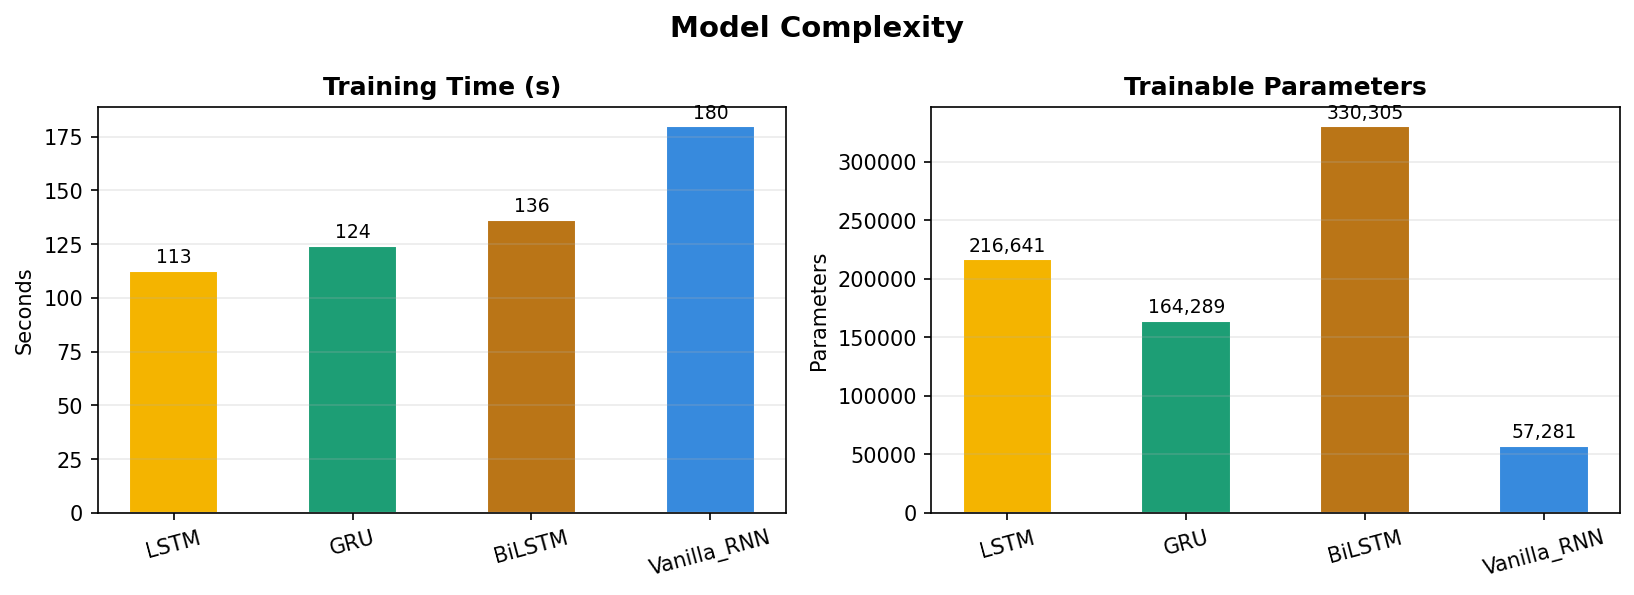

  Saved -> plots/comparison_07_complexity.png


In [46]:
MODEL_NAMES = ["LSTM", "GRU", "BiLSTM", "Vanilla_RNN"]

print("\n\n" + "=" * 70)
print("  CROSS-MODEL COMPARISON")
print("=" * 70)

# ── Validation vs Test comparison table ──────────────────────────────────────
print("\n  Validation Set  (used to adjust model before test):")
val_rows = []
for name in MODEL_NAMES:
    m = results[name]["val_metrics"]
    val_rows.append({
        "Model": name,
        "Val RMSE": round(m["RMSE"], 5),
        "Val MAE":  round(m["MAE"],  5),
        "Val MAPE": round(m["MAPE"], 3),
        "Val DA %": round(m["DA (%)"], 2),
    })
val_df = pd.DataFrame(val_rows).set_index("Model")
print(val_df.to_string())

print("\n  Test Set  (held-out — final performance):")
rows = []
for name in MODEL_NAMES:
    m = results[name]["metrics"]
    rows.append({
        "Model":    name,
        "RMSE":     round(m["RMSE"],   5),
        "MAE":      round(m["MAE"],    5),
        "MAPE (%)": round(m["MAPE"],   3),
        "DA (%)":   round(m["DA (%)"], 2),
        "Params":   results[name]["params"],
        "Time (s)": round(results[name]["time"], 1),
    })
results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())
results_df.to_csv(os.path.join(PLOTS_DIR, "comparison_table.csv"))

# ── Plot 1 : Loss curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Training & Validation Loss — All Models",
             fontsize=14, fontweight="bold", y=1.02)
for ax, name in zip(axes, MODEL_NAMES):
    h   = results[name]["history"].history
    eps = range(1, len(h["loss"]) + 1)
    c   = COLORS[name]
    ax.plot(eps, h["loss"],     color=c, lw=2,   label="Train")
    ax.plot(eps, h["val_loss"], color=c, lw=2,
            linestyle="--", alpha=0.7, label="Val")
    best_ep = int(np.argmin(h["val_loss"])) + 1
    ax.axvline(best_ep, color="grey", lw=1, linestyle=":")
    ax.set_title(name, color=c, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_01_loss.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 2 : Overlay on test set ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
actual_ref = results["LSTM"]["actual"]
ax.plot(actual_ref, color="black", lw=1.5, label="Actual GBP/USD", zorder=5)
for name in MODEL_NAMES:
    ax.plot(results[name]["preds"], color=COLORS[name], lw=1.0,
            alpha=0.8, label=name)
ax.set_title("All Models — Actual vs Predicted (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Test Hours")
ax.set_ylabel("GBP/USD Price")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_02_overlay.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 3 : Metrics bar charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Test Set Metrics Comparison", fontsize=14, fontweight="bold")
metric_defs = [
    ("RMSE",   "RMSE  (lower=better)"),
    ("MAE",    "MAE   (lower=better)"),
    ("MAPE",   "MAPE% (lower=better)"),
    ("DA (%)", "Direction Acc% (higher=better)"),
]
for ax, (key, label) in zip(axes, metric_defs):
    values = [results[n]["metrics"][key] for n in MODEL_NAMES]
    colors = [COLORS[n] for n in MODEL_NAMES]
    bars   = ax.bar(MODEL_NAMES, values, color=colors, width=0.5, edgecolor="white")
    ax.set_title(label, fontweight="bold", fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.25)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_03_metrics.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 4 : Val vs Test DA comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x    = np.arange(len(MODEL_NAMES))
w    = 0.35
val_da  = [results[n]["val_metrics"]["DA (%)"]  for n in MODEL_NAMES]
test_da = [results[n]["metrics"]["DA (%)"]       for n in MODEL_NAMES]
ax.bar(x - w/2, val_da,  w, label="Validation DA", color="#5599DD", alpha=0.85)
ax.bar(x + w/2, test_da, w, label="Test DA",       color="#DD5555", alpha=0.85)
ax.axhline(50, color="black", lw=1.2, linestyle="--", label="Random baseline (50%)")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES)
ax.set_ylabel("Direction Accuracy (%)")
ax.set_title("Validation vs Test Direction Accuracy", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.25)
for i, (v, t) in enumerate(zip(val_da, test_da)):
    ax.text(i - w/2, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)
    ax.text(i + w/2, t + 0.3, f"{t:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_04_da_val_vs_test.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 5 : Scatter ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Scatter: Actual vs Predicted (Test Set)", fontsize=14, fontweight="bold")
for ax, name in zip(axes, MODEL_NAMES):
    p_ = results[name]["preds"]
    a_ = results[name]["actual"]
    ax.scatter(a_, p_, s=5, alpha=0.3, color=COLORS[name])
    lo, hi = min(a_.min(), p_.min()), max(a_.max(), p_.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="Perfect fit")
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_05_scatter.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 6 : Residuals ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Residual Distribution (Test Set)", fontsize=14, fontweight="bold")
for ax, name in zip(axes, MODEL_NAMES):
    res = results[name]["preds"] - results[name]["actual"]
    ax.hist(res, bins=50, color=COLORS[name], alpha=0.8, edgecolor="white")
    ax.axvline(0,          color="black", lw=1.5, linestyle="--")
    ax.axvline(res.mean(), color="red",   lw=1.2, linestyle="--",
               label=f"mean={res.mean():.5f}")
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_06_residuals.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 7 : Complexity ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Model Complexity", fontsize=14, fontweight="bold")
times  = [results[n]["time"]   for n in MODEL_NAMES]
params = [results[n]["params"] for n in MODEL_NAMES]
clrs   = [COLORS[n]            for n in MODEL_NAMES]
for ax, vals, title, ylabel in [
    (ax1, times,  "Training Time (s)",    "Seconds"),
    (ax2, params, "Trainable Parameters", "Parameters"),
]:
    bars = ax.bar(MODEL_NAMES, vals, color=clrs, width=0.5, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_07_complexity.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")


  CROSS-MODEL COMPARISON

  Validation:
             Val RMSE  Val MAE  Val MAPE  Val DA %
Model                                             
LSTM          0.00150  0.00100     0.074     45.83
GRU           0.00117  0.00084     0.063     45.89
BiLSTM        0.00140  0.00105     0.078     45.05
Vanilla_RNN   0.00261  0.00176     0.131     46.33

  Test:
                RMSE      MAE  MAPE (%)  NRMSE (%)  DA (%)  Params  Time (s)
Model                                                                       
LSTM         0.00151  0.00110     0.082      2.699   45.97  216641     112.7
GRU          0.00140  0.00098     0.073      2.493   46.64  164289     124.4
BiLSTM       0.00158  0.00119     0.088      2.828   45.92  330305     136.5
Vanilla_RNN  0.00201  0.00160     0.119      3.594   46.09   57281     179.9

  WINNER PER METRIC:
  Metric       Winner         Value
  ----------------------------------------
  RMSE         GRU            0.0014
  MAE          GRU            0.00098
  MAPE

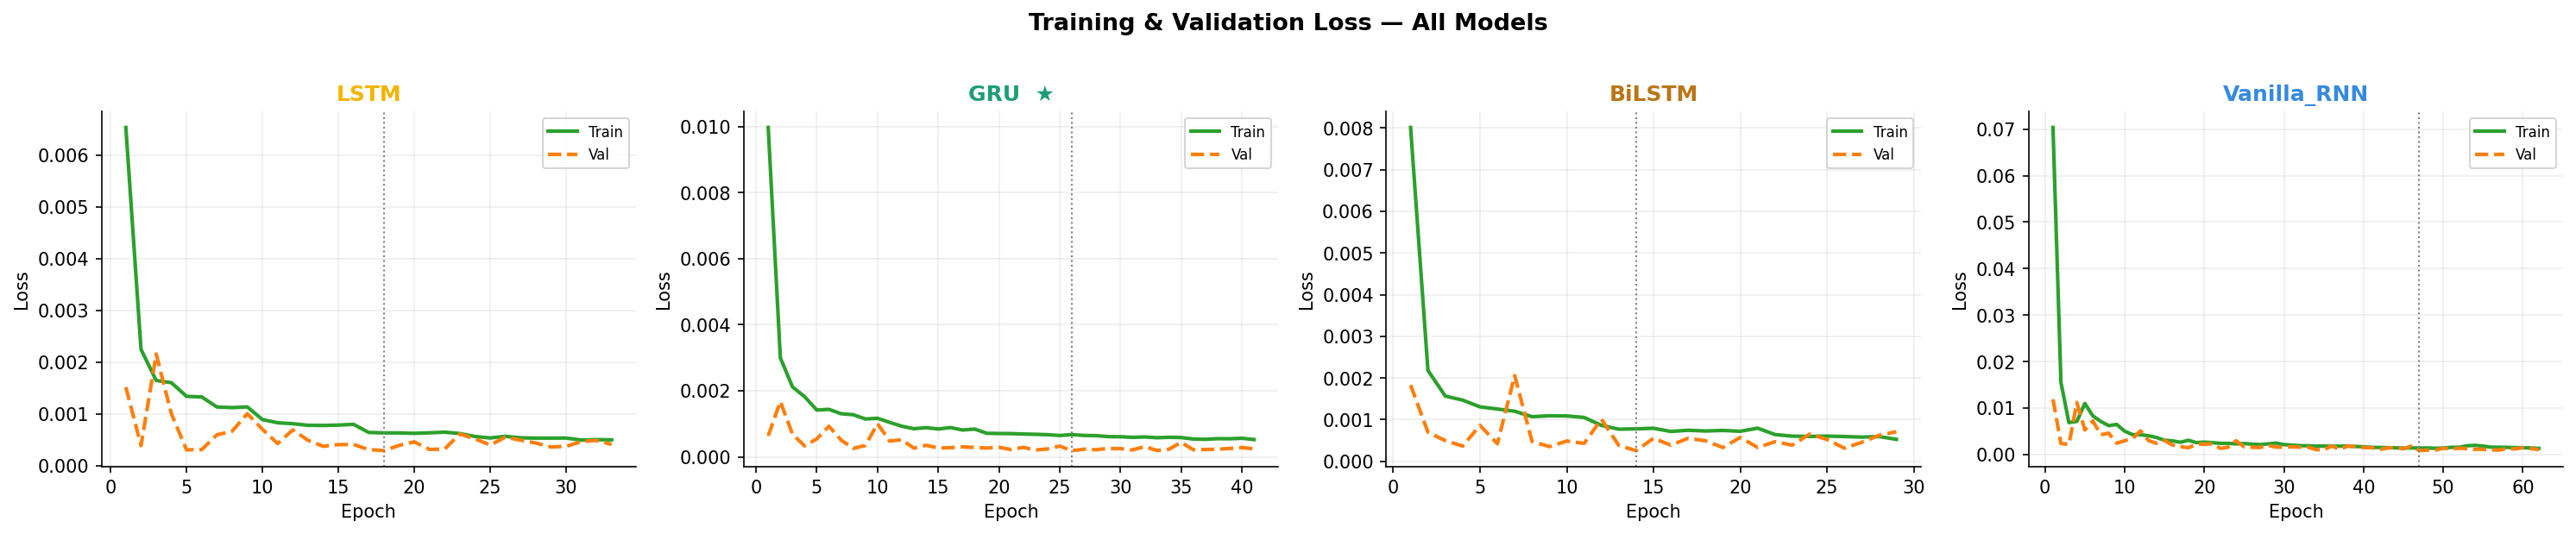

  Saved → plots/comparison_01_loss.png


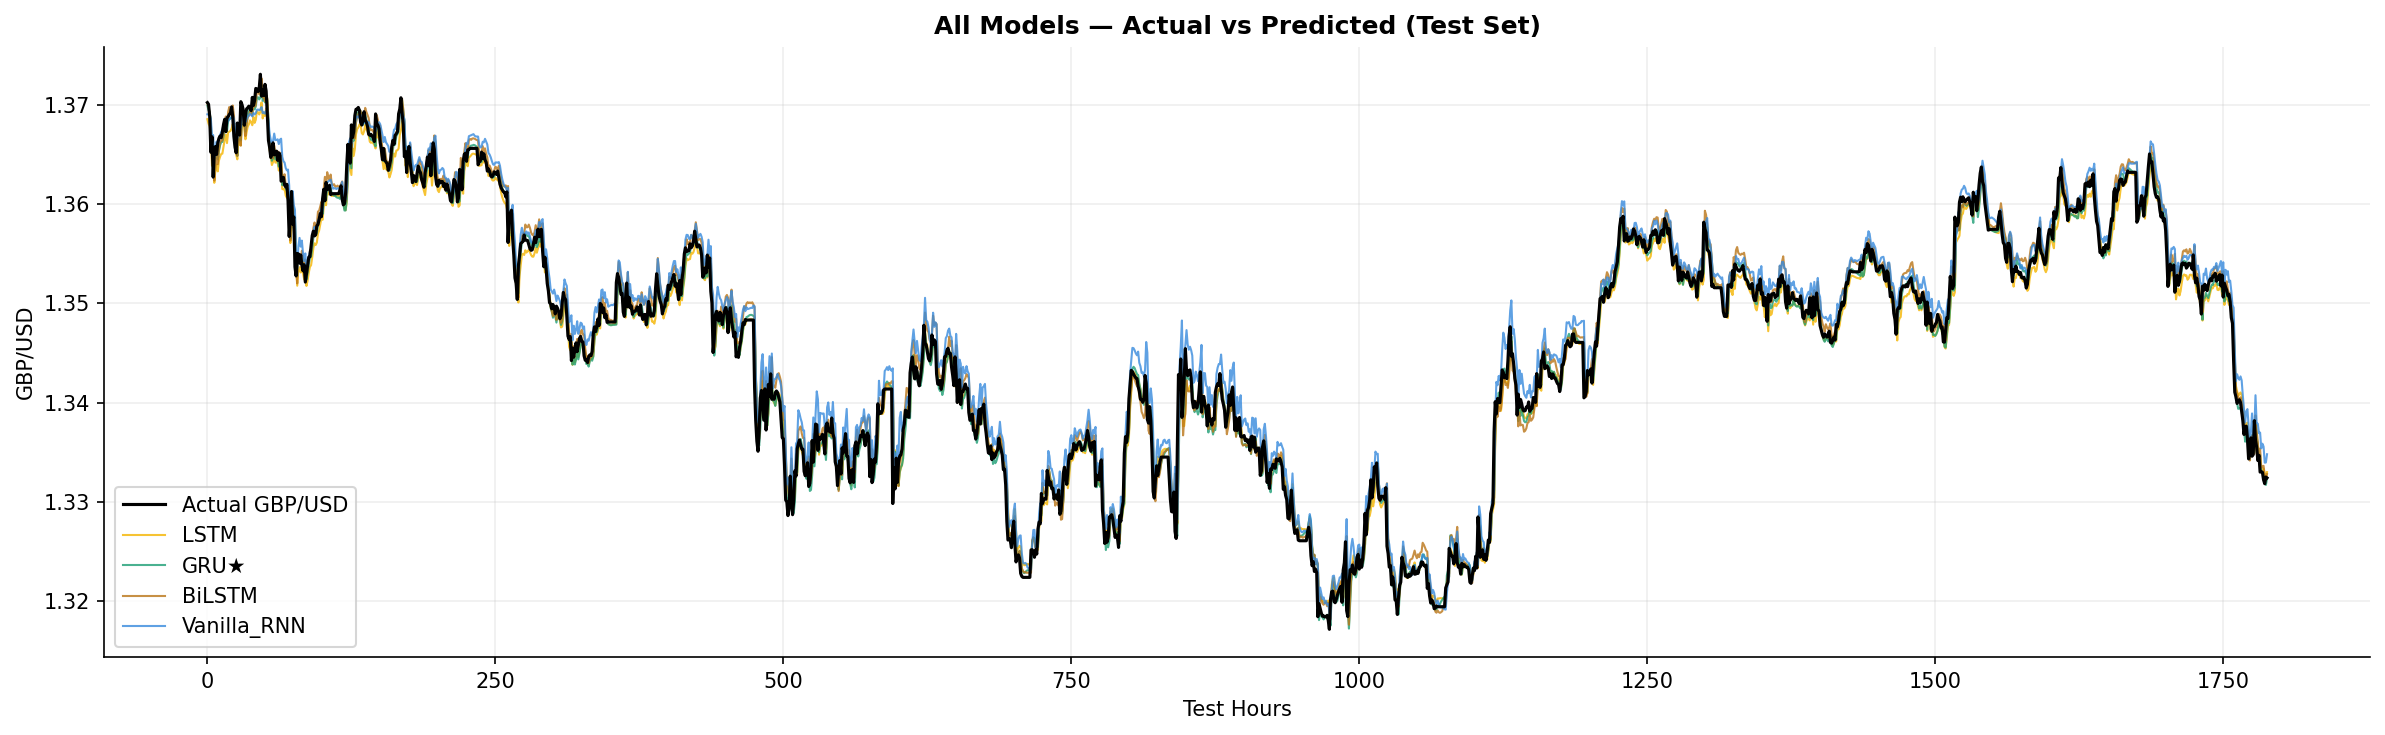

  Saved → plots/comparison_02_overlay.png


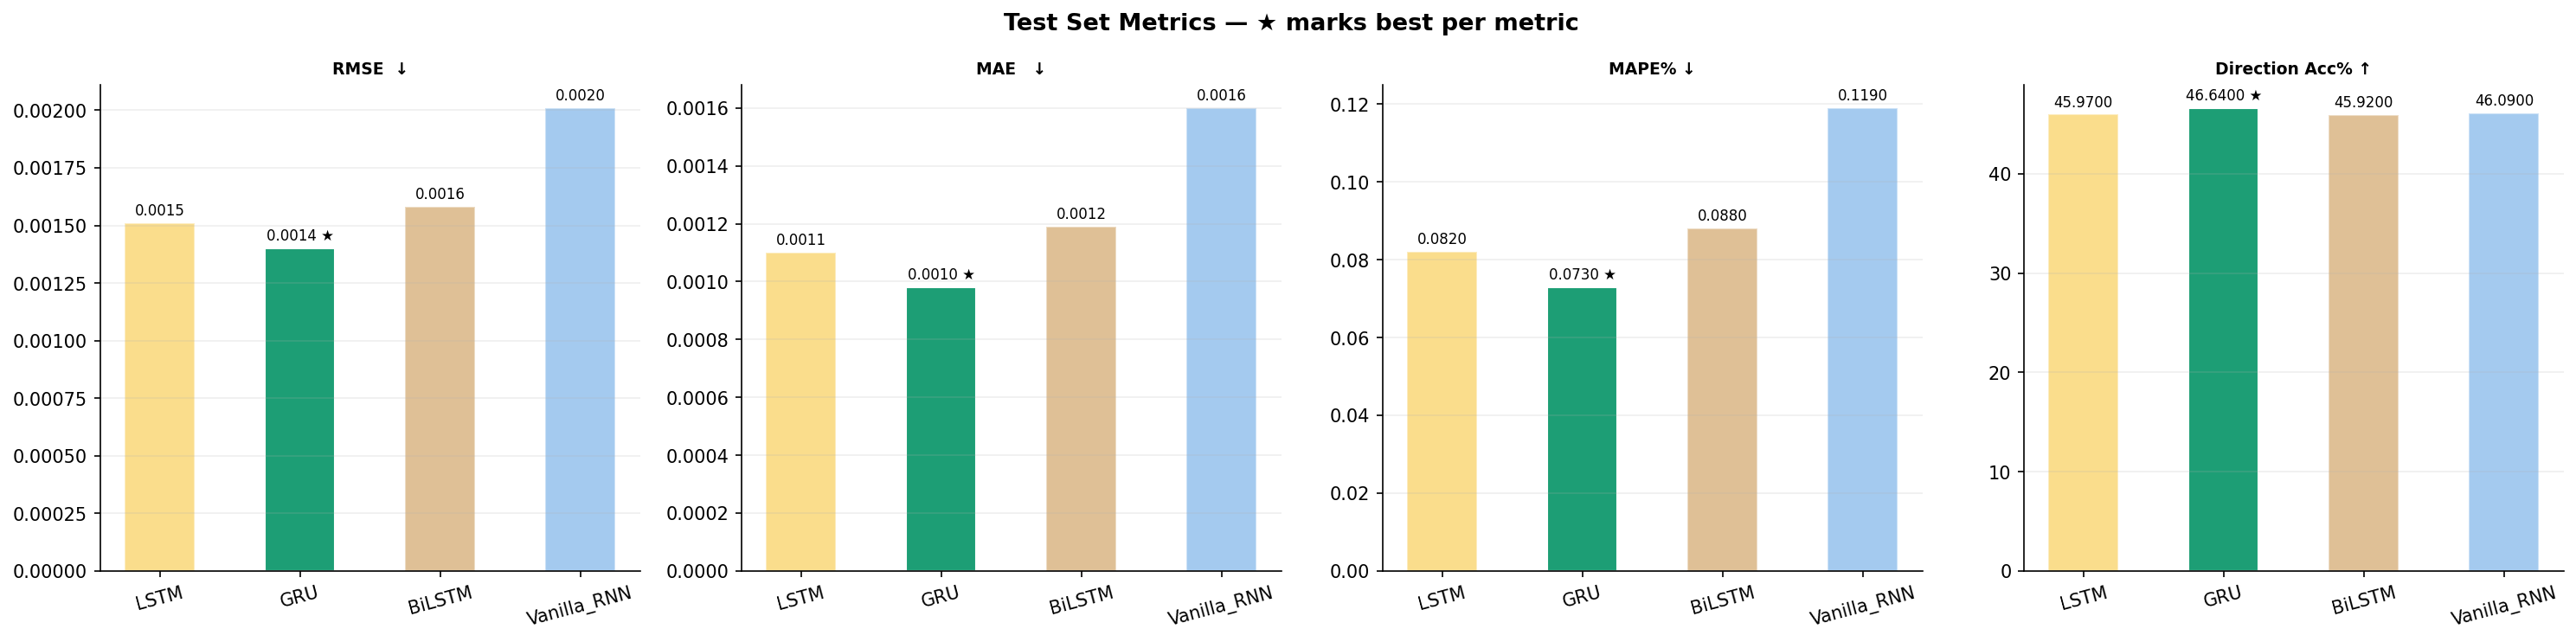

  Saved → plots/comparison_03_metrics.png


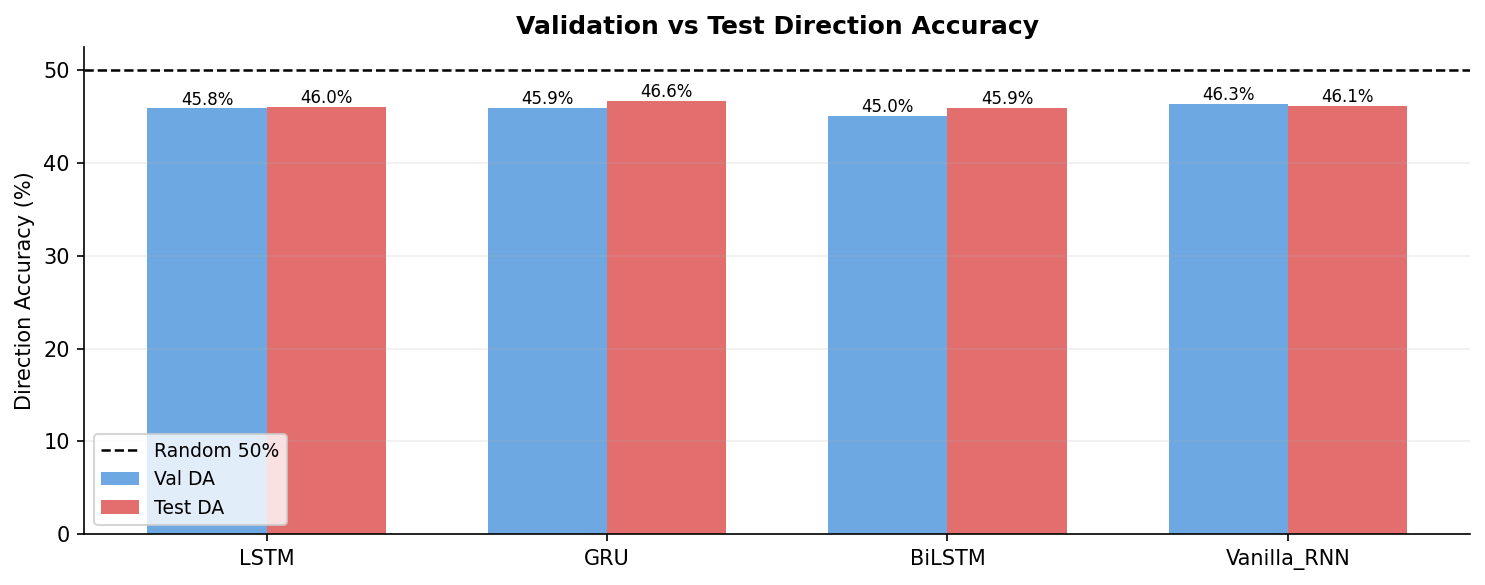

  Saved → plots/comparison_04_da.png


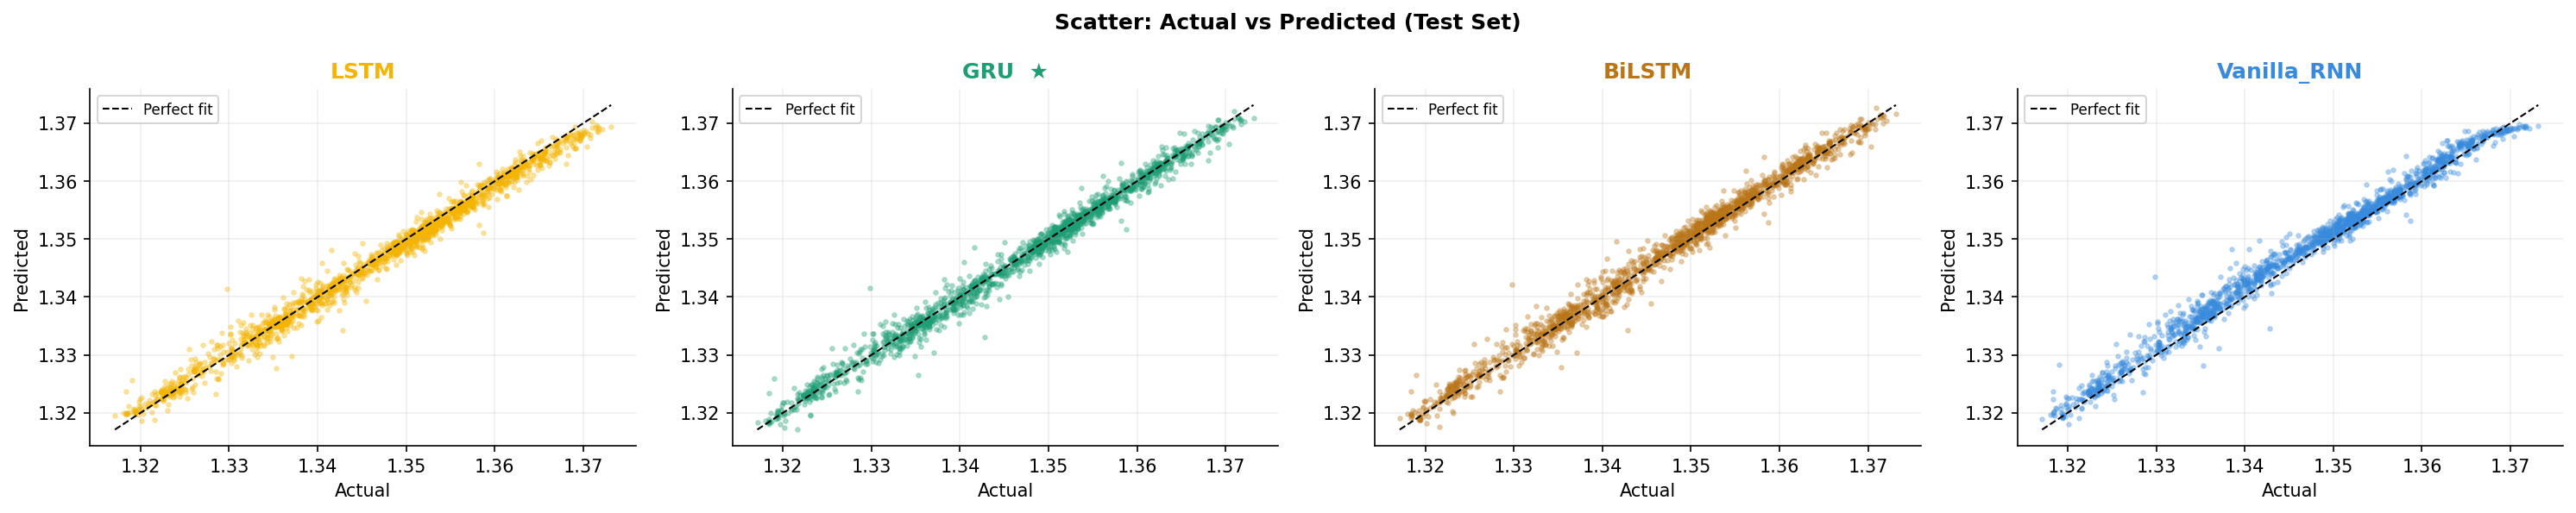

  Saved → plots/comparison_05_scatter.png


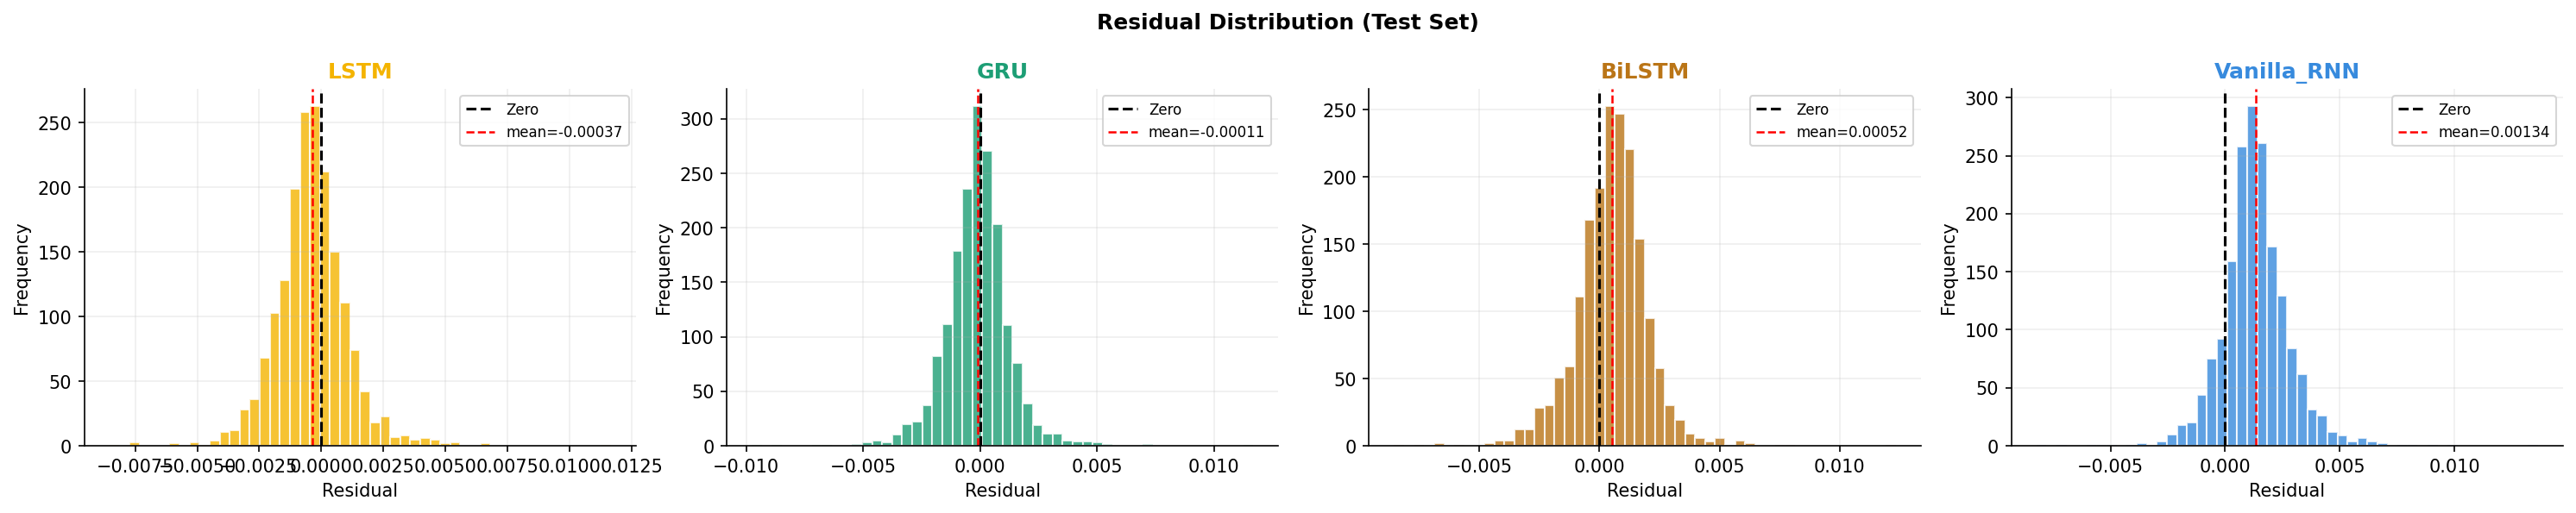

  Saved → plots/comparison_06_residuals.png


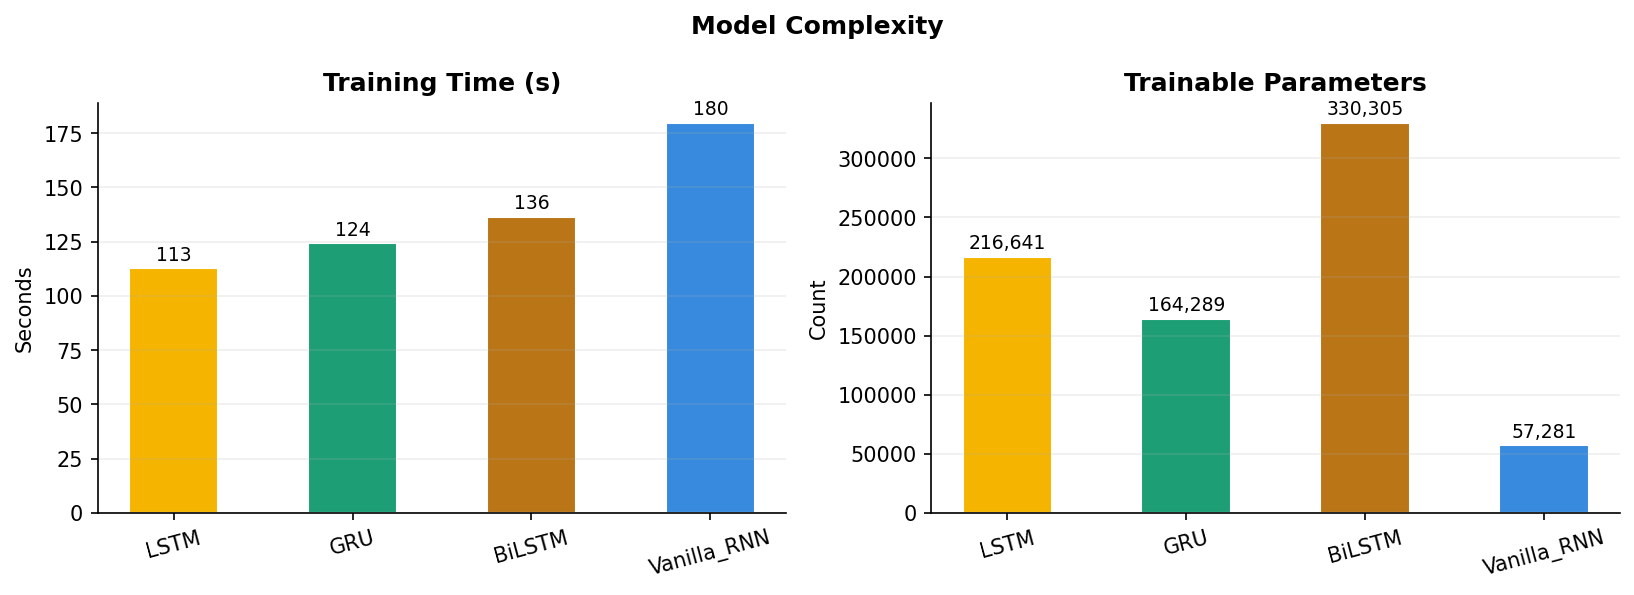

  Saved → plots/comparison_07_complexity.png

  FINAL VERDICT
                RMSE      MAE  MAPE (%)  NRMSE (%)  DA (%)  Params  Time (s)
Model                                                                       
LSTM         0.00151  0.00110     0.082      2.699   45.97  216641     112.7
GRU          0.00140  0.00098     0.073      2.493   46.64  164289     124.4
BiLSTM       0.00158  0.00119     0.088      2.828   45.92  330305     136.5
Vanilla_RNN  0.00201  0.00160     0.119      3.594   46.09   57281     179.9

  ★ BEST OVERALL → GRU  (4/5 metrics)
    RMSE         → GRU
    MAE          → GRU
    MAPE (%)     → GRU
    DA (%)       → GRU
    Speed        → LSTM


In [47]:
MODEL_NAMES = ["LSTM", "GRU", "BiLSTM", "Vanilla_RNN"]

print("\n" + "=" * 70)
print("  CROSS-MODEL COMPARISON")
print("=" * 70)

# ── Tables ────────────────────────────────────────────────────────────────────
val_df = pd.DataFrame([
    {"Model": n,
     "Val RMSE": round(results[n]["val_metrics"]["RMSE"],   5),
     "Val MAE":  round(results[n]["val_metrics"]["MAE"],    5),
     "Val MAPE": round(results[n]["val_metrics"]["MAPE"],   3),
     "Val DA %": round(results[n]["val_metrics"]["DA (%)"], 2)}
    for n in MODEL_NAMES
]).set_index("Model")

results_df = pd.DataFrame([
    {"Model":    n,
     "RMSE":     round(results[n]["metrics"]["RMSE"],   5),
     "MAE":      round(results[n]["metrics"]["MAE"],    5),
     "MAPE (%)": round(results[n]["metrics"]["MAPE"],   3),
     "NRMSE (%)":round(results[n]["metrics"]["NRMSE (%)"], 3),
     "DA (%)":   round(results[n]["metrics"]["DA (%)"], 2),
     "Params":   results[n]["params"],
     "Time (s)": round(results[n]["time"], 1)}
    for n in MODEL_NAMES
]).set_index("Model")

print("\n  Validation:"); print(val_df.to_string())
print("\n  Test:");       print(results_df.to_string())
results_df.to_csv(os.path.join(PLOTS_DIR, "comparison_table.csv"))

# ── Winner summary ────────────────────────────────────────────────────────────
best = {
    "RMSE":     results_df["RMSE"].idxmin(),
    "MAE":      results_df["MAE"].idxmin(),
    "MAPE (%)": results_df["MAPE (%)"].idxmin(),
    "DA (%)":   results_df["DA (%)"].idxmax(),
    "Speed":    results_df["Time (s)"].idxmin(),
}
print("\n  WINNER PER METRIC:")
print(f"  {'Metric':<12} {'Winner':<14} {'Value'}")
print("  " + "-" * 40)
for metric, winner in best.items():
    val = results_df.loc[winner, metric] if metric != "Speed" \
          else results_df.loc[winner, "Time (s)"]
    print(f"  {metric:<12} {winner:<14} {val}")

# Overall winner = most metric wins
from collections import Counter
wins = Counter(best.values())
overall = wins.most_common(1)[0][0]
print(f"\n  OVERALL BEST → {overall}  ({wins[overall]}/{len(best)} metrics won)")

# ── Shared plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 150, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

def _save(fname):
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, fname)
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {p}")

# ── Plot 1 : Loss curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Training & Validation Loss — All Models",
             fontsize=13, fontweight="bold", y=1.02)
for ax, name in zip(axes, MODEL_NAMES):
    h   = results[name]["history"].history
    eps = range(1, len(h["loss"]) + 1)
    c   = COLORS[name]
    ax.plot(eps, h["loss"],     color=_C_TRAIN, lw=2,   label="Train")
    ax.plot(eps, h["val_loss"], color=_C_VAL,   lw=2,
            linestyle="--", label="Val")
    ax.axvline(int(np.argmin(h["val_loss"])) + 1,
               color="grey", lw=1, linestyle=":")
    title = f"{name}{'  ★' if name == overall else ''}"
    ax.set_title(title, color=c, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
_save("comparison_01_loss.png")

# ── Plot 2 : Prediction overlay ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(results["LSTM"]["actual"], color="black", lw=1.5,
        label="Actual GBP/USD", zorder=5)
for name in MODEL_NAMES:
    ax.plot(results[name]["preds"], color=COLORS[name], lw=1.0,
            alpha=0.8, label=f"{name}{'★' if name==overall else ''}")
ax.set_title("All Models — Actual vs Predicted (Test Set)", fontweight="bold")
ax.set_xlabel("Test Hours"); ax.set_ylabel("GBP/USD")
ax.legend(fontsize=10); ax.grid(True, alpha=0.2)
_save("comparison_02_overlay.png")

# ── Plot 3 : Metrics bar charts with winner highlighted ───────────────────────
metric_defs = [
    ("RMSE",     "RMSE  ↓"),
    ("MAE",      "MAE   ↓"),
    ("MAPE (%)", "MAPE% ↓"),
    ("DA (%)",   "Direction Acc% ↑"),
]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Test Set Metrics — ★ marks best per metric",
             fontsize=13, fontweight="bold")
for ax, (key, label) in zip(axes, metric_defs):
    winner_key = {"MAPE (%)": "MAPE (%)"}.get(key, key)
    values = results_df[key].tolist()
    colors = [COLORS[n] for n in MODEL_NAMES]
    # highlight winner bar with full opacity, others dimmed
    best_n = results_df[key].idxmin() if "↓" in label else results_df[key].idxmax()
    alphas = [1.0 if n == best_n else 0.45 for n in MODEL_NAMES]
    for i, (val, c, a) in enumerate(zip(values, colors, alphas)):
        bar = ax.bar(MODEL_NAMES[i], val, color=c, alpha=a,
                     width=0.5, edgecolor="white")
        star = " ★" if MODEL_NAMES[i] == best_n else ""
        ax.text(i, val + max(values) * 0.01,
                f"{val:.4f}{star}", ha="center", va="bottom", fontsize=8)
    if "DA" in label:
        ax.axhline(50, color="black", lw=1.2, linestyle="--",
                   label="Random (50%)")
        ax.legend(fontsize=8)
    ax.set_title(label, fontweight="bold", fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.2)
_save("comparison_03_metrics.png")

# ── Plot 4 : Val vs Test DA ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(MODEL_NAMES)); w = 0.35
val_da  = [results[n]["val_metrics"]["DA (%)"] for n in MODEL_NAMES]
test_da = [results[n]["metrics"]["DA (%)"]      for n in MODEL_NAMES]
ax.bar(x-w/2, val_da,  w, label="Val DA",  color="#5599DD", alpha=0.85)
ax.bar(x+w/2, test_da, w, label="Test DA", color="#DD5555", alpha=0.85)
ax.axhline(50, color="black", lw=1.2, linestyle="--", label="Random 50%")
ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES)
ax.set_ylabel("Direction Accuracy (%)")
ax.set_title("Validation vs Test Direction Accuracy", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.2)
for i, (v, t) in enumerate(zip(val_da, test_da)):
    ax.text(i-w/2, v+0.4, f"{v:.1f}%", ha="center", fontsize=8)
    ax.text(i+w/2, t+0.4, f"{t:.1f}%", ha="center", fontsize=8)
_save("comparison_04_da.png")

# ── Plot 5 : Scatter ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Scatter: Actual vs Predicted (Test Set)", fontweight="bold")
for ax, name in zip(axes, MODEL_NAMES):
    a_, p_ = results[name]["actual"], results[name]["preds"]
    ax.scatter(a_, p_, s=5, alpha=0.3, color=COLORS[name])
    lo, hi = min(a_.min(),p_.min()), max(a_.max(),p_.max())
    ax.plot([lo,hi],[lo,hi],"k--",lw=1,label="Perfect fit")
    ax.set_title(f"{name}{'  ★' if name==overall else ''}",
                 color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
_save("comparison_05_scatter.png")

# ── Plot 6 : Residuals ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Residual Distribution (Test Set)", fontweight="bold")
for ax, name in zip(axes, MODEL_NAMES):
    res = results[name]["preds"] - results[name]["actual"]
    ax.hist(res, bins=50, color=COLORS[name], alpha=0.8, edgecolor="white")
    ax.axvline(0,          color="black", lw=1.5, linestyle="--", label="Zero")
    ax.axvline(res.mean(), color="red",   lw=1.2, linestyle="--",
               label=f"mean={res.mean():.5f}")
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Residual"); ax.set_ylabel("Frequency")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
_save("comparison_06_residuals.png")

# ── Plot 7 : Complexity ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Model Complexity", fontweight="bold")
for ax, vals, title, ylabel in [
    (ax1, [results[n]["time"]   for n in MODEL_NAMES], "Training Time (s)",    "Seconds"),
    (ax2, [results[n]["params"] for n in MODEL_NAMES], "Trainable Parameters", "Count"),
]:
    bars = ax.bar(MODEL_NAMES, vals,
                  color=[COLORS[n] for n in MODEL_NAMES],
                  width=0.5, edgecolor="white")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15); ax.grid(True, axis="y", alpha=0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.01,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
_save("comparison_07_complexity.png")

# ── Final verdict ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  FINAL VERDICT")
print("=" * 70)
print(results_df.to_string())
print(f"\n  ★ BEST OVERALL → {overall}  ({wins[overall]}/{len(best)} metrics)")
for metric, winner in best.items():
    print(f"    {metric:<12} → {winner}")
print("=" * 70)